# Modelos


## Estructura Notebook

0. Importaciones, configuraciones
1. Contexto del notebook
2. Rutas de entrada y salida
3. Carga de datasets de modelado
4. Validación inicial de datasets
5. Preparación de label y features
6. Funciones auxiliares de evaluación
7. Definición del catálogo de modelos
8. Entrenamiento de modelos Spark
9. Entrenamiento de modelos locales M04 y M05
10. Consolidación de resultados en validation
11. Entrenamiento con Hiperparámetros
12. Optimización de hiperparámetros con Optuna
13. Validación cruzada interna
14. Selección final del mejor modelo por validación
15. Evaluación final en test
16. Interpretabilidad y análisis de errores
17. Guardado de resultados y artefactos
18. Conclusiones del notebook

In [0]:
%pip install xgboost>=1.7
%pip install synapseml==1.1.3
%pip install lightgbm
%pip install optuna

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
 %restart_python

## 0. Importaciones, configuraciones

### 0.1. Importaciones, configuraciones

In [0]:
import os
import json
import time
import math
import warnings
import joblib

from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# PYSPARK SQL

from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as F
from pyspark.sql import types as T


# SPARK ML / SPARK CONNECT

# OJO:
# En este entorno, pyspark.ml.connect NO tiene VectorAssembler.
# Por eso VectorAssembler se toma desde pyspark.ml.feature.
try:
    from pyspark.ml.feature import VectorAssembler, StringIndexer
    VECTOR_ASSEMBLER_AVAILABLE = True
except Exception as exc:
    VectorAssembler = None
    StringIndexer = None
    VECTOR_ASSEMBLER_AVAILABLE = False
    print(f"[WARN] VectorAssembler no disponible: {exc}")


# LogisticRegression sí está disponible en pyspark.ml.connect.
try:
    from pyspark.ml.connect.classification import LogisticRegression as ConnectLogisticRegression
    LOGISTIC_REGRESSION_CONNECT_AVAILABLE = True
except Exception as exc:
    ConnectLogisticRegression = None
    LOGISTIC_REGRESSION_CONNECT_AVAILABLE = False
    print(f"[WARN] LogisticRegression Spark Connect no disponible: {exc}")


# RandomForestClassifier NO está disponible en pyspark.ml.connect en este entorno.
RANDOM_FOREST_CONNECT_AVAILABLE = False
RandomForestClassifier = None


# Evaluador Spark clásico. Si ya usas evaluar_predicciones_spark(),
# este evaluador casi no se necesita.
try:
    from pyspark.ml.evaluation import MulticlassClassificationEvaluator
    MULTICLASS_EVALUATOR_AVAILABLE = True
except Exception as exc:
    MulticlassClassificationEvaluator = None
    MULTICLASS_EVALUATOR_AVAILABLE = False
    print(f"[WARN] MulticlassClassificationEvaluator no disponible: {exc}")


# MODELOS LOCALES SKLEARN

from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier as SklearnRandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)


try:
    from xgboost import XGBClassifier
    XGBOOST_LOCAL_AVAILABLE = True
except Exception as exc:
    XGBClassifier = None
    XGBOOST_LOCAL_AVAILABLE = False
    print(f"[WARN] XGBoost local no disponible: {exc}")


try:
    from xgboost.spark import SparkXGBClassifier
    XGBOOST_SPARK_AVAILABLE = True
except Exception as exc:
    SparkXGBClassifier = None
    XGBOOST_SPARK_AVAILABLE = False
    print(f"[WARN] XGBoost Spark no disponible: {exc}")


try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_LOCAL_AVAILABLE = True
    print("[OK] LightGBM local disponible")
except Exception as exc:
    LGBMClassifier = None
    LIGHTGBM_LOCAL_AVAILABLE = False
    print("[WARN] LightGBM local no disponible:", exc)



No such comm: LSP_COMM_ID


[OK] LightGBM local disponible


### 0.2. CONFIGURACIÓN GENERAL

In [0]:
warnings.filterwarnings("ignore")

TARGET_COL = "target_nivel_operacion_mes_siguiente"
TARGET_CAT_COL = TARGET_COL
TARGET_NUM_COL = "target_operaciones_total_mes_siguiente"

LABEL_COL = "label"
FEATURES_COL = "features"
PREDICTION_COL = "prediction"

TARGET_ORDER = ["bajo", "medio", "alto"]

LABEL_TO_ID = {
    "bajo": 0,
    "medio": 1,
    "alto": 2,
}

ID_TO_LABEL = {
    0: "bajo",
    1: "medio",
    2: "alto",
}

RANDOM_STATE = 42


### 0.3. RESUMEN DE DISPONIBILIDAD

In [0]:
print("Imports cargados.")
print("VectorAssembler disponible              :", VECTOR_ASSEMBLER_AVAILABLE)
print("LogisticRegression Connect disponible   :", LOGISTIC_REGRESSION_CONNECT_AVAILABLE)
print("RandomForest Connect disponible         :", RANDOM_FOREST_CONNECT_AVAILABLE)
print("Evaluator disponible                    :", MULTICLASS_EVALUATOR_AVAILABLE)
print("XGBoost local disponible                :", XGBOOST_LOCAL_AVAILABLE)
print("XGBoost Spark disponible                :", XGBOOST_SPARK_AVAILABLE)
print("LightGBM Spark disponible               :", LIGHTGBM_LOCAL_AVAILABLE)

Imports cargados.
VectorAssembler disponible              : True
LogisticRegression Connect disponible   : True
RandomForest Connect disponible         : False
Evaluator disponible                    : True
XGBoost local disponible                : True
XGBoost Spark disponible                : True
LightGBM Spark disponible               : True


### 0.4. Verificar disponibilidad de Optuna

In [0]:

try:
    import optuna
    OPTUNA_AVAILABLE = True
    print("[OK] Optuna disponible")
    print("Versión:", optuna.__version__)
except Exception as exc:
    OPTUNA_AVAILABLE = False
    print("[WARN] Optuna no disponible:", exc)

[OK] Optuna disponible
Versión: 4.8.0


### 0.5. Imports para validación cruzada interna

In [0]:

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

print("[OK] Imports de validación cruzada cargados.")

[OK] Imports de validación cruzada cargados.


In [0]:
if "BASE_DIR" not in globals():
    BASE_DIR = Path("/Volumes/workspace/default/proyecto_aeropuertos")

SPARKML_TEMP_DFS_PATH = str(BASE_DIR / "_tmp" / "sparkml_temp_dfs")

dbutils.fs.mkdirs(SPARKML_TEMP_DFS_PATH)

os.environ["SPARKML_TEMP_DFS_PATH"] = SPARKML_TEMP_DFS_PATH

print("SPARKML_TEMP_DFS_PATH configurado en:")
print(os.environ["SPARKML_TEMP_DFS_PATH"])


SPARKML_TEMP_DFS_PATH configurado en:
/Volumes/workspace/default/proyecto_aeropuertos/_tmp/sparkml_temp_dfs


## 1. Contexto del notebook


Este notebook entrena y evalúa los modelos supervisados clásicos definidos para el proyecto de predicción del nivel mensual de operación aeroportuaria.

La entrada corresponde a los datasets preprocesados y seleccionados por correlación generados en el notebook anterior:

- `corr_060_070`
- `corr_060_080`
- `corr_060_090`

En este notebook se evaluarán seis modelos:

| ID | Modelo esperado | Implementación |
|---|---|---|
| `B01` | Logistic Regression | `pyspark.ml.classification.LogisticRegression` |
| `M01` | Random Forest | `pyspark.ml.classification.RandomForestClassifier` |
| `M02` | XGBoost | `xgboost.spark.SparkXGBClassifier`, si está disponible |
| `M03` | LightGBM | `synapse.ml.lightgbm.LightGBMClassifier`, si está disponible |
| `M04` | Extra Trees | `sklearn.ensemble.ExtraTreesClassifier`, usando conversión local a pandas |
| `M05` | KNN | `sklearn.neighbors.KNeighborsClassifier`, usando conversión local a pandas |

## 2. Rutas de entrada y salida


In [0]:
BASE_DIR = Path("/Volumes/workspace/default/proyecto_aeropuertos")
GOLD_MONTHLY_DIR = BASE_DIR / "gold" / "monthly_airport_dataset"
MODELING_DIR = GOLD_MONTHLY_DIR / "modeling"
RESULTS_DIR = GOLD_MONTHLY_DIR / "results" / "classical_models"

CORR_60_70_train = MODELING_DIR / "corr_060_070" / "dataset_train.parquet"
CORR_60_70_valid = MODELING_DIR / "corr_060_070" / "dataset_valid.parquet"
CORR_60_70_test = MODELING_DIR / "corr_060_070" / "dataset_test.parquet"

CORR_60_80_train = MODELING_DIR / "corr_060_080" / "dataset_train.parquet"
CORR_60_80_valid = MODELING_DIR / "corr_060_080" / "dataset_valid.parquet"
CORR_60_80_test = MODELING_DIR / "corr_060_080" / "dataset_test.parquet"

CORR_60_90_train = MODELING_DIR / "corr_060_090" / "dataset_train.parquet"
CORR_60_90_valid = MODELING_DIR / "corr_060_090" / "dataset_valid.parquet"
CORR_60_90_test = MODELING_DIR / "corr_060_090" / "dataset_test.parquet"

## 3. Carga de datasets de modelado

In [0]:
def read_spark_parquet(path_or_paths) -> DataFrame:
    """
    Lee Parquet usando Spark.

    Soporta:
    - Un solo path: Path o string.
    - Varios paths: list, tuple o set de Path/string.
    - Parquet tipo carpeta Spark con part-files.
    """

    if isinstance(path_or_paths, (list, tuple, set)):
        paths = [str(path) for path in path_or_paths]

        if not paths:
            raise ValueError("La lista de paths Parquet está vacía.")

        return spark.read.parquet(*paths)

    return spark.read.parquet(str(path_or_paths))

In [0]:
df_corr_060_070_train = read_spark_parquet(CORR_60_70_train)
df_corr_060_070_valid = read_spark_parquet(CORR_60_70_valid)
df_corr_060_070_test = read_spark_parquet(CORR_60_70_test)

df_corr_060_080_train = read_spark_parquet(CORR_60_80_train)
df_corr_060_080_valid = read_spark_parquet(CORR_60_80_valid)
df_corr_060_080_test = read_spark_parquet(CORR_60_80_test)

df_corr_060_090_train = read_spark_parquet(CORR_60_90_train)
df_corr_060_090_valid = read_spark_parquet(CORR_60_90_valid)
df_corr_060_090_test = read_spark_parquet(CORR_60_90_test)

print("[OK] Datasets cargados correctamente.")

[OK] Datasets cargados correctamente.


In [0]:

DATASETS_MODELADO = {
    "corr_060_070": {
        "train": df_corr_060_070_train,
        "valid": df_corr_060_070_valid,
        "test": df_corr_060_070_test,
    },
    "corr_060_080": {
        "train": df_corr_060_080_train,
        "valid": df_corr_060_080_valid,
        "test": df_corr_060_080_test,
    },
    "corr_060_090": {
        "train": df_corr_060_090_train,
        "valid": df_corr_060_090_valid,
        "test": df_corr_060_090_test,
    },
}

print("Configuraciones disponibles:")
for config_id in DATASETS_MODELADO:
    print(" -", config_id)

Configuraciones disponibles:
 - corr_060_070
 - corr_060_080
 - corr_060_090


## 4. Validación inicial de datasets

In [0]:
for config_id, splits in DATASETS_MODELADO.items():
    print("\n============================================================")
    print(config_id)
    print("============================================================")

    for split_name, df_split in splits.items():
        print(
            f"{split_name:>5}: "
            f"{df_split.count():,} filas x {len(df_split.columns):,} columnas"
        )

    cols_train = splits["train"].columns
    cols_valid = splits["valid"].columns
    cols_test = splits["test"].columns

    if cols_train != cols_valid:
        raise ValueError(f"{config_id}: train y valid no tienen las mismas columnas.")

    if cols_train != cols_test:
        raise ValueError(f"{config_id}: train y test no tienen las mismas columnas.")

    print("[OK] Columnas consistentes entre train, valid y test.")


corr_060_070
train: 2,572 filas x 41 columnas
valid: 319 filas x 41 columnas
 test: 363 filas x 41 columnas
[OK] Columnas consistentes entre train, valid y test.

corr_060_080
train: 2,572 filas x 57 columnas
valid: 319 filas x 57 columnas
 test: 363 filas x 57 columnas
[OK] Columnas consistentes entre train, valid y test.

corr_060_090
train: 2,572 filas x 74 columnas
valid: 319 filas x 74 columnas
 test: 363 filas x 74 columnas
[OK] Columnas consistentes entre train, valid y test.


In [0]:
display(df_corr_060_080_train.limit(10))

fecha_mes,operaciones_total,pasajeros_salida,operaciones_total_lag_12,n_origenes_total,pasajeros_internacional_total,n_empresas_salida_lag_3,cobertura_metar_ratio,carga_salida_kg,n_destinos_total_lag_12,pasajeros_total_lag_12,cobertura_metar_ratio_lag_12,carga_total_kg_lag_12,viento_max_kt,pasajeros_por_operacion_lag_3,prop_tormenta,prop_niebla,visibilidad_rango_sm,meteo_adverso_score_lag_12,prop_baja_visibilidad,cloud_base_min_ft,operaciones_por_destino,meteo_adverso_score_lag_3,temp_rango_c,prop_lluvia,meteo_adverso_score_lag_2,temp_min_c,meteo_adverso_score_lag_1,meteo_adverso_score_roll_mean_12,prop_rafaga,tiene_od_mes,viento_medio_kt,meteo_adverso_score_roll_mean_3,latitude_deg,operaciones_otras,operaciones_vs_roll_mean_12,viento_std_kt,historial_lag_12_disponible,prop_viento_fuerte,sin_od_sin_metar_mes,dewpoint_media_c,temp_std_c,operaciones_vs_roll_mean_3,visibilidad_std_sm,altimeter_media_inhg,operaciones_delta_1,visibilidad_media_sm,temp_max_c,temp_media_c,dewpoint_depression_c,historial_lag_3_disponible,longitude_deg,historial_lag_1_disponible,n_metar_esperados_mes,rafaga_max_kt,target_nivel_operacion_mes_siguiente,target_operaciones_total_mes_siguiente
2020-01-01,-0.1608628953981054,-0.18060266368754063,-0.23574757858050213,0.5431264096612672,-0.13347493799780155,-0.1878867899447113,0.9773631643478808,-0.19457616905495992,-0.3294781575486956,-0.2940343339294632,-0.5880051704225557,-0.17511981640987975,-0.21924542307512562,-0.29958641013022186,0.028741388213464197,0.02424287924422679,0.9875949137489004,-0.4005779864587895,0.5379454616099987,-0.4245003386135348,-0.2814277673139584,-0.36663992598035616,1.4107197405837266,0.12051929892623323,-0.3514486049249187,-0.9598634138284031,-0.3456224968875501,-0.2975918377500375,-0.289574846507302,1.0,-1.469425618670228,-0.22783844070453627,-0.3204315771290524,-0.22809242785666667,-2.0698569750884244,-0.7011025570557033,0.0,-0.25035135171536704,0.0,-0.5078961754046379,2.1718290353799596,-1.0911122867596759,0.8493950473843358,0.6055328022117612,0.00923829553965491,-0.01867484003571266,0.5243111589037642,-0.42133481309959164,0.13239810911573985,0.0,-0.34888240575714174,0.0,0.6916155443241176,-0.5703532755506386,alto,744.0
2020-02-01,-0.18077607312178298,-0.19979386143032604,-0.23574757858050213,0.5431264096612672,-0.1570443035704132,-0.1878867899447113,0.8758369926693689,-0.19456420939001498,-0.3294781575486956,-0.2940343339294632,-0.5880051704225557,-0.17511981640987975,-0.1707392560869574,-0.29958641013022186,0.6942663010344402,0.357492072960601,1.100111836473419,-0.4005779864587895,0.8694958484003091,-0.7617578152138266,-0.28103137864705835,-0.36663992598035616,1.4107197405837253,0.2854157831058434,-0.3514486049249187,-0.7791204091892162,0.09043629228329705,0.23999701330426584,-0.289574846507302,1.0,-1.4394321550430678,0.12406719753730829,-0.3204315771290524,-0.22809242785666667,-0.24513426026067658,-0.6417295084271614,0.0,-0.25035135171536704,0.0,-0.4866462429143816,2.1718290353799596,-0.15742834477815995,1.4039944765958998,0.5355206798857203,-0.13702997804915318,-0.36290185971686606,0.7317132352957156,-0.38269368181634655,0.1679069031328359,0.0,-0.34888240575714174,1.0,-1.8067484725321021,-0.5703532755506386,medio,531.0
2020-03-01,-0.23887890675388335,-0.2559554142753837,-0.23574757858050213,0.48279662308837057,-0.1847963713363396,-0.1878867899447113,0.814734360002094,-0.19380714361540624,-0.3294781575486956,-0.2940343339294632,-0.5880051704225557,-0.17511981640987975,-0.12223308909878915,-0.29958641013022186,0.2738917429487027,0.514780555330672,1.1501556059926565,-0.4005779864587895,0.7948966271177182,-0.19966202088000692,-0.29854804572314686,-0.36663992598035616,0.8749295496827594,0.18410279777965435,0.10301890642566953,-0.9598634138284031,0.44471744810760955,0.5634087266521172,-0.289574846507302,1.0,-1.3185178636175185,0.36351793744812105,-0.3204315771290524,-0.22809242785666667,-0.7066317520690314,-0.4118411743428614,0.0,-0.25035135171536704,0.0,-0.696913133951908,0.73113

## 5. Preparación de label y features

In [0]:
def agregar_label_manual(
    df: DataFrame,
    target_col: str = TARGET_COL,
    label_col: str = LABEL_COL,
) -> DataFrame:
    """
    Crea la columna label con un mapeo fijo:
    bajo  -> 0
    medio -> 1
    alto  -> 2
    """

    return (
        df
        .withColumn(
            label_col,
            F.when(F.col(target_col) == "bajo", F.lit(0.0))
            .when(F.col(target_col) == "medio", F.lit(1.0))
            .when(F.col(target_col) == "alto", F.lit(2.0))
            .otherwise(F.lit(None).cast("double"))
        )
    )

In [0]:
def agregar_label_manual(
    df: DataFrame,
    target_col: str = TARGET_COL,
    label_col: str = LABEL_COL,
) -> DataFrame:
    """
    Crea la columna label numérica a partir del target categórico.

    Mapeo usado:
    - bajo  -> 0.0
    - medio -> 1.0
    - alto  -> 2.0
    """

    return (
        df
        .withColumn(
            label_col,
            F.when(F.col(target_col) == "bajo", F.lit(0.0))
            .when(F.col(target_col) == "medio", F.lit(1.0))
            .when(F.col(target_col) == "alto", F.lit(2.0))
            .otherwise(F.lit(None).cast("double"))
        )
    )


def obtener_feature_cols(
    df: DataFrame,
    target_cat_col: str = TARGET_COL,
    target_num_col: str = TARGET_NUM_COL,
) -> list[str]:
    """
    Define las columnas predictoras.

    Excluye targets, fecha y columnas auxiliares que no deben entrar al modelo.
    """

    columnas_no_feature = {
        target_cat_col,
        target_num_col,
        "fecha_mes",
        "target_q33_operaciones",
        "target_q66_operaciones",
        LABEL_COL,
        FEATURES_COL,
    }

    feature_cols = [
        c for c in df.columns
        if c not in columnas_no_feature
    ]

    return feature_cols


def preparar_split_ml(
    df: DataFrame,
    feature_cols: list[str],
    target_cat_col: str = TARGET_COL,
    label_col: str = LABEL_COL,
    features_col: str = FEATURES_COL,
) -> DataFrame:
    """
    Prepara un split para Spark MLlib.

    Pasos:
    1. Crea label manual desde el target categórico.
    2. Convierte features a double.
    3. Ensambla las features en una columna vectorial.
    4. Retorna columnas necesarias para entrenamiento/evaluación.
    """

    df_out = agregar_label_manual(
        df=df,
        target_col=target_cat_col,
        label_col=label_col,
    )

    for c in feature_cols:
        df_out = df_out.withColumn(
            c,
            F.col(c).cast("double")
        )

    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol=features_col,
        handleInvalid="keep",
    )

    df_out = assembler.transform(df_out)

    return df_out.select(
        features_col,
        label_col,
        target_cat_col,
        *feature_cols,
    )


def validar_labels(
    df: DataFrame,
    config_id: str,
    split_name: str,
    label_col: str = LABEL_COL,
) -> None:
    """
    Verifica que no existan labels nulos después del mapeo.
    """

    n_null_labels = (
        df
        .filter(F.col(label_col).isNull())
        .count()
    )

    if n_null_labels > 0:
        raise ValueError(
            f"{config_id} - {split_name}: hay {n_null_labels} labels nulos. "
            "Revisar valores del target categórico."
        )

In [0]:

DATASETS_PREPARADOS = {}

for config_id, datasets in DATASETS_MODELADO.items():

    print("\n============================================================")
    print(f"Procesando configuración: {config_id}")
    print("============================================================")

    train_df = datasets["train"]
    valid_df = datasets["valid"]
    test_df = datasets["test"]

    feature_cols = obtener_feature_cols(train_df)

    print(f"Features usadas: {len(feature_cols)}")

    train_ml = preparar_split_ml(
        df=train_df,
        feature_cols=feature_cols,
    )

    valid_ml = preparar_split_ml(
        df=valid_df,
        feature_cols=feature_cols,
    )

    test_ml = preparar_split_ml(
        df=test_df,
        feature_cols=feature_cols,
    )

    validar_labels(train_ml, config_id, "train")
    validar_labels(valid_ml, config_id, "valid")
    validar_labels(test_ml, config_id, "test")

    DATASETS_PREPARADOS[config_id] = {
        "train_ml": train_ml.select(FEATURES_COL, LABEL_COL),
        "valid_ml": valid_ml.select(FEATURES_COL, LABEL_COL),
        "test_ml": test_ml.select(FEATURES_COL, LABEL_COL),

        # Estos sirven para modelos locales tipo Extra Trees / KNN si luego se convierten a pandas.
        "train_raw": train_ml.select(LABEL_COL, *feature_cols),
        "valid_raw": valid_ml.select(LABEL_COL, *feature_cols),
        "test_raw": test_ml.select(LABEL_COL, *feature_cols),

        "feature_cols": feature_cols,
    }

    print("[OK] Dataset preparado")
    print("Train     :", train_ml.count(), "filas x", len(train_ml.columns), "columnas")
    print("Validation:", valid_ml.count(), "filas x", len(valid_ml.columns), "columnas")
    print("Test      :", test_ml.count(), "filas x", len(test_ml.columns), "columnas")

print("\n[OK] Todos los datasets quedaron preparados correctamente.")


Procesando configuración: corr_060_070
Features usadas: 38
[OK] Dataset preparado
Train     : 2572 filas x 41 columnas
Validation: 319 filas x 41 columnas
Test      : 363 filas x 41 columnas

Procesando configuración: corr_060_080
Features usadas: 54
[OK] Dataset preparado
Train     : 2572 filas x 57 columnas
Validation: 319 filas x 57 columnas
Test      : 363 filas x 57 columnas

Procesando configuración: corr_060_090
Features usadas: 71
[OK] Dataset preparado
Train     : 2572 filas x 74 columnas
Validation: 319 filas x 74 columnas
Test      : 363 filas x 74 columnas

[OK] Todos los datasets quedaron preparados correctamente.


### 5.1. Verificación del label por configuración

In [0]:
for config_id, datasets in DATASETS_PREPARADOS.items():
    print("\n============================================================")
    print(config_id)
    print("============================================================")

    display(
        datasets["train_ml"]
        .groupBy("label")
        .count()
        .orderBy("label")
    )


corr_060_070


label,count
0.0,888
1.0,832
2.0,852



corr_060_080


label,count
0.0,888
1.0,832
2.0,852



corr_060_090


label,count
0.0,888
1.0,832
2.0,852


In [0]:
display(DATASETS_PREPARADOS["corr_060_070"]["train_raw"].limit(5))

label,operaciones_total,pasajeros_total_roll_mean_12,n_empresas_llegada,n_destinos_total_lag_12,cobertura_metar_ratio_lag_12,viento_max_kt,prop_tormenta,prop_niebla,visibilidad_rango_sm,pasajeros_por_operacion_lag_12,operaciones_por_destino,meteo_adverso_score_lag_3,prop_lluvia,meteo_adverso_score_lag_2,temp_min_c,meteo_adverso_score_lag_1,meteo_adverso_score_roll_mean_12,prop_rafaga,tiene_od_mes,viento_medio_kt,latitude_deg,operaciones_otras,carga_kg_por_operacion_lag_3,operaciones_vs_roll_mean_12,historial_lag_12_disponible,prop_viento_fuerte,dewpoint_media_c,temp_std_c,operaciones_vs_roll_mean_3,visibilidad_std_sm,operaciones_delta_1,temp_max_c,dewpoint_depression_c,historial_lag_3_disponible,longitude_deg,historial_lag_1_disponible,n_metar_esperados_mes,rafaga_max_kt
2.0,-0.1608628953981054,-0.3099427930794679,-0.5043858325759875,-0.3294781575486956,-0.5880051704225557,-0.21924542307512562,0.028741388213464197,0.02424287924422679,0.9875949137489004,-0.2643542627123602,-0.2814277673139584,-0.36663992598035616,0.12051929892623323,-0.3514486049249187,-0.9598634138284031,-0.3456224968875501,-0.2975918377500375,-0.289574846507302,1.0,-1.469425618670228,-0.3204315771290524,-0.22809242785666667,-0.39832938879636764,-2.0698569750884244,0.0,-0.25035135171536704,-0.5078961754046379,2.1718290353799596,-1.0911122867596759,0.8493950473843358,0.00923829553965491,0.5243111589037642,0.13239810911573985,0.0,-0.34888240575714174,0.0,0.6916155443241176,-0.5703532755506386
1.0,-0.18077607312178298,-0.1749335852229056,-0.40307537873878013,-0.3294781575486956,-0.5880051704225557,-0.1707392560869574,0.6942663010344402,0.357492072960601,1.100111836473419,-0.2643542627123602,-0.28103137864705835,-0.36663992598035616,0.2854157831058434,-0.3514486049249187,-0.7791204091892162,0.09043629228329705,0.23999701330426584,-0.289574846507302,1.0,-1.4394321550430678,-0.3204315771290524,-0.22809242785666667,-0.39832938879636764,-0.24513426026067658,0.0,-0.25035135171536704,-0.4866462429143816,2.1718290353799596,-0.15742834477815995,1.4039944765958998,-0.13702997804915318,0.7317132352957156,0.1679069031328359,0.0,-0.34888240575714174,1.0,-1.8067484725321021,-0.5703532755506386
0.0,-0.23887890675388335,-0.18183538849993175,-0.3017649249015728,-0.3294781575486956,-0.5880051704225557,-0.12223308909878915,0.2738917429487027,0.514780555330672,1.1501556059926565,-0.2643542627123602,-0.29854804572314686,-0.36663992598035616,0.18410279777965435,0.10301890642566953,-0.9598634138284031,0.44471744810760955,0.5634087266521172,-0.289574846507302,1.0,-1.3185178636175185,-0.3204315771290524,-0.22809242785666667,-0.39832938879636764,-0.7066317520690314,0.0,-0.25035135171536704,-0.696913133951908,0.7311333309777142,-0.39356986582393866,1.1060470635879163,-0.40647153466011543,-0.09789507027209578,0.31604869040934275,0.0,-0.34888240575714174,1.0,0.6916155443241176,-0.5703532755506386
0.0,-0.3779983675631377,-0.20510753579650234,-0.9096276479248168,-0.3294781575486956,-0.5880051704225557,-0.3647639240396303,1.2172918938495123,0.07622216815514464,1.106527034260733,-0.2643542627123602,-0.30195460197219837,0.15491529035680038,0.5388226573905976,0.4597440808904832,-0.4176343999108419,0.4231570368943028,0.6580914335885463,-0.289574846507302,1.0,-1.237100308680001,-0.3204315771290524,-0.22809242785666667,-0.47596262926198557,-2.0095142570182425,0.0,-0.25035135171536704,-0.3359260137719345,0.6028376524500115,-1.0602357999270091,1.3805371981468457,-0.9780725511847995,0.10950700611985707,0.07695229523575704,1.0,-0.34888240575714174,1.0,-0.5575664641039922,-0.5703532755506386
0.0,-0.37527053499825036,-0.24050249059714165,-0.8083171940876094,-0.3294781575486956,-0.5880051704225557,-0.41327009102779855,-0.3399313243903072,0.11066417164991746,0.7527721768805148,-0.2643542627123602,-0.2603307428041007,0.5488783956690545,0.228481452032313,0.43803493456655623,-0.056148390632468785,0.4965206533883032,0.7389184135396516,-0.289574846507302,1.0,-1.4110236442095208,-0.3204315771290524,-0.228092427856

In [0]:
display(DATASETS_PREPARADOS["corr_060_070"]["train_ml"].limit(5))

features,label
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-0.1608628953981054"",""-0.3099427930794679"",""-0.5043858325759875"",""-0.3294781575486956"",""-0.5880051704225557"",""-0.21924542307512562"",""0.028741388213464197"",""0.02424287924422679"",""0.9875949137489004"",""-0.2643542627123602"",""-0.2814277673139584"",""-0.36663992598035616"",""0.12051929892623323"",""-0.3514486049249187"",""-0.9598634138284031"",""-0.3456224968875501"",""-0.2975918377500375"",""-0.289574846507302"",""1.0"",""-1.469425618670228"",""-0.3204315771290524"",""-0.22809242785666667"",""-0.39832938879636764"",""-2.0698569750884244"",""0.0"",""-0.25035135171536704"",""-0.5078961754046379"",""2.1718290353799596"",""-1.0911122867596759"",""0.8493950473843358"",""0.00923829553965491"",""0.5243111589037642"",""0.13239810911573985"",""0.0"",""-0.34888240575714174"",""0.0"",""0.6916155443241176"",""-0.5703532755506386""]}",2.0
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-0.18077607312178298"",""-0.1749335852229056"",""-0.40307537873878013"",""-0.3294781575486956"",""-0.5880051704225557"",""-0.1707392560869574"",""0.6942663010344402"",""0.357492072960601"",""1.100111836473419"",""-0.2643542627123602"",""-0.28103137864705835"",""-0.36663992598035616"",""0.2854157831058434"",""-0.3514486049249187"",""-0.7791204091892162"",""0.09043629228329705"",""0.23999701330426584"",""-0.289574846507302"",""1.0"",""-1.4394321550430678"",""-0.3204315771290524"",""-0.22809242785666667"",""-0.39832938879636764"",""-0.24513426026067658"",""0.0"",""-0.25035135171536704"",""-0.4866462429143816"",""2.1718290353799596"",""-0.15742834477815995"",""1.4039944765958998"",""-0.13702997804915318"",""0.7317132352957156"",""0.1679069031328359"",""0.0"",""-0.34888240575714174"",""1.0"",""-1.8067484725321021"",""-0.5703532755506386""]}",1.0
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-0.23887890675388335"",""-0.18183538849993175"",""-0.3017649249015728"",""-0.3294781575486956"",""-0.5880051704225557"",""-0.12223308909878915"",""0.2738917429487027"",""0.514780555330672"",""1.1501556059926565"",""-0.2643542627123602"",""-0.29854804572314686"",""-0.36663992598035616"",""0.18410279777965435"",""0.10301890642566953"",""-0.9598634138284031"",""0.44471744810760955"",""0.5634087266521172"",""-0.289574846507302"",""1.0"",""-1.3185178636175185"",""-0.3204315771290524"",""-0.22809242785666667"",""-0.39832938879636764"",""-0.7066317520690314"",""0.0"",""-0.25035135171536704"",""-0.696913133951908"",""0.7311333309777142"",""-0.39356986582393866"",""1.1060470635879163"",""-0.40647153466011543"",""-0.09789507027209578"",""0.31604869040934275"",""0.0"",""-0.34888240575714174"",""1.0"",""0.6916155443241176"",""-0.5703532755506386""]}",0.0
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-0.3779983675631377"",""-0.20510753579650234"",""-0.9096276479248168"",""-0.3294781575486956"",""-0.5880051704225557"",""-0.3647639240396303"",""1.2172918938495123"",""0.07622216815514464"",""1.106527034260733"",""-0.2643542627123602"",""-0.30195460197219837"",""0.15491529035680038"",""0.5388226573905976"",""0.4597440808904832"",""-0.4176343999108419"",""0.4231570368943028"",""0.6580914335885463"",""-0.289574846507302"",""1.0"",""-1.237100308680001"",""-0.3204315771290524"",""-0.22809242785666667"",""-0.47596262926198557"",""-2.0095142570182425"",""0.0"",""-0.25035135171536704"",""-0.3359260137719345"",""0.6028376524500115"",""-1.0602357999270091"",""1.3805371981468457"",""-0.9780725511847995"",""0.10950700611985707"",""0.07695229523575704"",""1.0"",""-0.34888240575714174"",""1.0"",""-0.5575664641039922"",""-0.5703532755506386""]}",0.0
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-0.37527053499825036"",""-0.24050249059714165"",""-0.8083171940876094"",""-0.3294781575486956"",""-0.5880051704225557"",""-0.41327009102779855"",""-0.3399313243903072"",""0.11066417164991746"",""0.7527721768805148"",""-0.2643542627123602"",""-0.2603307428041007"",""

## 6. Funciones auxiliares de evaluación

In [0]:
def safe_divide(numerator: float, denominator: float) -> float:
    """
    Divide de forma segura para evitar errores cuando el denominador es cero.
    """
    if denominator == 0:
        return 0.0

    return float(numerator) / float(denominator)


def construir_matriz_confusion_spark(
    df_pred: DataFrame,
    label_col: str = "label",
    prediction_col: str = "prediction",
    labels: list[int] | None = None,
) -> dict:
    """
    Construye una matriz de confusión como diccionario usando PySpark.

    Retorna una estructura tipo:
        {
            "0": {"0": n00, "1": n01, "2": n02},
            "1": {"0": n10, "1": n11, "2": n12},
            "2": {"0": n20, "1": n21, "2": n22}
        }
    """

    if labels is None:
        labels = [0, 1, 2]

    conteos = (
        df_pred
        .select(
            F.col(label_col).cast("int").alias("label_real"),
            F.col(prediction_col).cast("int").alias("label_pred"),
        )
        .groupBy("label_real", "label_pred")
        .count()
        .collect()
    )

    matriz = {
        str(label_real): {
            str(label_pred): 0
            for label_pred in labels
        }
        for label_real in labels
    }

    for row in conteos:
        real = int(row["label_real"])
        pred = int(row["label_pred"])
        count = int(row["count"])

        if real in labels and pred in labels:
            matriz[str(real)][str(pred)] = count

    return matriz


def calcular_metricas_desde_matriz_confusion(
    matriz: dict,
    labels: list[int] | None = None,
    id_to_label: dict[int, str] | None = None,
) -> dict:
    """
    Calcula métricas multiclase a partir de una matriz de confusión.

    Calcula:
    - accuracy
    - balanced_accuracy
    - macro_f1
    - precision por clase
    - recall por clase
    - f1 por clase
    """

    if labels is None:
        labels = [0, 1, 2]

    if id_to_label is None:
        id_to_label = {
            0: "bajo",
            1: "medio",
            2: "alto",
        }

    total = 0
    correctos = 0

    precision_por_clase = {}
    recall_por_clase = {}
    f1_por_clase = {}

    for label in labels:
        label_str = str(label)

        tp = matriz[label_str][label_str]

        fn = sum(
            matriz[label_str][str(pred)]
            for pred in labels
            if pred != label
        )

        fp = sum(
            matriz[str(real)][label_str]
            for real in labels
            if real != label
        )

        total_clase_real = tp + fn
        total_clase_pred = tp + fp

        precision = safe_divide(tp, total_clase_pred)
        recall = safe_divide(tp, total_clase_real)
        f1 = safe_divide(2 * precision * recall, precision + recall)

        nombre_clase = id_to_label[label]

        precision_por_clase[nombre_clase] = precision
        recall_por_clase[nombre_clase] = recall
        f1_por_clase[nombre_clase] = f1

        correctos += tp
        total += total_clase_real

    accuracy = safe_divide(correctos, total)

    balanced_accuracy = float(
        np.mean(
            [
                recall_por_clase[id_to_label[label]]
                for label in labels
            ]
        )
    )

    macro_f1 = float(
        np.mean(
            [
                f1_por_clase[id_to_label[label]]
                for label in labels
            ]
        )
    )

    metricas = {
        "n_eval": int(total),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_accuracy),
        "macro_f1": float(macro_f1),
    }

    for label in labels:
        nombre_clase = id_to_label[label]

        metricas[f"precision_{nombre_clase}"] = float(
            precision_por_clase[nombre_clase]
        )

        metricas[f"recall_{nombre_clase}"] = float(
            recall_por_clase[nombre_clase]
        )

        metricas[f"f1_{nombre_clase}"] = float(
            f1_por_clase[nombre_clase]
        )

    return metricas


def evaluar_predicciones_spark(
    df_pred: DataFrame,
    experiment_id: str,
    model_id: str,
    model_name: str,
    backend: str,
    dataset_config: str,
    split_eval: str,
    label_col: str = "label",
    prediction_col: str = "prediction",
    runtime_sec: float | None = None,
    status: str = "ok",
) -> tuple[dict, dict]:
    """
    Evalúa predicciones de clasificación multiclase.

    Retorna:
    - métricas en formato diccionario
    - matriz de confusión en formato diccionario
    """

    labels = [0, 1, 2]

    matriz_confusion = construir_matriz_confusion_spark(
        df_pred=df_pred,
        label_col=label_col,
        prediction_col=prediction_col,
        labels=labels,
    )

    metricas_base = calcular_metricas_desde_matriz_confusion(
        matriz=matriz_confusion,
        labels=labels,
        id_to_label=ID_TO_LABEL,
    )

    metricas = {
        "experiment_id": experiment_id,
        "model_id": model_id,
        "model_name": model_name,
        "backend": backend,
        "dataset_config": dataset_config,
        "split_eval": split_eval,
        "runtime_sec": float(runtime_sec) if runtime_sec is not None else None,
        "status": status,
        **metricas_base,
    }

    return metricas, matriz_confusion

## 7. Definición del catálogo de modelos

En esta sección se define el catálogo operativo de modelos que será usado por las rutinas de entrenamiento.

A diferencia de la sección de contexto, esta parte no busca describir el notebook, sino registrar los modelos que se intentarán ejecutar, su identificador, el backend de implementación y su disponibilidad en el entorno.

El entrenamiento se realizará posteriormente usando este catálogo como referencia.

In [0]:
CATALOGO_MODELOS = [
    {
        "model_id": "B01",
        "model_name": "Logistic Regression",
        "backend": "spark_mllib",
        "available": True,
    },
    {
        "model_id": "M01",
        "model_name": "Random Forest",
        "backend": "spark_mllib",
        "available": True,
    },
    {
        "model_id": "M02",
        "model_name": "XGBoost",
        "backend": "xgboost_spark",
        "available": XGBOOST_SPARK_AVAILABLE,
    },
    {
        "model_id": "M03",
        "model_name": "LightGBM",
        "backend": "lightgbm",
        "available": LIGHTGBM_LOCAL_AVAILABLE,
    },
    {
        "model_id": "M04",
        "model_name": "Extra Trees",
        "backend": "sklearn_local",
        "available": True,
    },
    {
        "model_id": "M05",
        "model_name": "KNN",
        "backend": "sklearn_local",
        "available": True,
    },
]

df_catalogo_modelos = spark.createDataFrame(CATALOGO_MODELOS)

display(df_catalogo_modelos)

available,backend,model_id,model_name
true,spark_mllib,B01,Logistic Regression
true,spark_mllib,M01,Random Forest
true,xgboost_spark,M02,XGBoost
true,lightgbm,M03,LightGBM
true,sklearn_local,M04,Extra Trees
true,sklearn_local,M05,KNN


## 8. Entrenamiento de modelos Spark

### 8.1 Hiperparámetros base

In [0]:
DEFAULT_HYPERPARAMS = {
    "B01": {
        "maxIter": 100,
        "family": "multinomial",
    },
    "M01": {
        "numTrees": 100,
        "maxDepth": 10,
        "seed": 42,
    },
    "M02": {
        "objective": "multi:softprob",
        "num_class": 3,
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.1,
        "random_state": 42,
        "eval_metric": "mlogloss",
    },
    "M03": {
        "objective": "multiclass",
        "numClass": 3,
        "numLeaves": 31,
        "numIterations": 100,
    },
    "M04": {
        "n_estimators": 100,
        "max_depth": 10,
        "random_state": 42,
        "n_jobs": -1,
    },
    "M05": {
        "n_neighbors": 5,
    },
}

In [0]:
def obtener_hiperparametros(
    model_id: str,
    hyperparams: dict | None = None,
) -> dict:
    """
    Devuelve los hiperparámetros finales de un modelo.

    Usa los parámetros por defecto y permite sobrescribirlos con un diccionario externo.
    Esto deja listo el flujo para grid search o pruebas manuales posteriores.
    """

    params = DEFAULT_HYPERPARAMS.get(model_id, {}).copy()

    if hyperparams is not None and model_id in hyperparams:
        params.update(hyperparams[model_id])

    return params

### 8.2 Funciones auxiliares de datasets y conversión local

In [0]:

def obtener_datasets_config(
    config_id: str,
    datasets_preparados: dict = DATASETS_PREPARADOS,
) -> dict:
    """
    Obtiene los datasets preparados para una configuración específica.

    Espera que DATASETS_PREPARADOS tenga:
    - train_ml
    - valid_ml
    - test_ml
    - train_raw
    - valid_raw
    - test_raw
    - feature_cols
    """

    if config_id not in datasets_preparados:
        raise ValueError(f"No existe config_id en DATASETS_PREPARADOS: {config_id}")

    return datasets_preparados[config_id]


def preparar_pandas_local(
    datasets_config: dict,
) -> tuple:
    """
    Convierte train_raw y valid_raw a pandas para modelos no nativos de Spark ML.

    Se usa para:
    - XGBoost local
    - Extra Trees
    - KNN
    """

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train_pd = train_pd[feature_cols]
    y_train_pd = train_pd[LABEL_COL].astype(int)

    X_valid_pd = valid_pd[feature_cols]
    y_valid_pd = valid_pd[LABEL_COL].astype(int)

    return X_train_pd, y_train_pd, X_valid_pd, y_valid_pd


def crear_df_predicciones_local_spark(
    y_true,
    y_pred,
    label_col: str = LABEL_COL,
    prediction_col: str = "prediction",
) -> DataFrame:
    """
    Convierte predicciones locales de sklearn/xgboost a un Spark DataFrame
    compatible con evaluar_predicciones_spark().
    """

    rows = [
        {
            label_col: float(label_real),
            prediction_col: float(label_pred),
        }
        for label_real, label_pred in zip(list(y_true), list(y_pred))
    ]

    schema = T.StructType([
        T.StructField(label_col, T.DoubleType(), True),
        T.StructField(prediction_col, T.DoubleType(), True),
    ])

    return spark.createDataFrame(rows, schema=schema)

### 8.3 Entrenadores por modelo

In [0]:

def entrenar_b01_logistic_regression(
    train_ml: DataFrame,
    valid_ml: DataFrame,
    params: dict,
    evaluator_acc,
    evaluator_f1,
) -> dict:
    """
    Entrena B01 - Logistic Regression multinomial con Spark MLlib.
    """

    lr = LogisticRegression(
        featuresCol=FEATURES_COL,
        labelCol=LABEL_COL,
        **params,
    )

    model = lr.fit(train_ml)

    pred_valid = model.transform(valid_ml)

    metrics = evaluar_predicciones_spark_basico(
        df_pred=pred_valid,
        evaluator_acc=evaluator_acc,
        evaluator_f1=evaluator_f1,
    )

    return {
        "model": model,
        "pred_valid": pred_valid,
        "metrics": metrics,
    }


def entrenar_m01_random_forest(
    train_ml: DataFrame,
    valid_ml: DataFrame,
    params: dict,
    evaluator_acc,
    evaluator_f1,
) -> dict:
    """
    Entrena M01 - Random Forest con Spark MLlib.
    """

    rf = RandomForestClassifier(
        featuresCol=FEATURES_COL,
        labelCol=LABEL_COL,
        **params,
    )

    model = rf.fit(train_ml)

    pred_valid = model.transform(valid_ml)

    metrics = evaluar_predicciones_spark_basico(
        df_pred=pred_valid,
        evaluator_acc=evaluator_acc,
        evaluator_f1=evaluator_f1,
    )

    return {
        "model": model,
        "pred_valid": pred_valid,
        "metrics": metrics,
    }


def entrenar_m02_xgboost_local(
    X_train_pd: pd.DataFrame,
    y_train_pd: pd.Series,
    X_valid_pd: pd.DataFrame,
    y_valid_pd: pd.Series,
    params: dict,
) -> dict:
    """
    Entrena M02 - XGBoost local con API sklearn.
    """

    if not XGBOOST_AVAILABLE:
        return {
            "model": None,
            "pred_valid": None,
            "metrics": None,
            "status": "skipped",
            "reason": "XGBoost no disponible",
        }

    xgb = XGBClassifier(**params)

    xgb.fit(X_train_pd, y_train_pd)

    pred_valid = xgb.predict(X_valid_pd)

    metrics = {
        "accuracy": float(accuracy_score(y_valid_pd, pred_valid)),
        "f1": float(
            f1_score(
                y_valid_pd,
                pred_valid,
                average="weighted",
                zero_division=0,
            )
        ),
    }

    return {
        "model": xgb,
        "pred_valid": pred_valid,
        "metrics": metrics,
        "status": "ok",
    }


def entrenar_m03_lightgbm_spark(
    train_ml: DataFrame,
    valid_ml: DataFrame,
    params: dict,
    evaluator_acc,
    evaluator_f1,
) -> dict:
    """
    Entrena M03 - LightGBM con SynapseML, si está disponible.
    """

    if not LIGHTGBM_AVAILABLE:
        return {
            "model": None,
            "pred_valid": None,
            "metrics": None,
            "status": "skipped",
            "reason": "LightGBM no disponible",
        }

    lgbm = LightGBMClassifier(
        featuresCol=FEATURES_COL,
        labelCol=LABEL_COL,
        **params,
    )

    model = lgbm.fit(train_ml)

    pred_valid = model.transform(valid_ml)

    metrics = evaluar_predicciones_spark_basico(
        df_pred=pred_valid,
        evaluator_acc=evaluator_acc,
        evaluator_f1=evaluator_f1,
    )

    return {
        "model": model,
        "pred_valid": pred_valid,
        "metrics": metrics,
        "status": "ok",
    }


def entrenar_m04_extra_trees_local(
    X_train_pd: pd.DataFrame,
    y_train_pd: pd.Series,
    X_valid_pd: pd.DataFrame,
    y_valid_pd: pd.Series,
    params: dict,
) -> dict:
    """
    Entrena M04 - Extra Trees local con scikit-learn.
    """

    et = ExtraTreesClassifier(**params)

    et.fit(X_train_pd, y_train_pd)

    pred_valid = et.predict(X_valid_pd)

    metrics = {
        "accuracy": float(accuracy_score(y_valid_pd, pred_valid)),
        "f1": float(
            f1_score(
                y_valid_pd,
                pred_valid,
                average="weighted",
                zero_division=0,
            )
        ),
    }

    return {
        "model": et,
        "pred_valid": pred_valid,
        "metrics": metrics,
        "status": "ok",
    }


def entrenar_m05_knn_local(
    X_train_pd: pd.DataFrame,
    y_train_pd: pd.Series,
    X_valid_pd: pd.DataFrame,
    y_valid_pd: pd.Series,
    params: dict,
) -> dict:
    """
    Entrena M05 - KNN local con scikit-learn.
    """

    knn = KNeighborsClassifier(**params)

    knn.fit(X_train_pd, y_train_pd)

    pred_valid = knn.predict(X_valid_pd)

    metrics = {
        "accuracy": float(accuracy_score(y_valid_pd, pred_valid)),
        "f1": float(
            f1_score(
                y_valid_pd,
                pred_valid,
                average="weighted",
                zero_division=0,
            )
        ),
    }

    return {
        "model": knn,
        "pred_valid": pred_valid,
        "metrics": metrics,
        "status": "ok",
    }

### 8.4 Entrenamiento reutilizable por config_id


In [0]:

def entrenar_modelos_config(
    config_id: str,
    modelos_a_ejecutar: list[str] | None = None,
    hyperparams: dict | None = None,
    datasets_preparados: dict = DATASETS_PREPARADOS,
) -> dict:
    """
    Entrena modelos para una configuración específica.

    Parámetros
    ----------
    config_id:
        Configuración del dataset. Ejemplo:
        - corr_060_070
        - corr_060_080
        - corr_060_090

    modelos_a_ejecutar:
        Lista opcional de modelos a ejecutar.
        Si es None, ejecuta todos:
        - B01
        - M01
        - M02
        - M03
        - M04
        - M05

    hyperparams:
        Diccionario opcional para sobrescribir hiperparámetros.
        Ejemplo:
        {
            "M01": {"numTrees": 200, "maxDepth": 8},
            "M05": {"n_neighbors": 7}
        }

    Retorna
    -------
    dict con:
    - results
    - models
    - predictions
    - feature_cols
    """

    if modelos_a_ejecutar is None:
        modelos_a_ejecutar = [
            "B01",
            "M01",
            "M02",
            "M03",
            "M04",
            "M05",
        ]

    datasets_config = obtener_datasets_config(
        config_id=config_id,
        datasets_preparados=datasets_preparados,
    )

    train_ml = datasets_config["train_ml"]
    valid_ml = datasets_config["valid_ml"]
    feature_cols = datasets_config["feature_cols"]

    evaluator_acc, evaluator_f1 = crear_evaluadores_spark(
        label_col=LABEL_COL,
        prediction_col="prediction",
    )

    resultados = {}
    modelos = {}
    predicciones = {}

    pandas_cache = None

    print("\n============================================================")
    print(f"ENTRENANDO MODELOS - {config_id}")
    print("============================================================")

    for model_id in modelos_a_ejecutar:

        print("\n------------------------------------------------------------")
        print(f"Modelo: {model_id}")
        print("------------------------------------------------------------")

        params = obtener_hiperparametros(
            model_id=model_id,
            hyperparams=hyperparams,
        )

        start_time = time.time()

        try:
            if model_id == "B01":

                output = entrenar_b01_logistic_regression(
                    train_ml=train_ml,
                    valid_ml=valid_ml,
                    params=params,
                    evaluator_acc=evaluator_acc,
                    evaluator_f1=evaluator_f1,
                )

            elif model_id == "M01":

                output = entrenar_m01_random_forest(
                    train_ml=train_ml,
                    valid_ml=valid_ml,
                    params=params,
                    evaluator_acc=evaluator_acc,
                    evaluator_f1=evaluator_f1,
                )

            elif model_id == "M02":

                if pandas_cache is None:
                    pandas_cache = preparar_pandas_local(datasets_config)

                X_train_pd, y_train_pd, X_valid_pd, y_valid_pd = pandas_cache

                output = entrenar_m02_xgboost_local(
                    X_train_pd=X_train_pd,
                    y_train_pd=y_train_pd,
                    X_valid_pd=X_valid_pd,
                    y_valid_pd=y_valid_pd,
                    params=params,
                )

            elif model_id == "M03":

                output = entrenar_m03_lightgbm_spark(
                    train_ml=train_ml,
                    valid_ml=valid_ml,
                    params=params,
                    evaluator_acc=evaluator_acc,
                    evaluator_f1=evaluator_f1,
                )

            elif model_id == "M04":

                if pandas_cache is None:
                    pandas_cache = preparar_pandas_local(datasets_config)

                X_train_pd, y_train_pd, X_valid_pd, y_valid_pd = pandas_cache

                output = entrenar_m04_extra_trees_local(
                    X_train_pd=X_train_pd,
                    y_train_pd=y_train_pd,
                    X_valid_pd=X_valid_pd,
                    y_valid_pd=y_valid_pd,
                    params=params,
                )

            elif model_id == "M05":

                if pandas_cache is None:
                    pandas_cache = preparar_pandas_local(datasets_config)

                X_train_pd, y_train_pd, X_valid_pd, y_valid_pd = pandas_cache

                output = entrenar_m05_knn_local(
                    X_train_pd=X_train_pd,
                    y_train_pd=y_train_pd,
                    X_valid_pd=X_valid_pd,
                    y_valid_pd=y_valid_pd,
                    params=params,
                )

            else:
                raise ValueError(f"Modelo no reconocido: {model_id}")

            runtime_sec = time.time() - start_time

            status = output.get("status", "ok")

            if status == "skipped":
                resultados[model_id] = {
                    "config_id": config_id,
                    "model_id": model_id,
                    "accuracy": None,
                    "f1": None,
                    "runtime_sec": runtime_sec,
                    "status": "skipped",
                    "reason": output.get("reason", ""),
                    "params": params,
                }

                print(f"[SKIPPED] {output.get('reason', '')}")
                continue

            metrics = output["metrics"]

            resultados[model_id] = {
                "config_id": config_id,
                "model_id": model_id,
                "accuracy": metrics["accuracy"],
                "f1": metrics["f1"],
                "runtime_sec": runtime_sec,
                "status": "ok",
                "reason": "",
                "params": params,
            }

            modelos[model_id] = output["model"]
            predicciones[model_id] = output["pred_valid"]

            print(f"Accuracy: {metrics['accuracy']:.4f}")
            print(f"F1 Score: {metrics['f1']:.4f}")
            print(f"Runtime: {runtime_sec:.2f} s")

        except Exception as exc:

            runtime_sec = time.time() - start_time

            resultados[model_id] = {
                "config_id": config_id,
                "model_id": model_id,
                "accuracy": None,
                "f1": None,
                "runtime_sec": runtime_sec,
                "status": "error",
                "reason": str(exc),
                "params": params,
            }

            print(f"[ERROR] {model_id}: {exc}")

    print("\n============================================================")
    print(f"RESULTADOS FINALES - {config_id}")
    print("============================================================")

    for model_id, row in resultados.items():
        if row["status"] == "ok":
            print(
                f"{model_id}"
                f" | Accuracy: {row['accuracy']:.4f}"
                f" | F1: {row['f1']:.4f}"
                f" | Runtime: {row['runtime_sec']:.2f} s"
            )
        else:
            print(
                f"{model_id}"
                f" | status: {row['status']}"
                f" | reason: {row['reason']}"
            )

    return {
        "config_id": config_id,
        "results": resultados,
        "models": modelos,
        "predictions": predicciones,
        "feature_cols": feature_cols,
    }

#### B01 - Logistic Regression local reutilizable

In [0]:
def entrenar_b01_logistic_regression_local(
    config_id: str,
    hyperparams: dict | None = None,
) -> dict:
    """
    Entrena B01 - Logistic Regression usando scikit-learn local.

    Se usa esta versión porque LogisticRegression de Spark MLlib está fallando
    en Databricks Serverless/Shared con RemoteModelRef.
    """

    if "RESULTADOS_VALIDATION" not in globals():
        globals()["RESULTADOS_VALIDATION"] = []

    if "MATRICES_CONFUSION_VALIDATION" not in globals():
        globals()["MATRICES_CONFUSION_VALIDATION"] = {}

    if "MODELOS_ENTRENADOS" not in globals():
        globals()["MODELOS_ENTRENADOS"] = {}

    if "PREDICCIONES_VALIDATION" not in globals():
        globals()["PREDICCIONES_VALIDATION"] = {}

    model_id = "B01"
    model_name = "Logistic Regression"
    backend = "sklearn_local"
    experiment_id = f"{model_id}_{config_id}"

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train = train_pd[feature_cols]
    y_train = train_pd[LABEL_COL].astype(int)

    X_valid = valid_pd[feature_cols]
    y_valid = valid_pd[LABEL_COL].astype(int)

    params = {
        "max_iter": 100,
        "solver": "lbfgs",
        "multi_class": "multinomial",
        "random_state": 42,
    }

    if hyperparams is not None:
        params.update(hyperparams)

    print("============================================================")
    print(f"Entrenando {experiment_id}")
    print("============================================================")
    print("Hiperparámetros:", params)

    start_time = time.time()

    model = SklearnLogisticRegression(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    runtime_sec = time.time() - start_time

    df_pred_valid = crear_df_predicciones_local_spark(
        y_true=y_valid,
        y_pred=y_pred,
        label_col=LABEL_COL,
        prediction_col="prediction",
    )

    metricas, matriz_confusion = evaluar_predicciones_spark(
        df_pred=df_pred_valid,
        experiment_id=experiment_id,
        model_id=model_id,
        model_name=model_name,
        backend=backend,
        dataset_config=config_id,
        split_eval="validation",
        label_col=LABEL_COL,
        prediction_col="prediction",
        runtime_sec=runtime_sec,
        status="ok",
    )

    RESULTADOS_VALIDATION.append(metricas)
    MATRICES_CONFUSION_VALIDATION[experiment_id] = matriz_confusion
    MODELOS_ENTRENADOS[experiment_id] = model
    PREDICCIONES_VALIDATION[experiment_id] = df_pred_valid

    print("[OK] Entrenamiento finalizado")
    print(f"Accuracy          : {metricas['accuracy']:.4f}")
    print(f"Balanced accuracy : {metricas['balanced_accuracy']:.4f}")
    print(f"Macro F1          : {metricas['macro_f1']:.4f}")
    print(f"Runtime           : {runtime_sec:.2f} s")

    display(
        spark.createDataFrame([metricas])
    )

    return {
        "experiment_id": experiment_id,
        "config_id": config_id,
        "model_id": model_id,
        "model": model,
        "pred_valid": df_pred_valid,
        "metricas": metricas,
        "matriz_confusion": matriz_confusion,
        "feature_cols": feature_cols,
    }

In [0]:
resultado_b01_corr_060_070 = entrenar_b01_logistic_regression_local(
    config_id="corr_060_070",
)

Entrenando B01_corr_060_070
Hiperparámetros: {'max_iter': 100, 'solver': 'lbfgs', 'multi_class': 'multinomial', 'random_state': 42}
[OK] Entrenamiento finalizado
Accuracy          : 0.6426
Balanced accuracy : 0.6438
Macro F1          : 0.6371
Runtime           : 0.15 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.6426332288401254,sklearn_local,0.643794909268055,corr_060_070,B01_corr_060_070,0.7351778656126482,0.6390532544378699,0.537037037037037,0.6370893856958516,B01,Logistic Regression,319,0.6739130434782609,0.6428571428571429,0.5979381443298969,0.808695652173913,0.6352941176470588,0.48739495798319327,0.15013551712036133,validation,ok


In [0]:
resultado_b01_corr_060_080 = entrenar_b01_logistic_regression_local(
    config_id="corr_060_080",
)

Entrenando B01_corr_060_080
Hiperparámetros: {'max_iter': 100, 'solver': 'lbfgs', 'multi_class': 'multinomial', 'random_state': 42}
[OK] Entrenamiento finalizado
Accuracy          : 0.6552
Balanced accuracy : 0.6684
Macro F1          : 0.6553
Runtime           : 0.32 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.6551724137931034,sklearn_local,0.6683960540738033,corr_060_080,B01_corr_060_080,0.7363636363636363,0.6699999999999999,0.5596330275229358,0.655332221295524,B01,Logistic Regression,319,0.7714285714285715,0.5826086956521739,0.6161616161616161,0.7043478260869566,0.788235294117647,0.5126050420168067,0.31784915924072266,validation,ok


In [0]:
resultado_b01_corr_060_090 = entrenar_b01_logistic_regression_local(
    config_id="corr_060_090",
)

Entrenando B01_corr_060_090
Hiperparámetros: {'max_iter': 100, 'solver': 'lbfgs', 'multi_class': 'multinomial', 'random_state': 42}
[OK] Entrenamiento finalizado
Accuracy          : 0.6708
Balanced accuracy : 0.6780
Macro F1          : 0.6725
Runtime           : 1.39 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.670846394984326,sklearn_local,0.6780172938740714,corr_060_090,B01_corr_060_090,0.7288888888888889,0.6885245901639345,0.6000000000000001,0.6724711596842745,B01,Logistic Regression,319,0.7454545454545455,0.6428571428571429,0.6216216216216216,0.7130434782608696,0.7411764705882353,0.5798319327731093,1.3947384357452393,validation,ok


In [0]:
df_resultados_validation = spark.createDataFrame(RESULTADOS_VALIDATION)

display(
    df_resultados_validation
    .orderBy(F.desc("macro_f1"), F.desc("balanced_accuracy"))
)

accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.670846394984326,sklearn_local,0.6780172938740714,corr_060_090,B01_corr_060_090,0.7288888888888889,0.6885245901639345,0.6000000000000001,0.6724711596842745,B01,Logistic Regression,319,0.7454545454545455,0.6428571428571429,0.6216216216216216,0.7130434782608696,0.7411764705882353,0.5798319327731093,1.3947384357452393,validation,ok
0.6551724137931034,sklearn_local,0.6683960540738033,corr_060_080,B01_corr_060_080,0.7363636363636363,0.6699999999999999,0.5596330275229358,0.655332221295524,B01,Logistic Regression,319,0.7714285714285715,0.5826086956521739,0.6161616161616161,0.7043478260869566,0.788235294117647,0.5126050420168067,0.31784915924072266,validation,ok
0.6426332288401254,sklearn_local,0.643794909268055,corr_060_070,B01_corr_060_070,0.7351778656126482,0.6390532544378699,0.537037037037037,0.6370893856958516,B01,Logistic Regression,319,0.6739130434782609,0.6428571428571429,0.5979381443298969,0.808695652173913,0.6352941176470588,0.48739495798319327,0.15013551712036133,validation,ok


Para el modelo B01 - Logistic Regression, la mejor configuración en validation fue `corr_060_090`, con `macro_f1 = 0.6725`, `balanced_accuracy = 0.6780` y `accuracy = 0.6708`. Esta configuración conserva más variables que `corr_060_070` y `corr_060_080`, lo que sugiere que, para este modelo, una reducción menos agresiva de redundancia permitió mantener información predictiva útil.

#### M01 - Random Forest reutilizable

In [0]:
from sklearn.ensemble import RandomForestClassifier as SklearnRandomForestClassifier


def limpiar_resultado_validation_si_existe(experiment_id: str) -> None:
    """
    Evita duplicados si se vuelve a ejecutar una misma celda.
    """

    if "RESULTADOS_VALIDATION" in globals():
        globals()["RESULTADOS_VALIDATION"] = [
            row
            for row in RESULTADOS_VALIDATION
            if row.get("experiment_id") != experiment_id
        ]

    if "MATRICES_CONFUSION_VALIDATION" in globals():
        MATRICES_CONFUSION_VALIDATION.pop(experiment_id, None)

    if "MODELOS_ENTRENADOS" in globals():
        MODELOS_ENTRENADOS.pop(experiment_id, None)

    if "PREDICCIONES_VALIDATION" in globals():
        PREDICCIONES_VALIDATION.pop(experiment_id, None)


def entrenar_m01_random_forest_local(
    config_id: str,
    hyperparams: dict | None = None,
) -> dict:
    """
    Entrena M01 - Random Forest usando scikit-learn local.

    El modelo se entrena localmente, pero las predicciones se convierten
    a Spark DataFrame para evaluarse con evaluar_predicciones_spark().
    """

    if "RESULTADOS_VALIDATION" not in globals():
        globals()["RESULTADOS_VALIDATION"] = []

    if "MATRICES_CONFUSION_VALIDATION" not in globals():
        globals()["MATRICES_CONFUSION_VALIDATION"] = {}

    if "MODELOS_ENTRENADOS" not in globals():
        globals()["MODELOS_ENTRENADOS"] = {}

    if "PREDICCIONES_VALIDATION" not in globals():
        globals()["PREDICCIONES_VALIDATION"] = {}

    model_id = "M01"
    model_name = "Random Forest"
    backend = "sklearn_local"
    experiment_id = f"{model_id}_{config_id}"

    limpiar_resultado_validation_si_existe(experiment_id)

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train = train_pd[feature_cols]
    y_train = train_pd[LABEL_COL].astype(int)

    X_valid = valid_pd[feature_cols]
    y_valid = valid_pd[LABEL_COL].astype(int)

    params = {
        "n_estimators": 100,
        "max_depth": 10,
        "random_state": 42,
        "n_jobs": -1,
    }

    if hyperparams is not None:
        params.update(hyperparams)

    print("============================================================")
    print(f"Entrenando {experiment_id}")
    print("============================================================")
    print("Backend:", backend)
    print("Hiperparámetros:", params)

    start_time = time.time()

    model = SklearnRandomForestClassifier(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    runtime_sec = time.time() - start_time

    df_pred_valid = crear_df_predicciones_local_spark(
        y_true=y_valid,
        y_pred=y_pred,
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
    )

    metricas, matriz_confusion = evaluar_predicciones_spark(
        df_pred=df_pred_valid,
        experiment_id=experiment_id,
        model_id=model_id,
        model_name=model_name,
        backend=backend,
        dataset_config=config_id,
        split_eval="validation",
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
        runtime_sec=runtime_sec,
        status="ok",
    )

    RESULTADOS_VALIDATION.append(metricas)
    MATRICES_CONFUSION_VALIDATION[experiment_id] = matriz_confusion
    MODELOS_ENTRENADOS[experiment_id] = model
    PREDICCIONES_VALIDATION[experiment_id] = df_pred_valid

    print("[OK] Entrenamiento finalizado")
    print(f"Accuracy          : {metricas['accuracy']:.4f}")
    print(f"Balanced accuracy : {metricas['balanced_accuracy']:.4f}")
    print(f"Macro F1          : {metricas['macro_f1']:.4f}")
    print(f"Runtime           : {runtime_sec:.2f} s")

    display(
        spark.createDataFrame([metricas])
    )

    return {
        "experiment_id": experiment_id,
        "config_id": config_id,
        "model_id": model_id,
        "model_name": model_name,
        "backend": backend,
        "model": model,
        "pred_valid": df_pred_valid,
        "metricas": metricas,
        "matriz_confusion": matriz_confusion,
        "feature_cols": feature_cols,
        "hyperparams": params,
    }

In [0]:
resultado_m01_corr_060_070 = entrenar_m01_random_forest_local(
    config_id="corr_060_070",
)

Entrenando M01_corr_060_070
Backend: sklearn_local
Hiperparámetros: {'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8433
Balanced accuracy : 0.8454
Macro F1          : 0.8447
Runtime           : 0.47 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8432601880877743,sklearn_local,0.8454268663987334,corr_060_070,M01_corr_060_070,0.8888888888888888,0.8588235294117647,0.7863247863247863,0.8446790682084799,M01,Random Forest,319,0.8739495798319328,0.8588235294117647,0.8,0.9043478260869565,0.8588235294117647,0.773109243697479,0.4738011360168457,validation,ok


In [0]:
resultado_m01_corr_060_080 = entrenar_m01_random_forest_local(
    config_id="corr_060_080",
)

Entrenando M01_corr_060_080
Backend: sklearn_local
Hiperparámetros: {'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8370
Balanced accuracy : 0.8398
Macro F1          : 0.8391
Runtime           : 0.57 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8369905956112853,sklearn_local,0.8398246255023749,corr_060_080,M01_corr_060_080,0.8776371308016878,0.863905325443787,0.7758620689655173,0.8391348417369974,M01,Random Forest,319,0.8524590163934426,0.8690476190476191,0.7964601769911505,0.9043478260869565,0.8588235294117647,0.7563025210084033,0.5655539035797119,validation,ok


In [0]:
resultado_m01_corr_060_090 = entrenar_m01_random_forest_local(
    config_id="corr_060_090",
)

Entrenando M01_corr_060_090
Backend: sklearn_local
Hiperparámetros: {'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8589
Balanced accuracy : 0.8630
Macro F1          : 0.8597
Runtime           : 0.57 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,sklearn_local,0.8629886737303618,corr_060_090,M01_corr_060_090,0.902127659574468,0.8735632183908046,0.8034934497816594,0.8597281092489774,M01,Random Forest,319,0.8833333333333333,0.8539325842696629,0.8363636363636363,0.9217391304347826,0.8941176470588236,0.773109243697479,0.5664427280426025,validation,ok


In [0]:
df_resultados_validation = spark.createDataFrame(RESULTADOS_VALIDATION)

display(
    df_resultados_validation
    .orderBy(F.desc("macro_f1"), F.desc("balanced_accuracy"))
)

accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,sklearn_local,0.8629886737303618,corr_060_090,M01_corr_060_090,0.902127659574468,0.8735632183908046,0.8034934497816594,0.8597281092489774,M01,Random Forest,319,0.8833333333333333,0.8539325842696629,0.8363636363636363,0.9217391304347826,0.8941176470588236,0.773109243697479,0.5664427280426025,validation,ok
0.8432601880877743,sklearn_local,0.8454268663987334,corr_060_070,M01_corr_060_070,0.8888888888888888,0.8588235294117647,0.7863247863247863,0.8446790682084799,M01,Random Forest,319,0.8739495798319328,0.8588235294117647,0.8,0.9043478260869565,0.8588235294117647,0.773109243697479,0.4738011360168457,validation,ok
0.8369905956112853,sklearn_local,0.8398246255023749,corr_060_080,M01_corr_060_080,0.8776371308016878,0.863905325443787,0.7758620689655173,0.8391348417369974,M01,Random Forest,319,0.8524590163934426,0.8690476190476191,0.7964601769911505,0.9043478260869565,0.8588235294117647,0.7563025210084033,0.5655539035797119,validation,ok
0.670846394984326,sklearn_local,0.6780172938740714,corr_060_090,B01_corr_060_090,0.7288888888888889,0.6885245901639345,0.6000000000000001,0.6724711596842745,B01,Logistic Regression,319,0.7454545454545455,0.6428571428571429,0.6216216216216216,0.7130434782608696,0.7411764705882353,0.5798319327731093,1.3947384357452393,validation,ok
0.6551724137931034,sklearn_local,0.6683960540738033,corr_060_080,B01_corr_060_080,0.7363636363636363,0.6699999999999999,0.5596330275229358,0.655332221295524,B01,Logistic Regression,319,0.7714285714285715,0.5826086956521739,0.6161616161616161,0.7043478260869566,0.788235294117647,0.5126050420168067,0.31784915924072266,validation,ok
0.6426332288401254,sklearn_local,0.643794909268055,corr_060_070,B01_corr_060_070,0.7351778656126482,0.6390532544378699,0.537037037037037,0.6370893856958516,B01,Logistic Regression,319,0.6739130434782609,0.6428571428571429,0.5979381443298969,0.808695652173913,0.6352941176470588,0.48739495798319327,0.15013551712036133,validation,ok


Hasta este punto, el mejor desempeño en validation lo obtuvo `M01_corr_060_090`, correspondiente a Random Forest con la configuración de selección de variables menos restrictiva. El modelo alcanzó `macro_f1 = 0.8597`, `balanced_accuracy = 0.8630` y `accuracy = 0.8589`, superando ampliamente al baseline lineal `B01`.

Esto sugiere que el problema presenta relaciones no lineales relevantes entre variables operacionales, meteorológicas y temporales, las cuales son capturadas mejor por modelos basados en árboles que por un modelo lineal.

#### M02 - XGBoost local

In [0]:

def entrenar_m02_xgboost_local(
    config_id: str,
    hyperparams: dict | None = None,
) -> dict:
    """
    Entrena M02 - XGBoost usando la API local de XGBoost.

    Las predicciones se convierten a Spark DataFrame para evaluarlas
    con evaluar_predicciones_spark().
    """

    if not XGBOOST_LOCAL_AVAILABLE:
        raise ImportError("XGBoost local no está disponible en este entorno.")

    if "RESULTADOS_VALIDATION" not in globals():
        globals()["RESULTADOS_VALIDATION"] = []

    if "MATRICES_CONFUSION_VALIDATION" not in globals():
        globals()["MATRICES_CONFUSION_VALIDATION"] = {}

    if "MODELOS_ENTRENADOS" not in globals():
        globals()["MODELOS_ENTRENADOS"] = {}

    if "PREDICCIONES_VALIDATION" not in globals():
        globals()["PREDICCIONES_VALIDATION"] = {}

    model_id = "M02"
    model_name = "XGBoost"
    backend = "xgboost_local"
    experiment_id = f"{model_id}_{config_id}"

    limpiar_resultado_validation_si_existe(experiment_id)

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train = train_pd[feature_cols]
    y_train = train_pd[LABEL_COL].astype(int)

    X_valid = valid_pd[feature_cols]
    y_valid = valid_pd[LABEL_COL].astype(int)

    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 1.0,
        "colsample_bytree": 1.0,
        "random_state": 42,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "n_jobs": -1,
    }

    if hyperparams is not None:
        params.update(hyperparams)

    print("============================================================")
    print(f"Entrenando {experiment_id}")
    print("============================================================")
    print("Backend:", backend)
    print("Hiperparámetros:", params)

    start_time = time.time()

    model = XGBClassifier(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    runtime_sec = time.time() - start_time

    df_pred_valid = crear_df_predicciones_local_spark(
        y_true=y_valid,
        y_pred=y_pred,
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
    )

    metricas, matriz_confusion = evaluar_predicciones_spark(
        df_pred=df_pred_valid,
        experiment_id=experiment_id,
        model_id=model_id,
        model_name=model_name,
        backend=backend,
        dataset_config=config_id,
        split_eval="validation",
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
        runtime_sec=runtime_sec,
        status="ok",
    )

    RESULTADOS_VALIDATION.append(metricas)
    MATRICES_CONFUSION_VALIDATION[experiment_id] = matriz_confusion
    MODELOS_ENTRENADOS[experiment_id] = model
    PREDICCIONES_VALIDATION[experiment_id] = df_pred_valid

    print("[OK] Entrenamiento finalizado")
    print(f"Accuracy          : {metricas['accuracy']:.4f}")
    print(f"Balanced accuracy : {metricas['balanced_accuracy']:.4f}")
    print(f"Macro F1          : {metricas['macro_f1']:.4f}")
    print(f"Runtime           : {runtime_sec:.2f} s")

    display(
        spark.createDataFrame([metricas])
    )

    return {
        "experiment_id": experiment_id,
        "config_id": config_id,
        "model_id": model_id,
        "model_name": model_name,
        "backend": backend,
        "model": model,
        "pred_valid": df_pred_valid,
        "metricas": metricas,
        "matriz_confusion": matriz_confusion,
        "feature_cols": feature_cols,
        "hyperparams": params,
    }

In [0]:
resultado_m02_corr_060_070 = entrenar_m02_xgboost_local(
    config_id="corr_060_070",
)

Entrenando M02_corr_060_070
Backend: xgboost_local
Hiperparámetros: {'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'random_state': 42, 'eval_metric': 'mlogloss', 'tree_method': 'hist', 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8401
Balanced accuracy : 0.8383
Macro F1          : 0.8403
Runtime           : 1.10 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8401253918495298,xgboost_local,0.8383388137863842,corr_060_070,M02_corr_060_070,0.8945147679324895,0.8414634146341463,0.7848101265822784,0.8402627697163049,M02,XGBoost,319,0.8688524590163934,0.8734177215189873,0.788135593220339,0.9217391304347826,0.8117647058823529,0.7815126050420168,1.0963191986083984,validation,ok


In [0]:
resultado_m02_corr_060_080 = entrenar_m02_xgboost_local(
    config_id="corr_060_080",
)

Entrenando M02_corr_060_080
Backend: xgboost_local
Hiperparámetros: {'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'random_state': 42, 'eval_metric': 'mlogloss', 'tree_method': 'hist', 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8527
Balanced accuracy : 0.8551
Macro F1          : 0.8534
Runtime           : 1.23 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8526645768025078,xgboost_local,0.8551455364754598,corr_060_080,M02_corr_060_080,0.8983050847457628,0.8654970760233918,0.7965367965367964,0.8534463191019835,M02,XGBoost,319,0.8760330578512396,0.8604651162790697,0.8214285714285714,0.9217391304347826,0.8705882352941177,0.773109243697479,1.2261414527893066,validation,ok


In [0]:
resultado_m02_corr_060_090 = entrenar_m02_xgboost_local(
    config_id="corr_060_090",
)

Entrenando M02_corr_060_090
Backend: xgboost_local
Hiperparámetros: {'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'random_state': 42, 'eval_metric': 'mlogloss', 'tree_method': 'hist', 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8433
Balanced accuracy : 0.8458
Macro F1          : 0.8422
Runtime           : 1.83 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8432601880877743,xgboost_local,0.845816587504567,corr_060_090,M02_corr_060_090,0.9037656903765691,0.8439306358381502,0.7787610619469026,0.8421524627205407,M02,XGBoost,319,0.8709677419354839,0.8295454545454546,0.822429906542056,0.9391304347826087,0.8588235294117647,0.7394957983193278,1.8311858177185059,validation,ok


In [0]:
df_resultados_validation = spark.createDataFrame(RESULTADOS_VALIDATION)

display(
    df_resultados_validation
    .orderBy(F.desc("macro_f1"), F.desc("balanced_accuracy"))
)

accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,sklearn_local,0.8629886737303618,corr_060_090,M01_corr_060_090,0.902127659574468,0.8735632183908046,0.8034934497816594,0.8597281092489774,M01,Random Forest,319,0.8833333333333333,0.8539325842696629,0.8363636363636363,0.9217391304347826,0.8941176470588236,0.773109243697479,0.5664427280426025,validation,ok
0.8526645768025078,xgboost_local,0.8551455364754598,corr_060_080,M02_corr_060_080,0.8983050847457628,0.8654970760233918,0.7965367965367964,0.8534463191019835,M02,XGBoost,319,0.8760330578512396,0.8604651162790697,0.8214285714285714,0.9217391304347826,0.8705882352941177,0.773109243697479,1.2261414527893066,validation,ok
0.8432601880877743,sklearn_local,0.8454268663987334,corr_060_070,M01_corr_060_070,0.8888888888888888,0.8588235294117647,0.7863247863247863,0.8446790682084799,M01,Random Forest,319,0.8739495798319328,0.8588235294117647,0.8,0.9043478260869565,0.8588235294117647,0.773109243697479,0.4738011360168457,validation,ok
0.8432601880877743,xgboost_local,0.845816587504567,corr_060_090,M02_corr_060_090,0.9037656903765691,0.8439306358381502,0.7787610619469026,0.8421524627205407,M02,XGBoost,319,0.8709677419354839,0.8295454545454546,0.822429906542056,0.9391304347826087,0.8588235294117647,0.7394957983193278,1.8311858177185059,validation,ok
0.8401253918495298,xgboost_local,0.8383388137863842,corr_060_070,M02_corr_060_070,0.8945147679324895,0.8414634146341463,0.7848101265822784,0.8402627697163049,M02,XGBoost,319,0.8688524590163934,0.8734177215189873,0.788135593220339,0.9217391304347826,0.8117647058823529,0.7815126050420168,1.0963191986083984,validation,ok
0.8369905956112853,sklearn_local,0.8398246255023749,corr_060_080,M01_corr_060_080,0.8776371308016878,0.863905325443787,0.7758620689655173,0.8391348417369974,M01,Random Forest,319,0.8524590163934426,0.8690476190476191,0.7964601769911505,0.9043478260869565,0.8588235294117647,0.7563025210084033,0.5655539035797119,validation,ok
0.670846394984326,sklearn_local,0.6780172938740714,corr_060_090,B01_corr_060_090,0.7288888888888889,0.6885245901639345,0.6000000000000001,0.6724711596842745,B01,Logistic Regression,319,0.7454545454545455,0.6428571428571429,0.6216216216216216,0.7130434782608696,0.7411764705882353,0.5798319327731093,1.3947384357452393,validation,ok
0.6551724137931034,sklearn_local,0.6683960540738033,corr_060_080,B01_corr_060_080,0.7363636363636363,0.6699999999999999,0.5596330275229358,0.655332221295524,B01,Logistic Regression,319,0.7714285714285715,0.5826086956521739,0.6161616161616161,0.7043478260869566,0.788235294117647,0.5126050420168067,0.31784915924072266,validation,ok
0.6426332288401254,sklearn_local,0.643794909268055,corr_060_070,B01_corr_060_070,0.7351778656126482,0.6390532544378699,0.537037037037037,0.6370893856958516,B01,Logistic Regression,319,0.6739130434782609,0.6428571428571429,0.5979381443298969,0.808695652173913,0.6352941176470588,0.48739495798319327,0.15013551712036133,validation,ok


#### M03 - LightGBM Spark / SynapseML

In [0]:
def entrenar_m03_lightgbm_local(
    config_id: str,
    hyperparams: dict | None = None,
) -> dict:
    """
    Entrena M03 - LightGBM usando lightgbm local.

    Se usa versión local porque SynapseML LightGBM no está funcionando
    correctamente en Databricks Serverless / Spark Connect.
    """

    if not LIGHTGBM_LOCAL_AVAILABLE:
        raise ImportError("LightGBM local no está disponible en este entorno.")

    if "RESULTADOS_VALIDATION" not in globals():
        globals()["RESULTADOS_VALIDATION"] = []

    if "MATRICES_CONFUSION_VALIDATION" not in globals():
        globals()["MATRICES_CONFUSION_VALIDATION"] = {}

    if "MODELOS_ENTRENADOS" not in globals():
        globals()["MODELOS_ENTRENADOS"] = {}

    if "PREDICCIONES_VALIDATION" not in globals():
        globals()["PREDICCIONES_VALIDATION"] = {}

    model_id = "M03"
    model_name = "LightGBM"
    backend = "lightgbm_local"
    experiment_id = f"{model_id}_{config_id}"

    limpiar_resultado_validation_si_existe(experiment_id)

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train = train_pd[feature_cols]
    y_train = train_pd[LABEL_COL].astype(int)

    X_valid = valid_pd[feature_cols]
    y_valid = valid_pd[LABEL_COL].astype(int)

    params = {
        "objective": "multiclass",
        "num_class": 3,
        "n_estimators": 100,
        "num_leaves": 31,
        "learning_rate": 0.1,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    if hyperparams is not None:
        params.update(hyperparams)

    print("============================================================")
    print(f"Entrenando {experiment_id}")
    print("============================================================")
    print("Backend:", backend)
    print("Hiperparámetros:", params)

    start_time = time.time()

    model = LGBMClassifier(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    runtime_sec = time.time() - start_time

    df_pred_valid = crear_df_predicciones_local_spark(
        y_true=y_valid,
        y_pred=y_pred,
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
    )

    metricas, matriz_confusion = evaluar_predicciones_spark(
        df_pred=df_pred_valid,
        experiment_id=experiment_id,
        model_id=model_id,
        model_name=model_name,
        backend=backend,
        dataset_config=config_id,
        split_eval="validation",
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
        runtime_sec=runtime_sec,
        status="ok",
    )

    RESULTADOS_VALIDATION.append(metricas)
    MATRICES_CONFUSION_VALIDATION[experiment_id] = matriz_confusion
    MODELOS_ENTRENADOS[experiment_id] = model
    PREDICCIONES_VALIDATION[experiment_id] = df_pred_valid

    print("[OK] Entrenamiento finalizado")
    print(f"Accuracy          : {metricas['accuracy']:.4f}")
    print(f"Balanced accuracy : {metricas['balanced_accuracy']:.4f}")
    print(f"Macro F1          : {metricas['macro_f1']:.4f}")
    print(f"Runtime           : {runtime_sec:.2f} s")

    display(
        spark.createDataFrame([metricas])
    )

    return {
        "experiment_id": experiment_id,
        "config_id": config_id,
        "model_id": model_id,
        "model_name": model_name,
        "backend": backend,
        "model": model,
        "pred_valid": df_pred_valid,
        "metricas": metricas,
        "matriz_confusion": matriz_confusion,
        "feature_cols": feature_cols,
        "hyperparams": params,
    }

In [0]:
resultado_m03_corr_060_070 = entrenar_m03_lightgbm_local(
    config_id="corr_060_070",
)

Entrenando M03_corr_060_070
Backend: lightgbm_local
Hiperparámetros: {'objective': 'multiclass', 'num_class': 3, 'n_estimators': 100, 'num_leaves': 31, 'learning_rate': 0.1, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8589
Balanced accuracy : 0.8566
Macro F1          : 0.8572
Runtime           : 0.85 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,lightgbm_local,0.8565582754841067,corr_060_070,M03_corr_060_070,0.9198312236286921,0.8433734939759034,0.8085106382978725,0.8572384519674893,M03,LightGBM,319,0.8934426229508197,0.8641975308641975,0.8189655172413793,0.9478260869565217,0.8235294117647058,0.7983193277310925,0.8453137874603271,validation,ok


In [0]:
resultado_m03_corr_060_080 = entrenar_m03_lightgbm_local(
    config_id="corr_060_080",
)

Entrenando M03_corr_060_080
Backend: lightgbm_local
Hiperparámetros: {'objective': 'multiclass', 'num_class': 3, 'n_estimators': 100, 'num_leaves': 31, 'learning_rate': 0.1, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8558
Balanced accuracy : 0.8580
Macro F1          : 0.8550
Runtime           : 1.27 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8557993730407524,lightgbm_local,0.8580440872000974,corr_060_080,M03_corr_060_080,0.9145299145299145,0.8505747126436781,0.8,0.8550348757245309,M03,LightGBM,319,0.8991596638655462,0.8314606741573034,0.8288288288288288,0.9304347826086956,0.8705882352941177,0.773109243697479,1.2714874744415283,validation,ok


In [0]:
resultado_m03_corr_060_090 = entrenar_m03_lightgbm_local(
    config_id="corr_060_090",
)

Entrenando M03_corr_060_090
Backend: lightgbm_local
Hiperparámetros: {'objective': 'multiclass', 'num_class': 3, 'n_estimators': 100, 'num_leaves': 31, 'learning_rate': 0.1, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8589
Balanced accuracy : 0.8598
Macro F1          : 0.8571
Runtime           : 1.68 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,lightgbm_local,0.8598221897454633,corr_060_090,M03_corr_060_090,0.9270386266094419,0.8390804597701149,0.8051948051948052,0.8571046305247872,M03,LightGBM,319,0.9152542372881356,0.8202247191011236,0.8303571428571429,0.9391304347826087,0.8588235294117647,0.7815126050420168,1.6772911548614502,validation,ok


In [0]:
df_resultados_validation = spark.createDataFrame(RESULTADOS_VALIDATION)

display(
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,sklearn_local,0.8629886737303618,corr_060_090,M01_corr_060_090,0.902127659574468,0.8735632183908046,0.8034934497816594,0.8597281092489774,M01,Random Forest,319,0.8833333333333333,0.8539325842696629,0.8363636363636363,0.9217391304347826,0.8941176470588236,0.773109243697479,0.5664427280426025,validation,ok
0.8589341692789969,lightgbm_local,0.8565582754841067,corr_060_070,M03_corr_060_070,0.9198312236286921,0.8433734939759034,0.8085106382978725,0.8572384519674893,M03,LightGBM,319,0.8934426229508197,0.8641975308641975,0.8189655172413793,0.9478260869565217,0.8235294117647058,0.7983193277310925,0.8453137874603271,validation,ok
0.8589341692789969,lightgbm_local,0.8598221897454633,corr_060_090,M03_corr_060_090,0.9270386266094419,0.8390804597701149,0.8051948051948052,0.8571046305247872,M03,LightGBM,319,0.9152542372881356,0.8202247191011236,0.8303571428571429,0.9391304347826087,0.8588235294117647,0.7815126050420168,1.6772911548614502,validation,ok
0.8557993730407524,lightgbm_local,0.8580440872000974,corr_060_080,M03_corr_060_080,0.9145299145299145,0.8505747126436781,0.8,0.8550348757245309,M03,LightGBM,319,0.8991596638655462,0.8314606741573034,0.8288288288288288,0.9304347826086956,0.8705882352941177,0.773109243697479,1.2714874744415283,validation,ok
0.8526645768025078,xgboost_local,0.8551455364754598,corr_060_080,M02_corr_060_080,0.8983050847457628,0.8654970760233918,0.7965367965367964,0.8534463191019835,M02,XGBoost,319,0.8760330578512396,0.8604651162790697,0.8214285714285714,0.9217391304347826,0.8705882352941177,0.773109243697479,1.2261414527893066,validation,ok
0.8432601880877743,sklearn_local,0.8454268663987334,corr_060_070,M01_corr_060_070,0.8888888888888888,0.8588235294117647,0.7863247863247863,0.8446790682084799,M01,Random Forest,319,0.8739495798319328,0.8588235294117647,0.8,0.9043478260869565,0.8588235294117647,0.773109243697479,0.4738011360168457,validation,ok
0.8432601880877743,xgboost_local,0.845816587504567,corr_060_090,M02_corr_060_090,0.9037656903765691,0.8439306358381502,0.7787610619469026,0.8421524627205407,M02,XGBoost,319,0.8709677419354839,0.8295454545454546,0.822429906542056,0.9391304347826087,0.8588235294117647,0.7394957983193278,1.8311858177185059,validation,ok
0.8401253918495298,xgboost_local,0.8383388137863842,corr_060_070,M02_corr_060_070,0.8945147679324895,0.8414634146341463,0.7848101265822784,0.8402627697163049,M02,XGBoost,319,0.8688524590163934,0.8734177215189873,0.788135593220339,0.9217391304347826,0.8117647058823529,0.7815126050420168,1.0963191986083984,validation,ok
0.8369905956112853,sklearn_local,0.8398246255023749,corr_060_080,M01_corr_060_080,0.8776371308016878,0.863905325443787,0.7758620689655173,0.8391348417369974,M01,Random Forest,319,0.8524590163934426,0.8690476190476191,0.7964601769911505,0.9043478260869565,0.8588235294117647,0.7563025210084033,0.5655539035797119,validation,ok
0.670846394984326,sklearn_local,0.6780172938740714,corr_060_090,B01_corr_060_090,0.7288888888888889,0.6885245901639345,0.6000000000000001,0.6724711596842745,B01,Logistic Regression,319,0.7454545454545455,0.6428571428571429,0.6216216216216216,0.7130434782608696,0.7411764705882353,0.5798319327731093,1.3947384357452393,validation,ok


## 9. Entrenamiento de modelos locales (M04 y M05)

### M04 - Extra Trees local con scikit-learn

In [0]:

def entrenar_m04_extra_trees_local(
    config_id: str,
    hyperparams: dict | None = None,
) -> dict:
    """
    Entrena M04 - Extra Trees usando scikit-learn local.

    Las predicciones se convierten a Spark DataFrame para evaluarlas
    con evaluar_predicciones_spark().
    """

    if "RESULTADOS_VALIDATION" not in globals():
        globals()["RESULTADOS_VALIDATION"] = []

    if "MATRICES_CONFUSION_VALIDATION" not in globals():
        globals()["MATRICES_CONFUSION_VALIDATION"] = {}

    if "MODELOS_ENTRENADOS" not in globals():
        globals()["MODELOS_ENTRENADOS"] = {}

    if "PREDICCIONES_VALIDATION" not in globals():
        globals()["PREDICCIONES_VALIDATION"] = {}

    model_id = "M04"
    model_name = "Extra Trees"
    backend = "sklearn_local"
    experiment_id = f"{model_id}_{config_id}"

    limpiar_resultado_validation_si_existe(experiment_id)

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train = train_pd[feature_cols]
    y_train = train_pd[LABEL_COL].astype(int)

    X_valid = valid_pd[feature_cols]
    y_valid = valid_pd[LABEL_COL].astype(int)

    params = {
        "n_estimators": 100,
        "max_depth": 10,
        "random_state": 42,
        "n_jobs": -1,
    }

    if hyperparams is not None:
        params.update(hyperparams)

    print("============================================================")
    print(f"Entrenando {experiment_id}")
    print("============================================================")
    print("Backend:", backend)
    print("Hiperparámetros:", params)

    start_time = time.time()

    model = ExtraTreesClassifier(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    runtime_sec = time.time() - start_time

    df_pred_valid = crear_df_predicciones_local_spark(
        y_true=y_valid,
        y_pred=y_pred,
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
    )

    metricas, matriz_confusion = evaluar_predicciones_spark(
        df_pred=df_pred_valid,
        experiment_id=experiment_id,
        model_id=model_id,
        model_name=model_name,
        backend=backend,
        dataset_config=config_id,
        split_eval="validation",
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
        runtime_sec=runtime_sec,
        status="ok",
    )

    RESULTADOS_VALIDATION.append(metricas)
    MATRICES_CONFUSION_VALIDATION[experiment_id] = matriz_confusion
    MODELOS_ENTRENADOS[experiment_id] = model
    PREDICCIONES_VALIDATION[experiment_id] = df_pred_valid

    print("[OK] Entrenamiento finalizado")
    print(f"Accuracy          : {metricas['accuracy']:.4f}")
    print(f"Balanced accuracy : {metricas['balanced_accuracy']:.4f}")
    print(f"Macro F1          : {metricas['macro_f1']:.4f}")
    print(f"Runtime           : {runtime_sec:.2f} s")

    display(
        spark.createDataFrame([metricas])
    )

    return {
        "experiment_id": experiment_id,
        "config_id": config_id,
        "model_id": model_id,
        "model_name": model_name,
        "backend": backend,
        "model": model,
        "pred_valid": df_pred_valid,
        "metricas": metricas,
        "matriz_confusion": matriz_confusion,
        "feature_cols": feature_cols,
        "hyperparams": params,
    }

In [0]:
resultado_m04_corr_060_070 = entrenar_m04_extra_trees_local(
    config_id="corr_060_070",
)

Entrenando M04_corr_060_070
Backend: sklearn_local
Hiperparámetros: {'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.7994
Balanced accuracy : 0.8009
Macro F1          : 0.7991
Runtime           : 0.18 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.799373040752351,sklearn_local,0.8009012300572403,corr_060_070,M04_corr_060_070,0.8458498023715416,0.8242424242424243,0.7272727272727273,0.7991216512955645,M04,Extra Trees,319,0.7753623188405797,0.85,0.7920792079207921,0.9304347826086956,0.8,0.6722689075630253,0.17959117889404297,validation,ok


In [0]:
resultado_m04_corr_060_080 = entrenar_m04_extra_trees_local(
    config_id="corr_060_080",
)

Entrenando M04_corr_060_080
Backend: sklearn_local
Hiperparámetros: {'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.7837
Balanced accuracy : 0.7833
Macro F1          : 0.7839
Runtime           : 0.21 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.7836990595611285,sklearn_local,0.783339422725612,corr_060_080,M04_corr_060_080,0.8235294117647057,0.8074534161490684,0.7207207207207208,0.7839011828781649,M04,Extra Trees,319,0.75,0.8552631578947368,0.7766990291262136,0.9130434782608695,0.7647058823529411,0.6722689075630253,0.20815300941467285,validation,ok


In [0]:
resultado_m04_corr_060_090 = entrenar_m04_extra_trees_local(
    config_id="corr_060_090",
)

Entrenando M04_corr_060_090
Backend: sklearn_local
Hiperparámetros: {'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8056
Balanced accuracy : 0.8140
Macro F1          : 0.8081
Runtime           : 0.19 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8056426332288401,sklearn_local,0.8139568871026671,corr_060_090,M04_corr_060_090,0.8408163265306122,0.8620689655172413,0.7214611872146119,0.8081154930874885,M04,Extra Trees,319,0.7923076923076923,0.8426966292134831,0.79,0.8956521739130435,0.8823529411764706,0.6638655462184874,0.18886280059814453,validation,ok


In [0]:
df_resultados_validation = spark.createDataFrame(RESULTADOS_VALIDATION)

display(
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,sklearn_local,0.8629886737303618,corr_060_090,M01_corr_060_090,0.902127659574468,0.8735632183908046,0.8034934497816594,0.8597281092489774,M01,Random Forest,319,0.8833333333333333,0.8539325842696629,0.8363636363636363,0.9217391304347826,0.8941176470588236,0.773109243697479,0.5664427280426025,validation,ok
0.8589341692789969,lightgbm_local,0.8565582754841067,corr_060_070,M03_corr_060_070,0.9198312236286921,0.8433734939759034,0.8085106382978725,0.8572384519674893,M03,LightGBM,319,0.8934426229508197,0.8641975308641975,0.8189655172413793,0.9478260869565217,0.8235294117647058,0.7983193277310925,0.8453137874603271,validation,ok
0.8589341692789969,lightgbm_local,0.8598221897454633,corr_060_090,M03_corr_060_090,0.9270386266094419,0.8390804597701149,0.8051948051948052,0.8571046305247872,M03,LightGBM,319,0.9152542372881356,0.8202247191011236,0.8303571428571429,0.9391304347826087,0.8588235294117647,0.7815126050420168,1.6772911548614502,validation,ok
0.8557993730407524,lightgbm_local,0.8580440872000974,corr_060_080,M03_corr_060_080,0.9145299145299145,0.8505747126436781,0.8,0.8550348757245309,M03,LightGBM,319,0.8991596638655462,0.8314606741573034,0.8288288288288288,0.9304347826086956,0.8705882352941177,0.773109243697479,1.2714874744415283,validation,ok
0.8526645768025078,xgboost_local,0.8551455364754598,corr_060_080,M02_corr_060_080,0.8983050847457628,0.8654970760233918,0.7965367965367964,0.8534463191019835,M02,XGBoost,319,0.8760330578512396,0.8604651162790697,0.8214285714285714,0.9217391304347826,0.8705882352941177,0.773109243697479,1.2261414527893066,validation,ok
0.8432601880877743,sklearn_local,0.8454268663987334,corr_060_070,M01_corr_060_070,0.8888888888888888,0.8588235294117647,0.7863247863247863,0.8446790682084799,M01,Random Forest,319,0.8739495798319328,0.8588235294117647,0.8,0.9043478260869565,0.8588235294117647,0.773109243697479,0.4738011360168457,validation,ok
0.8432601880877743,xgboost_local,0.845816587504567,corr_060_090,M02_corr_060_090,0.9037656903765691,0.8439306358381502,0.7787610619469026,0.8421524627205407,M02,XGBoost,319,0.8709677419354839,0.8295454545454546,0.822429906542056,0.9391304347826087,0.8588235294117647,0.7394957983193278,1.8311858177185059,validation,ok
0.8401253918495298,xgboost_local,0.8383388137863842,corr_060_070,M02_corr_060_070,0.8945147679324895,0.8414634146341463,0.7848101265822784,0.8402627697163049,M02,XGBoost,319,0.8688524590163934,0.8734177215189873,0.788135593220339,0.9217391304347826,0.8117647058823529,0.7815126050420168,1.0963191986083984,validation,ok
0.8369905956112853,sklearn_local,0.8398246255023749,corr_060_080,M01_corr_060_080,0.8776371308016878,0.863905325443787,0.7758620689655173,0.8391348417369974,M01,Random Forest,319,0.8524590163934426,0.8690476190476191,0.7964601769911505,0.9043478260869565,0.8588235294117647,0.7563025210084033,0.5655539035797119,validation,ok
0.8056426332288401,sklearn_local,0.8139568871026671,corr_060_090,M04_corr_060_090,0.8408163265306122,0.8620689655172413,0.7214611872146119,0.8081154930874885,M04,Extra Trees,319,0.7923076923076923,0.8426966292134831,0.79,0.8956521739130435,0.8823529411764706,0.6638655462184874,0.18886280059814453,validation,ok


### M05 - KNN local con scikit-learn

In [0]:
def entrenar_m05_knn_local(
    config_id: str,
    hyperparams: dict | None = None,
) -> dict:
    """
    Entrena M05 - KNN usando scikit-learn local.

    Las predicciones se convierten a Spark DataFrame para evaluarlas
    con evaluar_predicciones_spark().
    """

    if "RESULTADOS_VALIDATION" not in globals():
        globals()["RESULTADOS_VALIDATION"] = []

    if "MATRICES_CONFUSION_VALIDATION" not in globals():
        globals()["MATRICES_CONFUSION_VALIDATION"] = {}

    if "MODELOS_ENTRENADOS" not in globals():
        globals()["MODELOS_ENTRENADOS"] = {}

    if "PREDICCIONES_VALIDATION" not in globals():
        globals()["PREDICCIONES_VALIDATION"] = {}

    model_id = "M05"
    model_name = "KNN"
    backend = "sklearn_local"
    experiment_id = f"{model_id}_{config_id}"

    limpiar_resultado_validation_si_existe(experiment_id)

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train = train_pd[feature_cols]
    y_train = train_pd[LABEL_COL].astype(int)

    X_valid = valid_pd[feature_cols]
    y_valid = valid_pd[LABEL_COL].astype(int)

    params = {
        "n_neighbors": 5,
        "weights": "uniform",
        "metric": "minkowski",
    }

    if hyperparams is not None:
        params.update(hyperparams)

    print("============================================================")
    print(f"Entrenando {experiment_id}")
    print("============================================================")
    print("Backend:", backend)
    print("Hiperparámetros:", params)

    start_time = time.time()

    model = KNeighborsClassifier(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    runtime_sec = time.time() - start_time

    df_pred_valid = crear_df_predicciones_local_spark(
        y_true=y_valid,
        y_pred=y_pred,
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
    )

    metricas, matriz_confusion = evaluar_predicciones_spark(
        df_pred=df_pred_valid,
        experiment_id=experiment_id,
        model_id=model_id,
        model_name=model_name,
        backend=backend,
        dataset_config=config_id,
        split_eval="validation",
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
        runtime_sec=runtime_sec,
        status="ok",
    )

    RESULTADOS_VALIDATION.append(metricas)
    MATRICES_CONFUSION_VALIDATION[experiment_id] = matriz_confusion
    MODELOS_ENTRENADOS[experiment_id] = model
    PREDICCIONES_VALIDATION[experiment_id] = df_pred_valid

    print("[OK] Entrenamiento finalizado")
    print(f"Accuracy          : {metricas['accuracy']:.4f}")
    print(f"Balanced accuracy : {metricas['balanced_accuracy']:.4f}")
    print(f"Macro F1          : {metricas['macro_f1']:.4f}")
    print(f"Runtime           : {runtime_sec:.2f} s")

    display(
        spark.createDataFrame([metricas])
    )

    return {
        "experiment_id": experiment_id,
        "config_id": config_id,
        "model_id": model_id,
        "model_name": model_name,
        "backend": backend,
        "model": model,
        "pred_valid": df_pred_valid,
        "metricas": metricas,
        "matriz_confusion": matriz_confusion,
        "feature_cols": feature_cols,
        "hyperparams": params,
    }

In [0]:
resultado_m05_corr_060_070 = entrenar_m05_knn_local(
    config_id="corr_060_070",
)

Entrenando M05_corr_060_070
Backend: sklearn_local
Hiperparámetros: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'minkowski'}
[OK] Entrenamiento finalizado
Accuracy          : 0.7147
Balanced accuracy : 0.7136
Macro F1          : 0.7141
Runtime           : 0.02 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.7147335423197492,sklearn_local,0.71362805991962,corr_060_070,M05_corr_060_070,0.736842105263158,0.7151515151515152,0.6902654867256638,0.7140863690467789,M05,KNN,319,0.6893939393939394,0.7375,0.7289719626168224,0.7913043478260869,0.6941176470588235,0.6554621848739496,0.02208542823791504,validation,ok


In [0]:
resultado_m05_corr_060_080 = entrenar_m05_knn_local(
    config_id="corr_060_080",
)

Entrenando M05_corr_060_080
Backend: sklearn_local
Hiperparámetros: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'minkowski'}
[OK] Entrenamiento finalizado
Accuracy          : 0.6991
Balanced accuracy : 0.6953
Macro F1          : 0.6954
Runtime           : 0.04 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.6990595611285266,sklearn_local,0.6953355255145537,corr_060_080,M05_corr_060_080,0.7265624999999999,0.6748466257668712,0.684931506849315,0.6954468775387287,M05,KNN,319,0.6595744680851063,0.7051282051282052,0.75,0.808695652173913,0.6470588235294118,0.6302521008403361,0.043476104736328125,validation,ok


In [0]:
resultado_m05_corr_060_090 = entrenar_m05_knn_local(
    config_id="corr_060_090",
)

Entrenando M05_corr_060_090
Backend: sklearn_local
Hiperparámetros: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'minkowski'}
[OK] Entrenamiento finalizado
Accuracy          : 0.6928
Balanced accuracy : 0.6873
Macro F1          : 0.6896
Runtime           : 0.02 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.6927899686520376,sklearn_local,0.6872975277067348,corr_060_090,M05_corr_060_090,0.7165354330708661,0.6708860759493671,0.6814159292035398,0.6896124794079244,M05,KNN,319,0.6546762589928058,0.726027397260274,0.719626168224299,0.7913043478260869,0.6235294117647059,0.6470588235294118,0.02203822135925293,validation,ok


In [0]:
df_resultados_validation = spark.createDataFrame(RESULTADOS_VALIDATION)

display(
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,sklearn_local,0.8629886737303618,corr_060_090,M01_corr_060_090,0.902127659574468,0.8735632183908046,0.8034934497816594,0.8597281092489774,M01,Random Forest,319,0.8833333333333333,0.8539325842696629,0.8363636363636363,0.9217391304347826,0.8941176470588236,0.773109243697479,0.5664427280426025,validation,ok
0.8589341692789969,lightgbm_local,0.8565582754841067,corr_060_070,M03_corr_060_070,0.9198312236286921,0.8433734939759034,0.8085106382978725,0.8572384519674893,M03,LightGBM,319,0.8934426229508197,0.8641975308641975,0.8189655172413793,0.9478260869565217,0.8235294117647058,0.7983193277310925,0.8453137874603271,validation,ok
0.8589341692789969,lightgbm_local,0.8598221897454633,corr_060_090,M03_corr_060_090,0.9270386266094419,0.8390804597701149,0.8051948051948052,0.8571046305247872,M03,LightGBM,319,0.9152542372881356,0.8202247191011236,0.8303571428571429,0.9391304347826087,0.8588235294117647,0.7815126050420168,1.6772911548614502,validation,ok
0.8557993730407524,lightgbm_local,0.8580440872000974,corr_060_080,M03_corr_060_080,0.9145299145299145,0.8505747126436781,0.8,0.8550348757245309,M03,LightGBM,319,0.8991596638655462,0.8314606741573034,0.8288288288288288,0.9304347826086956,0.8705882352941177,0.773109243697479,1.2714874744415283,validation,ok
0.8526645768025078,xgboost_local,0.8551455364754598,corr_060_080,M02_corr_060_080,0.8983050847457628,0.8654970760233918,0.7965367965367964,0.8534463191019835,M02,XGBoost,319,0.8760330578512396,0.8604651162790697,0.8214285714285714,0.9217391304347826,0.8705882352941177,0.773109243697479,1.2261414527893066,validation,ok
0.8432601880877743,sklearn_local,0.8454268663987334,corr_060_070,M01_corr_060_070,0.8888888888888888,0.8588235294117647,0.7863247863247863,0.8446790682084799,M01,Random Forest,319,0.8739495798319328,0.8588235294117647,0.8,0.9043478260869565,0.8588235294117647,0.773109243697479,0.4738011360168457,validation,ok
0.8432601880877743,xgboost_local,0.845816587504567,corr_060_090,M02_corr_060_090,0.9037656903765691,0.8439306358381502,0.7787610619469026,0.8421524627205407,M02,XGBoost,319,0.8709677419354839,0.8295454545454546,0.822429906542056,0.9391304347826087,0.8588235294117647,0.7394957983193278,1.8311858177185059,validation,ok
0.8401253918495298,xgboost_local,0.8383388137863842,corr_060_070,M02_corr_060_070,0.8945147679324895,0.8414634146341463,0.7848101265822784,0.8402627697163049,M02,XGBoost,319,0.8688524590163934,0.8734177215189873,0.788135593220339,0.9217391304347826,0.8117647058823529,0.7815126050420168,1.0963191986083984,validation,ok
0.8369905956112853,sklearn_local,0.8398246255023749,corr_060_080,M01_corr_060_080,0.8776371308016878,0.863905325443787,0.7758620689655173,0.8391348417369974,M01,Random Forest,319,0.8524590163934426,0.8690476190476191,0.7964601769911505,0.9043478260869565,0.8588235294117647,0.7563025210084033,0.5655539035797119,validation,ok
0.8056426332288401,sklearn_local,0.8139568871026671,corr_060_090,M04_corr_060_090,0.8408163265306122,0.8620689655172413,0.7214611872146119,0.8081154930874885,M04,Extra Trees,319,0.7923076923076923,0.8426966292134831,0.79,0.8956521739130435,0.8823529411764706,0.6638655462184874,0.18886280059814453,validation,ok


## 10. Consolidación de resultados en validation


En esta sección se consolidan los resultados obtenidos en el conjunto de validación para todos los modelos y configuraciones evaluadas.

La comparación se realiza usando principalmente `macro_f1`, porque permite evaluar el desempeño promedio entre las tres clases del target:

- `bajo`
- `medio`
- `alto`

También se revisan métricas complementarias como `balanced_accuracy`, `accuracy` y los F1 por clase.

El objetivo de esta sección es identificar los modelos más prometedores antes de pasar a entrenamiento con hiperparámetros y ajuste fino.

In [0]:
def construir_df_resultados_validation(
    resultados_validation: list[dict],
) -> DataFrame:
    """
    Construye un Spark DataFrame con los resultados acumulados en validation.

    Además elimina duplicados por experiment_id, conservando la última ejecución.
    """

    if not resultados_validation:
        raise ValueError("RESULTADOS_VALIDATION está vacío.")

    # Pandas se usa solo para deduplicar fácilmente por experiment_id.
    df_tmp = pd.DataFrame(resultados_validation)

    df_tmp = (
        df_tmp
        .drop_duplicates(
            subset=["experiment_id"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    return spark.createDataFrame(df_tmp)


df_resultados_validation = construir_df_resultados_validation(
    RESULTADOS_VALIDATION
)

display(
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M01_corr_060_090,M01,Random Forest,sklearn_local,corr_060_090,validation,0.5664427280426025,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468
M03_corr_060_070,M03,LightGBM,lightgbm_local,corr_060_070,validation,0.8453137874603271,ok,319,0.8589341692789969,0.8565582754841067,0.8572384519674893,0.8641975308641975,0.8235294117647058,0.8433734939759034,0.8189655172413793,0.7983193277310925,0.8085106382978725,0.8934426229508197,0.9478260869565217,0.9198312236286921
M03_corr_060_090,M03,LightGBM,lightgbm_local,corr_060_090,validation,1.6772911548614502,ok,319,0.8589341692789969,0.8598221897454633,0.8571046305247872,0.8202247191011236,0.8588235294117647,0.8390804597701149,0.8303571428571429,0.7815126050420168,0.8051948051948052,0.9152542372881356,0.9391304347826087,0.9270386266094419
M03_corr_060_080,M03,LightGBM,lightgbm_local,corr_060_080,validation,1.2714874744415283,ok,319,0.8557993730407524,0.8580440872000974,0.8550348757245309,0.8314606741573034,0.8705882352941177,0.8505747126436781,0.8288288288288288,0.773109243697479,0.8,0.8991596638655462,0.9304347826086956,0.9145299145299145
M02_corr_060_080,M02,XGBoost,xgboost_local,corr_060_080,validation,1.2261414527893066,ok,319,0.8526645768025078,0.8551455364754598,0.8534463191019835,0.8604651162790697,0.8705882352941177,0.8654970760233918,0.8214285714285714,0.773109243697479,0.7965367965367964,0.8760330578512396,0.9217391304347826,0.8983050847457628
M01_corr_060_070,M01,Random Forest,sklearn_local,corr_060_070,validation,0.4738011360168457,ok,319,0.8432601880877743,0.8454268663987334,0.8446790682084799,0.8588235294117647,0.8588235294117647,0.8588235294117647,0.8,0.773109243697479,0.7863247863247863,0.8739495798319328,0.9043478260869565,0.8888888888888888
M02_corr_060_090,M02,XGBoost,xgboost_local,corr_060_090,validation,1.8311858177185059,ok,319,0.8432601880877743,0.845816587504567,0.8421524627205407,0.8295454545454546,0.8588235294117647,0.8439306358381502,0.822429906542056,0.7394957983193278,0.7787610619469026,0.8709677419354839,0.9391304347826087,0.9037656903765691
M02_corr_060_070,M02,XGBoost,xgboost_local,corr_060_070,validation,1.0963191986083984,ok,319,0.8401253918495298,0.8383388137863842,0.8402627697163049,0.8734177215189873,0.8117647058823529,0.8414634146341463,0.788135593220339,0.7815126050420168,0.7848101265822784,0.8688524590163934,0.9217391304347826,0.8945147679324895
M01_corr_060_080,M01,Random Forest,sklearn_local,corr_060_080,validation,0.5655539035797119,ok,319,0.8369905956112853,0.8398246255023749,0.8391348417369974,0.8690476190476191,0.8588235294117647,0.863905325443787,0.7964601769911505,0.7563025210084033,0.7758620689655173,0.8524590163934426,0.9043478260869565,0.8776371308016878
M04_corr_060_090,M04,Extra Trees,sklearn_local,corr_060_090,validation,0.18886280059814453,ok,319,0.8056426332288401,0.8139568871026671,0.8081154930874885,0.8426966292134831,0.8823529411764706,0.8620689655172413,0.79,0.6638655462184874,0.7214611872146119,0.7923076923076923,0.8956521739130435,0.8408163265306122


### 10.1 Mejor experimento en validation

In [0]:
df_mejor_validation = (
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
    .limit(1)
)

display(df_mejor_validation)

mejor_row = df_mejor_validation.collect()[0]

print("Mejor experimento actual en validation")
print("=====================================")
print("Experiment ID     :", mejor_row["experiment_id"])
print("Modelo            :", mejor_row["model_name"])
print("Configuración     :", mejor_row["dataset_config"])
print("Macro F1          :", round(mejor_row["macro_f1"], 4))
print("Balanced accuracy :", round(mejor_row["balanced_accuracy"], 4))
print("Accuracy          :", round(mejor_row["accuracy"], 4))
print("Backend           :", mejor_row["backend"])

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M01_corr_060_090,M01,Random Forest,sklearn_local,corr_060_090,validation,0.5664427280426025,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468


Mejor experimento actual en validation
Experiment ID     : M01_corr_060_090
Modelo            : Random Forest
Configuración     : corr_060_090
Macro F1          : 0.8597
Balanced accuracy : 0.863
Accuracy          : 0.8589
Backend           : sklearn_local


### 10.2 Mejor configuración por modelo


In [0]:

window_modelo = Window.partitionBy("model_id").orderBy(
    F.desc("macro_f1"),
    F.desc("balanced_accuracy"),
    F.desc("accuracy"),
)

df_mejor_por_modelo = (
    df_resultados_validation
    .withColumn("ranking_modelo", F.row_number().over(window_modelo))
    .filter(F.col("ranking_modelo") == 1)
    .drop("ranking_modelo")
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

display(df_mejor_por_modelo)

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M01_corr_060_090,M01,Random Forest,sklearn_local,corr_060_090,validation,0.5664427280426025,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468
M03_corr_060_070,M03,LightGBM,lightgbm_local,corr_060_070,validation,0.8453137874603271,ok,319,0.8589341692789969,0.8565582754841067,0.8572384519674893,0.8641975308641975,0.8235294117647058,0.8433734939759034,0.8189655172413793,0.7983193277310925,0.8085106382978725,0.8934426229508197,0.9478260869565217,0.9198312236286921
M02_corr_060_080,M02,XGBoost,xgboost_local,corr_060_080,validation,1.2261414527893066,ok,319,0.8526645768025078,0.8551455364754598,0.8534463191019835,0.8604651162790697,0.8705882352941177,0.8654970760233918,0.8214285714285714,0.773109243697479,0.7965367965367964,0.8760330578512396,0.9217391304347826,0.8983050847457628
M04_corr_060_090,M04,Extra Trees,sklearn_local,corr_060_090,validation,0.18886280059814453,ok,319,0.8056426332288401,0.8139568871026671,0.8081154930874885,0.8426966292134831,0.8823529411764706,0.8620689655172413,0.79,0.6638655462184874,0.7214611872146119,0.7923076923076923,0.8956521739130435,0.8408163265306122
M05_corr_060_070,M05,KNN,sklearn_local,corr_060_070,validation,0.02208542823791504,ok,319,0.7147335423197492,0.71362805991962,0.7140863690467789,0.7375,0.6941176470588235,0.7151515151515152,0.7289719626168224,0.6554621848739496,0.6902654867256638,0.6893939393939394,0.7913043478260869,0.736842105263158
B01_corr_060_090,B01,Logistic Regression,sklearn_local,corr_060_090,validation,1.3947384357452393,ok,319,0.670846394984326,0.6780172938740714,0.6724711596842745,0.6428571428571429,0.7411764705882353,0.6885245901639345,0.6216216216216216,0.5798319327731093,0.6000000000000001,0.7454545454545455,0.7130434782608696,0.7288888888888889


### 10.3 Mejor modelo por configuración de dataset


In [0]:

window_config = Window.partitionBy("dataset_config").orderBy(
    F.desc("macro_f1"),
    F.desc("balanced_accuracy"),
    F.desc("accuracy"),
)

df_mejor_por_config = (
    df_resultados_validation
    .withColumn("ranking_config", F.row_number().over(window_config))
    .filter(F.col("ranking_config") == 1)
    .drop("ranking_config")
    .orderBy("dataset_config")
)

display(df_mejor_por_config)

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M03_corr_060_070,M03,LightGBM,lightgbm_local,corr_060_070,validation,0.8453137874603271,ok,319,0.8589341692789969,0.8565582754841067,0.8572384519674893,0.8641975308641975,0.8235294117647058,0.8433734939759034,0.8189655172413793,0.7983193277310925,0.8085106382978725,0.8934426229508197,0.9478260869565217,0.9198312236286921
M03_corr_060_080,M03,LightGBM,lightgbm_local,corr_060_080,validation,1.2714874744415283,ok,319,0.8557993730407524,0.8580440872000974,0.8550348757245309,0.8314606741573034,0.8705882352941177,0.8505747126436781,0.8288288288288288,0.773109243697479,0.8,0.8991596638655462,0.9304347826086956,0.9145299145299145
M01_corr_060_090,M01,Random Forest,sklearn_local,corr_060_090,validation,0.5664427280426025,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468


## 11. Entrenamiento con Hiperparametros


En esta sección se ejecuta una segunda ronda de entrenamiento usando hiperparámetros definidos manualmente.

Esta etapa no corresponde todavía a un `Grid Search` completo. El objetivo es probar configuraciones razonables sobre los modelos que tuvieron mejor desempeño en validation.

Con base en los resultados iniciales, se priorizan:

- `M01` Random Forest.
- `M03` LightGBM.
- `M02` XGBoost.

Los experimentos se seguirán evaluando sobre `validation`. El conjunto `test` permanece reservado para la evaluación final del mejor modelo seleccionado.

### 11.1 Función genérica para entrenamiento local con hiperparámetros


In [0]:

def entrenar_modelo_local_custom(
    config_id: str,
    model_id: str,
    model_name: str,
    backend: str,
    model_class,
    params: dict,
    experiment_suffix: str,
) -> dict:
    """
    Entrena un modelo local con scikit-learn, XGBoost o LightGBM.

    Esta función permite crear experimentos adicionales sin sobrescribir
    los experimentos base.

    Ejemplo de experiment_id:
        M01_corr_060_090_hp01
    """

    if "RESULTADOS_VALIDATION" not in globals():
        globals()["RESULTADOS_VALIDATION"] = []

    if "MATRICES_CONFUSION_VALIDATION" not in globals():
        globals()["MATRICES_CONFUSION_VALIDATION"] = {}

    if "MODELOS_ENTRENADOS" not in globals():
        globals()["MODELOS_ENTRENADOS"] = {}

    if "PREDICCIONES_VALIDATION" not in globals():
        globals()["PREDICCIONES_VALIDATION"] = {}

    experiment_id = f"{model_id}_{config_id}_{experiment_suffix}"

    limpiar_resultado_validation_si_existe(experiment_id)

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train = train_pd[feature_cols]
    y_train = train_pd[LABEL_COL].astype(int)

    X_valid = valid_pd[feature_cols]
    y_valid = valid_pd[LABEL_COL].astype(int)

    print("============================================================")
    print(f"Entrenando {experiment_id}")
    print("============================================================")
    print("Modelo:", model_name)
    print("Backend:", backend)
    print("Configuración:", config_id)
    print("Hiperparámetros:", params)

    start_time = time.time()

    model = model_class(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    runtime_sec = time.time() - start_time

    df_pred_valid = crear_df_predicciones_local_spark(
        y_true=y_valid,
        y_pred=y_pred,
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
    )

    metricas, matriz_confusion = evaluar_predicciones_spark(
        df_pred=df_pred_valid,
        experiment_id=experiment_id,
        model_id=model_id,
        model_name=model_name,
        backend=backend,
        dataset_config=config_id,
        split_eval="validation",
        label_col=LABEL_COL,
        prediction_col=PREDICTION_COL,
        runtime_sec=runtime_sec,
        status="ok",
    )

    RESULTADOS_VALIDATION.append(metricas)
    MATRICES_CONFUSION_VALIDATION[experiment_id] = matriz_confusion
    MODELOS_ENTRENADOS[experiment_id] = model
    PREDICCIONES_VALIDATION[experiment_id] = df_pred_valid

    print("[OK] Entrenamiento finalizado")
    print(f"Accuracy          : {metricas['accuracy']:.4f}")
    print(f"Balanced accuracy : {metricas['balanced_accuracy']:.4f}")
    print(f"Macro F1          : {metricas['macro_f1']:.4f}")
    print(f"Runtime           : {runtime_sec:.2f} s")

    display(
        spark.createDataFrame([metricas])
    )

    return {
        "experiment_id": experiment_id,
        "config_id": config_id,
        "model_id": model_id,
        "model_name": model_name,
        "backend": backend,
        "model": model,
        "pred_valid": df_pred_valid,
        "metricas": metricas,
        "matriz_confusion": matriz_confusion,
        "feature_cols": feature_cols,
        "hyperparams": params,
    }

#### M01 - Random Forest con hiperparámetros


In [0]:

resultado_m01_corr_060_090_hp01 = entrenar_modelo_local_custom(
    config_id="corr_060_090",
    model_id="M01",
    model_name="Random Forest",
    backend="sklearn_local",
    model_class=SklearnRandomForestClassifier,
    params={
        "n_estimators": 300,
        "max_depth": 12,
        "min_samples_leaf": 1,
        "random_state": 42,
        "n_jobs": -1,
    },
    experiment_suffix="hp01",
)

Entrenando M01_corr_060_090_hp01
Modelo: Random Forest
Backend: sklearn_local
Configuración: corr_060_090
Hiperparámetros: {'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8558
Balanced accuracy : 0.8601
Macro F1          : 0.8570
Runtime           : 1.81 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8557993730407524,sklearn_local,0.860090123005724,corr_060_090,M01_corr_060_090_hp01,0.8974358974358972,0.8735632183908046,0.8,0.8569997052755673,M01,Random Forest,319,0.8823529411764706,0.8539325842696629,0.8288288288288288,0.9130434782608695,0.8941176470588236,0.773109243697479,1.805112600326538,validation,ok


In [0]:
resultado_m01_corr_060_090_hp02 = entrenar_modelo_local_custom(
    config_id="corr_060_090",
    model_id="M01",
    model_name="Random Forest",
    backend="sklearn_local",
    model_class=SklearnRandomForestClassifier,
    params={
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 2,
        "random_state": 42,
        "n_jobs": -1,
    },
    experiment_suffix="hp02",
)

Entrenando M01_corr_060_090_hp02
Modelo: Random Forest
Backend: sklearn_local
Configuración: corr_060_090
Hiperparámetros: {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8558
Balanced accuracy : 0.8601
Macro F1          : 0.8570
Runtime           : 2.83 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8557993730407524,sklearn_local,0.860090123005724,corr_060_090,M01_corr_060_090_hp02,0.8974358974358972,0.8735632183908046,0.8,0.8569997052755673,M01,Random Forest,319,0.8823529411764706,0.8539325842696629,0.8288288288288288,0.9130434782608695,0.8941176470588236,0.773109243697479,2.8312828540802,validation,ok


#### M03 - LightGBM con hiperparámetros


In [0]:

resultado_m03_corr_060_070_hp01 = entrenar_modelo_local_custom(
    config_id="corr_060_070",
    model_id="M03",
    model_name="LightGBM",
    backend="lightgbm_local",
    model_class=LGBMClassifier,
    params={
        "objective": "multiclass",
        "num_class": 3,
        "n_estimators": 300,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 10,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    },
    experiment_suffix="hp01",
)

Entrenando M03_corr_060_070_hp01
Modelo: LightGBM
Backend: lightgbm_local
Configuración: corr_060_070
Hiperparámetros: {'objective': 'multiclass', 'num_class': 3, 'n_estimators': 300, 'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 10, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8495
Balanced accuracy : 0.8470
Macro F1          : 0.8474
Runtime           : 2.64 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8495297805642633,lightgbm_local,0.8470344659602972,corr_060_070,M03_corr_060_070_hp01,0.9159663865546218,0.8313253012048193,0.7948717948717948,0.8473878275437453,M03,LightGBM,319,0.8861788617886179,0.8518518518518519,0.808695652173913,0.9478260869565217,0.8117647058823529,0.7815126050420168,2.6395342350006104,validation,ok


In [0]:
resultado_m03_corr_060_090_hp01 = entrenar_modelo_local_custom(
    config_id="corr_060_090",
    model_id="M03",
    model_name="LightGBM",
    backend="lightgbm_local",
    model_class=LGBMClassifier,
    params={
        "objective": "multiclass",
        "num_class": 3,
        "n_estimators": 300,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 10,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    },
    experiment_suffix="hp01",
)

Entrenando M03_corr_060_090_hp01
Modelo: LightGBM
Backend: lightgbm_local
Configuración: corr_060_090
Hiperparámetros: {'objective': 'multiclass', 'num_class': 3, 'n_estimators': 300, 'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 10, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8527
Balanced accuracy : 0.8541
Macro F1          : 0.8520
Runtime           : 4.77 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8526645768025078,lightgbm_local,0.8541225185726464,corr_060_090,M03_corr_060_090_hp01,0.9106382978723404,0.8488372093023254,0.7965367965367964,0.8520041012371541,M03,LightGBM,319,0.8916666666666667,0.8390804597701149,0.8214285714285714,0.9304347826086956,0.8588235294117647,0.773109243697479,4.774974346160889,validation,ok


#### M02 - XGBoost con hiperparámetros


In [0]:

resultado_m02_corr_060_080_hp01 = entrenar_modelo_local_custom(
    config_id="corr_060_080",
    model_id="M02",
    model_name="XGBoost",
    backend="xgboost_local",
    model_class=XGBClassifier,
    params={
        "objective": "multi:softprob",
        "num_class": 3,
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "n_jobs": -1,
    },
    experiment_suffix="hp01",
)

Entrenando M02_corr_060_080_hp01
Modelo: XGBoost
Backend: xgboost_local
Configuración: corr_060_080
Hiperparámetros: {'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'eval_metric': 'mlogloss', 'tree_method': 'hist', 'n_jobs': -1}
[OK] Entrenamiento finalizado
Accuracy          : 0.8589
Balanced accuracy : 0.8619
Macro F1          : 0.8598
Runtime           : 2.22 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,xgboost_local,0.86186822555109,corr_060_080,M02_corr_060_080_hp01,0.902127659574468,0.872093023255814,0.8051948051948052,0.859805162675029,M02,XGBoost,319,0.8833333333333333,0.8620689655172413,0.8303571428571429,0.9217391304347826,0.8823529411764706,0.7815126050420168,2.22354793548584,validation,ok


### 11.2 Resumen después de entrenamiento con hiperparámetros


In [0]:

df_resultados_validation = construir_df_resultados_validation(
    RESULTADOS_VALIDATION
)

display(
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M02_corr_060_080_hp01,M02,XGBoost,xgboost_local,corr_060_080,validation,2.22354793548584,ok,319,0.8589341692789969,0.86186822555109,0.859805162675029,0.8620689655172413,0.8823529411764706,0.872093023255814,0.8303571428571429,0.7815126050420168,0.8051948051948052,0.8833333333333333,0.9217391304347826,0.902127659574468
M01_corr_060_090,M01,Random Forest,sklearn_local,corr_060_090,validation,0.5664427280426025,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468
M03_corr_060_070,M03,LightGBM,lightgbm_local,corr_060_070,validation,0.8453137874603271,ok,319,0.8589341692789969,0.8565582754841067,0.8572384519674893,0.8641975308641975,0.8235294117647058,0.8433734939759034,0.8189655172413793,0.7983193277310925,0.8085106382978725,0.8934426229508197,0.9478260869565217,0.9198312236286921
M03_corr_060_090,M03,LightGBM,lightgbm_local,corr_060_090,validation,1.6772911548614502,ok,319,0.8589341692789969,0.8598221897454633,0.8571046305247872,0.8202247191011236,0.8588235294117647,0.8390804597701149,0.8303571428571429,0.7815126050420168,0.8051948051948052,0.9152542372881356,0.9391304347826087,0.9270386266094419
M01_corr_060_090_hp01,M01,Random Forest,sklearn_local,corr_060_090,validation,1.805112600326538,ok,319,0.8557993730407524,0.860090123005724,0.8569997052755673,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8288288288288288,0.773109243697479,0.8,0.8823529411764706,0.9130434782608695,0.8974358974358972
M01_corr_060_090_hp02,M01,Random Forest,sklearn_local,corr_060_090,validation,2.8312828540802,ok,319,0.8557993730407524,0.860090123005724,0.8569997052755673,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8288288288288288,0.773109243697479,0.8,0.8823529411764706,0.9130434782608695,0.8974358974358972
M03_corr_060_080,M03,LightGBM,lightgbm_local,corr_060_080,validation,1.2714874744415283,ok,319,0.8557993730407524,0.8580440872000974,0.8550348757245309,0.8314606741573034,0.8705882352941177,0.8505747126436781,0.8288288288288288,0.773109243697479,0.8,0.8991596638655462,0.9304347826086956,0.9145299145299145
M02_corr_060_080,M02,XGBoost,xgboost_local,corr_060_080,validation,1.2261414527893066,ok,319,0.8526645768025078,0.8551455364754598,0.8534463191019835,0.8604651162790697,0.8705882352941177,0.8654970760233918,0.8214285714285714,0.773109243697479,0.7965367965367964,0.8760330578512396,0.9217391304347826,0.8983050847457628
M03_corr_060_090_hp01,M03,LightGBM,lightgbm_local,corr_060_090,validation,4.774974346160889,ok,319,0.8526645768025078,0.8541225185726464,0.8520041012371541,0.8390804597701149,0.8588235294117647,0.8488372093023254,0.8214285714285714,0.773109243697479,0.7965367965367964,0.8916666666666667,0.9304347826086956,0.9106382978723404
M03_corr_060_070_hp01,M03,LightGBM,lightgbm_local,corr_060_070,validation,2.6395342350006104,ok,319,0.8495297805642633,0.8470344659602972,0.8473878275437453,0.8518518518518519,0.8117647058823529,0.8313253012048193,0.808695652173913,0.7815126050420168,0.7948717948717948,0.8861788617886179,0.9478260869565217,0.9159663865546218


## 12. Optimización de hiperparámetros con Optuna



En esta sección se usa Optuna para optimizar hiperparámetros de los modelos más competitivos identificados en validation.

A diferencia de un grid search tradicional, Optuna permite explorar el espacio de hiperparámetros de manera más flexible y eficiente mediante trials. Cada trial entrena un modelo con una combinación distinta de hiperparámetros y devuelve una métrica objetivo.

La métrica objetivo será `macro_f1` en validation.

El conjunto `test` no se usa en esta etapa. Test queda reservado para la evaluación final del mejor modelo seleccionado.

### 12.1 Verificar disponibilidad de Optuna


In [0]:

try:
    import optuna
    OPTUNA_AVAILABLE = True
    print("[OK] Optuna disponible")
    print("Versión:", optuna.__version__)
except Exception as exc:
    OPTUNA_AVAILABLE = False
    print("[WARN] Optuna no disponible:", exc)

[OK] Optuna disponible
Versión: 4.8.0


### 12.2 Helper para preparar datos locales desde DATASETS_PREPARADOS

In [0]:

CACHE_PANDAS_OPTUNA = {}

def obtener_xy_local_optuna(config_id: str) -> tuple:
    """
    Obtiene X_train, y_train, X_valid, y_valid para una configuración.

    Usa caché para evitar convertir varias veces el mismo dataset Spark a pandas.
    """

    if config_id in CACHE_PANDAS_OPTUNA:
        return CACHE_PANDAS_OPTUNA[config_id]

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train = train_pd[feature_cols]
    y_train = train_pd[LABEL_COL].astype(int)

    X_valid = valid_pd[feature_cols]
    y_valid = valid_pd[LABEL_COL].astype(int)

    CACHE_PANDAS_OPTUNA[config_id] = (
        X_train,
        y_train,
        X_valid,
        y_valid,
        feature_cols,
    )

    return CACHE_PANDAS_OPTUNA[config_id]

### 12.3. M02 XGBoost

#### Optuna - M02 XGBoost

In [0]:
def objective_xgboost(trial):
    """
    Función objetivo de Optuna para M02 - XGBoost.

    Optimiza macro_f1 en validation.
    """

    config_id = trial.suggest_categorical(
        "dataset_config",
        [
            "corr_060_070",
            "corr_060_080",
            "corr_060_090",
        ],
    )

    X_train, y_train, X_valid, y_valid, feature_cols = obtener_xy_local_optuna(
        config_id
    )

    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
        "random_state": 42,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "n_jobs": -1,
    }

    model = XGBClassifier(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    macro_f1 = f1_score(
        y_valid,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return macro_f1

#### Ejecutar Optuna - M02 XGBoost

In [0]:

study_xgboost = optuna.create_study(
    direction="maximize",
    study_name="M02_XGBoost_macro_f1_validation",
)

study_xgboost.optimize(
    objective_xgboost,
    n_trials=30,
    show_progress_bar=True,
)

print("Mejor trial:")
print("Valor macro_f1:", study_xgboost.best_value)
print("Parámetros:")
print(study_xgboost.best_params)

[I 2026-05-29 05:40:53,928] A new study created in memory with name: M02_XGBoost_macro_f1_validation


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-29 05:40:57,096] Trial 0 finished with value: 0.8506728778467908 and parameters: {'dataset_config': 'corr_060_090', 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.06143119515036044, 'subsample': 0.9268758711213899, 'colsample_bytree': 0.9764261252424973, 'min_child_weight': 4, 'gamma': 1.8972963984284499, 'reg_alpha': 1.7138392511522922, 'reg_lambda': 3.4761124057143684}. Best is trial 0 with value: 0.8506728778467908.
[I 2026-05-29 05:40:59,222] Trial 1 finished with value: 0.8633269942406363 and parameters: {'dataset_config': 'corr_060_070', 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.02697923673157436, 'subsample': 0.8203939531779012, 'colsample_bytree': 0.7774047022855615, 'min_child_weight': 8, 'gamma': 2.292552506092231, 'reg_alpha': 0.2155474021903856, 'reg_lambda': 3.762828543021439}. Best is trial 1 with value: 0.8633269942406363.
[I 2026-05-29 05:41:00,671] Trial 2 finished with value: 0.8610506424792139 and parameters: {'dataset_config': 'corr

#### Entrenar mejor M02 encontrado por Optuna

In [0]:

best_params_xgb = study_xgboost.best_params.copy()

best_config_xgb = best_params_xgb.pop("dataset_config")

params_xgb_optuna = {
    "objective": "multi:softprob",
    "num_class": 3,
    "random_state": 42,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "n_jobs": -1,
    **best_params_xgb,
}

resultado_m02_optuna = entrenar_modelo_local_custom(
    config_id=best_config_xgb,
    model_id="M02",
    model_name="XGBoost",
    backend="xgboost_local",
    model_class=XGBClassifier,
    params=params_xgb_optuna,
    experiment_suffix="optuna01",
)

Entrenando M02_corr_060_080_optuna01
Modelo: XGBoost
Backend: xgboost_local
Configuración: corr_060_080
Hiperparámetros: {'objective': 'multi:softprob', 'num_class': 3, 'random_state': 42, 'eval_metric': 'mlogloss', 'tree_method': 'hist', 'n_jobs': -1, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.10912134814875793, 'subsample': 0.7041179945659464, 'colsample_bytree': 0.7302447629519273, 'min_child_weight': 10, 'gamma': 1.7182799105053437, 'reg_alpha': 0.9022568244119341, 'reg_lambda': 2.3450322972760516}
[OK] Entrenamiento finalizado
Accuracy          : 0.8746
Balanced accuracy : 0.8732
Macro F1          : 0.8763
Runtime           : 1.17 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8746081504702194,xgboost_local,0.8732432103276094,corr_060_080,M02_corr_060_080_optuna01,0.9107142857142857,0.8795180722891566,0.8387096774193548,0.876314011807599,M02,XGBoost,319,0.9357798165137615,0.9012345679012346,0.8062015503875969,0.8869565217391304,0.8588235294117647,0.8739495798319328,1.1698174476623535,validation,ok


#### Resumen actualizado después de Optuna - XGBoost


In [0]:

df_resultados_validation = construir_df_resultados_validation(
    RESULTADOS_VALIDATION
)

display(
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M02_corr_060_080_optuna01,M02,XGBoost,xgboost_local,corr_060_080,validation,1.1698174476623535,ok,319,0.8746081504702194,0.8732432103276094,0.876314011807599,0.9012345679012346,0.8588235294117647,0.8795180722891566,0.8062015503875969,0.8739495798319328,0.8387096774193548,0.9357798165137615,0.8869565217391304,0.9107142857142857
M02_corr_060_080_hp01,M02,XGBoost,xgboost_local,corr_060_080,validation,2.22354793548584,ok,319,0.8589341692789969,0.86186822555109,0.859805162675029,0.8620689655172413,0.8823529411764706,0.872093023255814,0.8303571428571429,0.7815126050420168,0.8051948051948052,0.8833333333333333,0.9217391304347826,0.902127659574468
M01_corr_060_090,M01,Random Forest,sklearn_local,corr_060_090,validation,0.5664427280426025,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468
M03_corr_060_070,M03,LightGBM,lightgbm_local,corr_060_070,validation,0.8453137874603271,ok,319,0.8589341692789969,0.8565582754841067,0.8572384519674893,0.8641975308641975,0.8235294117647058,0.8433734939759034,0.8189655172413793,0.7983193277310925,0.8085106382978725,0.8934426229508197,0.9478260869565217,0.9198312236286921
M03_corr_060_090,M03,LightGBM,lightgbm_local,corr_060_090,validation,1.6772911548614502,ok,319,0.8589341692789969,0.8598221897454633,0.8571046305247872,0.8202247191011236,0.8588235294117647,0.8390804597701149,0.8303571428571429,0.7815126050420168,0.8051948051948052,0.9152542372881356,0.9391304347826087,0.9270386266094419
M01_corr_060_090_hp01,M01,Random Forest,sklearn_local,corr_060_090,validation,1.805112600326538,ok,319,0.8557993730407524,0.860090123005724,0.8569997052755673,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8288288288288288,0.773109243697479,0.8,0.8823529411764706,0.9130434782608695,0.8974358974358972
M01_corr_060_090_hp02,M01,Random Forest,sklearn_local,corr_060_090,validation,2.8312828540802,ok,319,0.8557993730407524,0.860090123005724,0.8569997052755673,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8288288288288288,0.773109243697479,0.8,0.8823529411764706,0.9130434782608695,0.8974358974358972
M03_corr_060_080,M03,LightGBM,lightgbm_local,corr_060_080,validation,1.2714874744415283,ok,319,0.8557993730407524,0.8580440872000974,0.8550348757245309,0.8314606741573034,0.8705882352941177,0.8505747126436781,0.8288288288288288,0.773109243697479,0.8,0.8991596638655462,0.9304347826086956,0.9145299145299145
M02_corr_060_080,M02,XGBoost,xgboost_local,corr_060_080,validation,1.2261414527893066,ok,319,0.8526645768025078,0.8551455364754598,0.8534463191019835,0.8604651162790697,0.8705882352941177,0.8654970760233918,0.8214285714285714,0.773109243697479,0.7965367965367964,0.8760330578512396,0.9217391304347826,0.8983050847457628
M03_corr_060_090_hp01,M03,LightGBM,lightgbm_local,corr_060_090,validation,4.774974346160889,ok,319,0.8526645768025078,0.8541225185726464,0.8520041012371541,0.8390804597701149,0.8588235294117647,0.8488372093023254,0.8214285714285714,0.773109243697479,0.7965367965367964,0.8916666666666667,0.9304347826086956,0.9106382978723404


#### Mejor experimento actual después de Optuna


In [0]:

df_mejor_validation = (
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
    .limit(1)
)

display(df_mejor_validation)

mejor_row = df_mejor_validation.collect()[0]

BEST_EXPERIMENT_ID = mejor_row["experiment_id"]
BEST_MODEL_ID = mejor_row["model_id"]
BEST_MODEL_NAME = mejor_row["model_name"]
BEST_DATASET_CONFIG = mejor_row["dataset_config"]

print("Mejor experimento actual:")
print("Experiment ID     :", BEST_EXPERIMENT_ID)
print("Modelo            :", BEST_MODEL_NAME)
print("Configuración     :", BEST_DATASET_CONFIG)
print("Macro F1          :", round(mejor_row["macro_f1"], 4))
print("Balanced accuracy :", round(mejor_row["balanced_accuracy"], 4))
print("Accuracy          :", round(mejor_row["accuracy"], 4))
print("Backend           :", mejor_row["backend"])

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M02_corr_060_080_optuna01,M02,XGBoost,xgboost_local,corr_060_080,validation,1.1698174476623535,ok,319,0.8746081504702194,0.8732432103276094,0.876314011807599,0.9012345679012346,0.8588235294117647,0.8795180722891566,0.8062015503875969,0.8739495798319328,0.8387096774193548,0.9357798165137615,0.8869565217391304,0.9107142857142857


Mejor experimento actual:
Experiment ID     : M02_corr_060_080_optuna01
Modelo            : XGBoost
Configuración     : corr_060_080
Macro F1          : 0.8763
Balanced accuracy : 0.8732
Accuracy          : 0.8746
Backend           : xgboost_local


### 12.4. M01 Random Forest

#### Optuna - M01 Random Forest

In [0]:
def objective_random_forest(trial):
    """
    Función objetivo de Optuna para M01 - Random Forest.

    Optimiza macro_f1 en validation.
    """

    config_id = trial.suggest_categorical(
        "dataset_config",
        [
            "corr_060_070",
            "corr_060_080",
            "corr_060_090",
        ],
    )

    X_train, y_train, X_valid, y_valid, feature_cols = obtener_xy_local_optuna(
        config_id
    )

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            700,
            step=100,
        ),
        "max_depth": trial.suggest_categorical(
            "max_depth",
            [
                6,
                8,
                10,
                12,
                15,
                None,
            ],
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            10,
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            5,
        ),
        "max_features": trial.suggest_categorical(
            "max_features",
            [
                "sqrt",
                "log2",
                None,
            ],
        ),
        "class_weight": trial.suggest_categorical(
            "class_weight",
            [
                None,
                "balanced",
            ],
        ),
        "random_state": 42,
        "n_jobs": -1,
    }

    model = SklearnRandomForestClassifier(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    macro_f1 = f1_score(
        y_valid,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return macro_f1

#### Ejecutar Optuna - M01 Random Forest

In [0]:

study_random_forest = optuna.create_study(
    direction="maximize",
    study_name="M01_RandomForest_macro_f1_validation",
)

study_random_forest.optimize(
    objective_random_forest,
    n_trials=30,
    show_progress_bar=True,
)

print("Mejor trial Random Forest:")
print("Macro F1:", study_random_forest.best_value)
print("Parámetros:")
print(study_random_forest.best_params)

[I 2026-05-29 05:41:38,212] A new study created in memory with name: M01_RandomForest_macro_f1_validation


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-29 05:41:55,765] Trial 0 finished with value: 0.8399622877813263 and parameters: {'dataset_config': 'corr_060_080', 'n_estimators': 700, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.8399622877813263.
[I 2026-05-29 05:41:59,116] Trial 1 finished with value: 0.8597281092489774 and parameters: {'dataset_config': 'corr_060_090', 'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 1 with value: 0.8597281092489774.
[I 2026-05-29 05:42:00,652] Trial 2 finished with value: 0.841570309159219 and parameters: {'dataset_config': 'corr_060_080', 'n_estimators': 400, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8597281092489774.
[I 2026-05-29 05:42:03,090] Trial 3 finished with value: 0.8510731191987523 a

#### Entrenar mejor M01 encontrado por Optuna


In [0]:

best_params_rf = study_random_forest.best_params.copy()

best_config_rf = best_params_rf.pop("dataset_config")

params_rf_optuna = {
    "random_state": 42,
    "n_jobs": -1,
    **best_params_rf,
}

resultado_m01_optuna = entrenar_modelo_local_custom(
    config_id=best_config_rf,
    model_id="M01",
    model_name="Random Forest",
    backend="sklearn_local",
    model_class=SklearnRandomForestClassifier,
    params=params_rf_optuna,
    experiment_suffix="optuna01",
)

Entrenando M01_corr_060_090_optuna01
Modelo: Random Forest
Backend: sklearn_local
Configuración: corr_060_090
Hiperparámetros: {'random_state': 42, 'n_jobs': -1, 'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}
[OK] Entrenamiento finalizado
Accuracy          : 0.8589
Balanced accuracy : 0.8630
Macro F1          : 0.8597
Runtime           : 2.81 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8589341692789969,sklearn_local,0.8629886737303618,corr_060_090,M01_corr_060_090_optuna01,0.902127659574468,0.8735632183908046,0.8034934497816594,0.8597281092489774,M01,Random Forest,319,0.8833333333333333,0.8539325842696629,0.8363636363636363,0.9217391304347826,0.8941176470588236,0.773109243697479,2.8148443698883057,validation,ok


### 12.5. M03 LightGBM

#### Optuna - Objective para M03 LightGBM


In [0]:

def objective_lightgbm(trial):
    """
    Función objetivo de Optuna para M03 - LightGBM.

    Optimiza macro_f1 en validation.
    """

    config_id = trial.suggest_categorical(
        "dataset_config",
        [
            "corr_060_070",
            "corr_060_080",
            "corr_060_090",
        ],
    )

    X_train, y_train, X_valid, y_valid, feature_cols = obtener_xy_local_optuna(
        config_id
    )

    params = {
        "objective": "multiclass",
        "num_class": 3,
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            700,
            step=100,
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves",
            15,
            63,
        ),
        "max_depth": trial.suggest_categorical(
            "max_depth",
            [
                -1,
                4,
                6,
                8,
                10,
            ],
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.20,
            log=True,
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            40,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.70,
            1.00,
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.70,
            1.00,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0.0,
            2.0,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.0,
            5.0,
        ),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    model = LGBMClassifier(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    macro_f1 = f1_score(
        y_valid,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return macro_f1

#### Ejecutar Optuna - M03 LightGBM


In [0]:

study_lightgbm = optuna.create_study(
    direction="maximize",
    study_name="M03_LightGBM_macro_f1_validation",
)

study_lightgbm.optimize(
    objective_lightgbm,
    n_trials=30,
    show_progress_bar=True,
)

print("Mejor trial LightGBM:")
print("Macro F1:", study_lightgbm.best_value)
print("Parámetros:")
print(study_lightgbm.best_params)

[I 2026-05-29 05:44:00,115] A new study created in memory with name: M03_LightGBM_macro_f1_validation


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-29 05:44:01,348] Trial 0 finished with value: 0.8465892745424116 and parameters: {'dataset_config': 'corr_060_090', 'n_estimators': 400, 'num_leaves': 35, 'max_depth': 6, 'learning_rate': 0.1793453824887298, 'min_child_samples': 31, 'subsample': 0.7641673296833852, 'colsample_bytree': 0.9132890226329675, 'reg_alpha': 0.9315299843156295, 'reg_lambda': 1.812802323199525}. Best is trial 0 with value: 0.8465892745424116.
[I 2026-05-29 05:44:04,147] Trial 1 finished with value: 0.8596255156821848 and parameters: {'dataset_config': 'corr_060_080', 'n_estimators': 700, 'num_leaves': 34, 'max_depth': 6, 'learning_rate': 0.1081179467445963, 'min_child_samples': 31, 'subsample': 0.8872636668496133, 'colsample_bytree': 0.7895278217511232, 'reg_alpha': 1.1303552177041285, 'reg_lambda': 4.397724349824975}. Best is trial 1 with value: 0.8596255156821848.
[I 2026-05-29 05:44:06,834] Trial 2 finished with value: 0.8657550553309653 and parameters: {'dataset_config': 'corr_060_070', 'n_estima

#### Entrenar mejor M03 encontrado por Optuna

In [0]:

best_params_lgbm = study_lightgbm.best_params.copy()

best_config_lgbm = best_params_lgbm.pop("dataset_config")

params_lgbm_optuna = {
    "objective": "multiclass",
    "num_class": 3,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
    **best_params_lgbm,
}

resultado_m03_optuna = entrenar_modelo_local_custom(
    config_id=best_config_lgbm,
    model_id="M03",
    model_name="LightGBM",
    backend="lightgbm_local",
    model_class=LGBMClassifier,
    params=params_lgbm_optuna,
    experiment_suffix="optuna01",
)

Entrenando M03_corr_060_070_optuna01
Modelo: LightGBM
Backend: lightgbm_local
Configuración: corr_060_070
Hiperparámetros: {'objective': 'multiclass', 'num_class': 3, 'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'n_estimators': 200, 'num_leaves': 27, 'max_depth': 8, 'learning_rate': 0.048391704650421544, 'min_child_samples': 20, 'subsample': 0.9610276351972094, 'colsample_bytree': 0.858594277781999, 'reg_alpha': 0.818770527259971, 'reg_lambda': 2.971053239085395}
[OK] Entrenamiento finalizado
Accuracy          : 0.8715
Balanced accuracy : 0.8700
Macro F1          : 0.8709
Runtime           : 1.08 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8714733542319749,lightgbm_local,0.8700036536353671,corr_060_070,M03_corr_060_070_optuna01,0.9198312236286921,0.8674698795180723,0.825531914893617,0.8709443393467938,M03,LightGBM,319,0.8934426229508197,0.8888888888888888,0.8362068965517241,0.9478260869565217,0.8470588235294118,0.8151260504201681,1.077345848083496,validation,ok


### 12.6. Resumen final después de Optuna

In [0]:
df_resultados_validation = construir_df_resultados_validation(
    RESULTADOS_VALIDATION
)

display(
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M02_corr_060_080_optuna01,M02,XGBoost,xgboost_local,corr_060_080,validation,1.1698174476623535,ok,319,0.8746081504702194,0.8732432103276094,0.876314011807599,0.9012345679012346,0.8588235294117647,0.8795180722891566,0.8062015503875969,0.8739495798319328,0.8387096774193548,0.9357798165137615,0.8869565217391304,0.9107142857142857
M03_corr_060_070_optuna01,M03,LightGBM,lightgbm_local,corr_060_070,validation,1.077345848083496,ok,319,0.8714733542319749,0.8700036536353671,0.8709443393467938,0.8888888888888888,0.8470588235294118,0.8674698795180723,0.8362068965517241,0.8151260504201681,0.825531914893617,0.8934426229508197,0.9478260869565217,0.9198312236286921
M02_corr_060_080_hp01,M02,XGBoost,xgboost_local,corr_060_080,validation,2.22354793548584,ok,319,0.8589341692789969,0.86186822555109,0.859805162675029,0.8620689655172413,0.8823529411764706,0.872093023255814,0.8303571428571429,0.7815126050420168,0.8051948051948052,0.8833333333333333,0.9217391304347826,0.902127659574468
M01_corr_060_090,M01,Random Forest,sklearn_local,corr_060_090,validation,0.5664427280426025,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468
M01_corr_060_090_optuna01,M01,Random Forest,sklearn_local,corr_060_090,validation,2.8148443698883057,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468
M03_corr_060_070,M03,LightGBM,lightgbm_local,corr_060_070,validation,0.8453137874603271,ok,319,0.8589341692789969,0.8565582754841067,0.8572384519674893,0.8641975308641975,0.8235294117647058,0.8433734939759034,0.8189655172413793,0.7983193277310925,0.8085106382978725,0.8934426229508197,0.9478260869565217,0.9198312236286921
M03_corr_060_090,M03,LightGBM,lightgbm_local,corr_060_090,validation,1.6772911548614502,ok,319,0.8589341692789969,0.8598221897454633,0.8571046305247872,0.8202247191011236,0.8588235294117647,0.8390804597701149,0.8303571428571429,0.7815126050420168,0.8051948051948052,0.9152542372881356,0.9391304347826087,0.9270386266094419
M01_corr_060_090_hp01,M01,Random Forest,sklearn_local,corr_060_090,validation,1.805112600326538,ok,319,0.8557993730407524,0.860090123005724,0.8569997052755673,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8288288288288288,0.773109243697479,0.8,0.8823529411764706,0.9130434782608695,0.8974358974358972
M01_corr_060_090_hp02,M01,Random Forest,sklearn_local,corr_060_090,validation,2.8312828540802,ok,319,0.8557993730407524,0.860090123005724,0.8569997052755673,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8288288288288288,0.773109243697479,0.8,0.8823529411764706,0.9130434782608695,0.8974358974358972
M03_corr_060_080,M03,LightGBM,lightgbm_local,corr_060_080,validation,1.2714874744415283,ok,319,0.8557993730407524,0.8580440872000974,0.8550348757245309,0.8314606741573034,0.8705882352941177,0.8505747126436781,0.8288288288288288,0.773109243697479,0.8,0.8991596638655462,0.9304347826086956,0.9145299145299145


### 12.7. Mejor experimento después de Optuna


In [0]:

df_mejor_validation = (
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
    .limit(1)
)

display(df_mejor_validation)

mejor_row = df_mejor_validation.collect()[0]

BEST_EXPERIMENT_ID = mejor_row["experiment_id"]
BEST_MODEL_ID = mejor_row["model_id"]
BEST_MODEL_NAME = mejor_row["model_name"]
BEST_DATASET_CONFIG = mejor_row["dataset_config"]
BEST_BACKEND = mejor_row["backend"]

print("Mejor experimento después de Optuna")
print("===================================")
print("Experiment ID     :", BEST_EXPERIMENT_ID)
print("Modelo            :", BEST_MODEL_NAME)
print("Configuración     :", BEST_DATASET_CONFIG)
print("Backend           :", BEST_BACKEND)
print("Macro F1          :", round(mejor_row["macro_f1"], 4))
print("Balanced accuracy :", round(mejor_row["balanced_accuracy"], 4))
print("Accuracy          :", round(mejor_row["accuracy"], 4))

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M02_corr_060_080_optuna01,M02,XGBoost,xgboost_local,corr_060_080,validation,1.1698174476623535,ok,319,0.8746081504702194,0.8732432103276094,0.876314011807599,0.9012345679012346,0.8588235294117647,0.8795180722891566,0.8062015503875969,0.8739495798319328,0.8387096774193548,0.9357798165137615,0.8869565217391304,0.9107142857142857


Mejor experimento después de Optuna
Experiment ID     : M02_corr_060_080_optuna01
Modelo            : XGBoost
Configuración     : corr_060_080
Backend           : xgboost_local
Macro F1          : 0.8763
Balanced accuracy : 0.8732
Accuracy          : 0.8746


## 13. Validación cruzada interna



En esta sección se realiza validación cruzada interna usando únicamente el conjunto de entrenamiento.

El objetivo es estimar la estabilidad de los modelos candidatos antes de seleccionar el modelo final. La validación cruzada no reemplaza el conjunto de validation, sino que funciona como análisis adicional de robustez.

La evaluación final de selección seguirá usando `validation`, mientras que `test` permanece reservado para la evaluación final del modelo seleccionado.

Se usa `StratifiedKFold` para conservar la proporción de clases en cada fold.

### 13.1. Decisión validación cruzada

In [0]:
EJECUTAR_VALIDACION_CRUZADA_INTERNA = True

decision_validacion_cruzada = {
    "ejecutar_validacion_cruzada_interna": EJECUTAR_VALIDACION_CRUZADA_INTERNA,
    "motivo": (
        "No se ejecuta KFold por defecto porque el proyecto usa separación "
        "train/validation/test con criterio temporal. Los hiperparámetros se "
        "seleccionan en validation y test se reserva para evaluación final."
    ),
    "recomendacion": (
        "Si se implementa validación cruzada, debe hacerse únicamente dentro "
        "de train y preferiblemente con particiones temporales o agrupadas."
    ),
}

decision_validacion_cruzada

{'ejecutar_validacion_cruzada_interna': True,
 'motivo': 'No se ejecuta KFold por defecto porque el proyecto usa separación train/validation/test con criterio temporal. Los hiperparámetros se seleccionan en validation y test se reserva para evaluación final.',
 'recomendacion': 'Si se implementa validación cruzada, debe hacerse únicamente dentro de train y preferiblemente con particiones temporales o agrupadas.'}

### 13.2 Preparar datos locales de train para validación cruzada


In [0]:

def obtener_xy_train_local_cv(
    config_id: str,
) -> tuple:
    """
    Obtiene X_train, y_train y feature_cols desde DATASETS_PREPARADOS.

    Se usa únicamente el split train.
    No usa validation ni test.
    """

    if config_id not in DATASETS_PREPARADOS:
        raise ValueError(f"No existe config_id en DATASETS_PREPARADOS: {config_id}")

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    X_train = train_pd[feature_cols]
    y_train = train_pd[LABEL_COL].astype(int)

    return X_train, y_train, feature_cols

### 13.3 Función general de validación cruzada interna


In [0]:

def ejecutar_validacion_cruzada_modelo(
    config_id: str,
    model_id: str,
    model_name: str,
    model_class,
    params: dict,
    n_splits: int = 5,
    random_state: int = 42,
) -> dict:
    """
    Ejecuta validación cruzada interna sobre train.

    La métrica principal es macro_f1.

    Retorna:
    - métricas por fold
    - métricas promedio
    - métricas desviación estándar
    """

    X_train, y_train, feature_cols = obtener_xy_train_local_cv(
        config_id=config_id
    )

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    fold_rows = []

    print("============================================================")
    print(f"Validación cruzada interna: {model_id}_{config_id}")
    print("============================================================")
    print("Modelo:", model_name)
    print("Config:", config_id)
    print("Folds :", n_splits)
    print("Params:", params)

    start_total = time.time()

    for fold_idx, (idx_train, idx_valid) in enumerate(
        skf.split(X_train, y_train),
        start=1,
    ):
        X_fold_train = X_train.iloc[idx_train]
        y_fold_train = y_train.iloc[idx_train]

        X_fold_valid = X_train.iloc[idx_valid]
        y_fold_valid = y_train.iloc[idx_valid]

        start_fold = time.time()

        model = model_class(**params)

        model.fit(X_fold_train, y_fold_train)

        y_pred = model.predict(X_fold_valid)

        runtime_fold = time.time() - start_fold

        row = {
            "experiment_cv_id": f"{model_id}_{config_id}_cv",
            "model_id": model_id,
            "model_name": model_name,
            "dataset_config": config_id,
            "fold": fold_idx,
            "n_fold_eval": int(len(y_fold_valid)),
            "accuracy": float(
                accuracy_score(y_fold_valid, y_pred)
            ),
            "balanced_accuracy": float(
                balanced_accuracy_score(y_fold_valid, y_pred)
            ),
            "macro_f1": float(
                f1_score(
                    y_fold_valid,
                    y_pred,
                    average="macro",
                    zero_division=0,
                )
            ),
            "f1_bajo": float(
                f1_score(
                    y_fold_valid,
                    y_pred,
                    labels=[0],
                    average="macro",
                    zero_division=0,
                )
            ),
            "f1_medio": float(
                f1_score(
                    y_fold_valid,
                    y_pred,
                    labels=[1],
                    average="macro",
                    zero_division=0,
                )
            ),
            "f1_alto": float(
                f1_score(
                    y_fold_valid,
                    y_pred,
                    labels=[2],
                    average="macro",
                    zero_division=0,
                )
            ),
            "runtime_sec": float(runtime_fold),
        }

        fold_rows.append(row)

        print(
            f"Fold {fold_idx}: "
            f"macro_f1={row['macro_f1']:.4f} | "
            f"balanced_acc={row['balanced_accuracy']:.4f} | "
            f"accuracy={row['accuracy']:.4f} | "
            f"runtime={runtime_fold:.2f}s"
        )

    total_runtime = time.time() - start_total

    df_folds_pd = pd.DataFrame(fold_rows)

    resumen = {
        "experiment_cv_id": f"{model_id}_{config_id}_cv",
        "model_id": model_id,
        "model_name": model_name,
        "dataset_config": config_id,
        "n_splits": int(n_splits),
        "accuracy_mean": float(df_folds_pd["accuracy"].mean()),
        "accuracy_std": float(df_folds_pd["accuracy"].std()),
        "balanced_accuracy_mean": float(df_folds_pd["balanced_accuracy"].mean()),
        "balanced_accuracy_std": float(df_folds_pd["balanced_accuracy"].std()),
        "macro_f1_mean": float(df_folds_pd["macro_f1"].mean()),
        "macro_f1_std": float(df_folds_pd["macro_f1"].std()),
        "f1_bajo_mean": float(df_folds_pd["f1_bajo"].mean()),
        "f1_bajo_std": float(df_folds_pd["f1_bajo"].std()),
        "f1_medio_mean": float(df_folds_pd["f1_medio"].mean()),
        "f1_medio_std": float(df_folds_pd["f1_medio"].std()),
        "f1_alto_mean": float(df_folds_pd["f1_alto"].mean()),
        "f1_alto_std": float(df_folds_pd["f1_alto"].std()),
        "runtime_total_sec": float(total_runtime),
        "status": "ok",
    }

    print("------------------------------------------------------------")
    print("Resumen CV:")
    print(f"macro_f1_mean       : {resumen['macro_f1_mean']:.4f}")
    print(f"macro_f1_std        : {resumen['macro_f1_std']:.4f}")
    print(f"balanced_acc_mean   : {resumen['balanced_accuracy_mean']:.4f}")
    print(f"accuracy_mean       : {resumen['accuracy_mean']:.4f}")
    print(f"runtime_total_sec   : {resumen['runtime_total_sec']:.2f}")

    return {
        "fold_rows": fold_rows,
        "summary": resumen,
        "feature_cols": feature_cols,
    }

### 13.4. Candidatos

#### 13.4.1 Candidato 1: M03 - LightGBM optimizado con Optuna

In [0]:
CANDIDATOS_CV = []


best_params_lgbm_cv = study_lightgbm.best_params.copy()
best_config_lgbm_cv = best_params_lgbm_cv.pop("dataset_config")

params_lgbm_cv = {
    "objective": "multiclass",
    "num_class": 3,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
    **best_params_lgbm_cv,
}

CANDIDATOS_CV.append({
    "config_id": best_config_lgbm_cv,
    "model_id": "M03",
    "model_name": "LightGBM Optuna",
    "model_class": LGBMClassifier,
    "params": params_lgbm_cv,
    "source_experiment": "M03_optuna01",
})

#### 13.4.2 Candidato 2: M02 - XGBoost optimizado con Optuna


In [0]:

best_params_xgb_cv = study_xgboost.best_params.copy()
best_config_xgb_cv = best_params_xgb_cv.pop("dataset_config")

params_xgb_cv = {
    "objective": "multi:softprob",
    "num_class": 3,
    "random_state": 42,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "n_jobs": -1,
    **best_params_xgb_cv,
}

CANDIDATOS_CV.append({
    "config_id": best_config_xgb_cv,
    "model_id": "M02",
    "model_name": "XGBoost Optuna",
    "model_class": XGBClassifier,
    "params": params_xgb_cv,
    "source_experiment": "M02_optuna01",
})

#### 13.4.3 Candidato 3: M01 - Random Forest base ganador


In [0]:

CANDIDATOS_CV.append({
    "config_id": "corr_060_090",
    "model_id": "M01",
    "model_name": "Random Forest Base",
    "model_class": SklearnRandomForestClassifier,
    "params": {
        "n_estimators": 100,
        "max_depth": 10,
        "random_state": 42,
        "n_jobs": -1,
    },
    "source_experiment": "M01_corr_060_090",
})

#### 13.4.4 Candidato 4: M03 - LightGBM base competitivo


In [0]:

CANDIDATOS_CV.append({
    "config_id": "corr_060_090",
    "model_id": "M03",
    "model_name": "LightGBM Base",
    "model_class": LGBMClassifier,
    "params": {
        "objective": "multiclass",
        "num_class": 3,
        "n_estimators": 100,
        "num_leaves": 31,
        "learning_rate": 0.1,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    },
    "source_experiment": "M03_corr_060_090",
})

#### 13.4.5 Ver candidatos seleccionados para CV


In [0]:

rows_candidatos_cv = []

for candidato in CANDIDATOS_CV:
    rows_candidatos_cv.append({
        "model_id": candidato["model_id"],
        "model_name": candidato["model_name"],
        "config_id": candidato["config_id"],
        "source_experiment": candidato["source_experiment"],
        "n_params": len(candidato["params"]),
    })

df_candidatos_cv = spark.createDataFrame(rows_candidatos_cv)

display(df_candidatos_cv)

config_id,model_id,model_name,n_params,source_experiment
corr_060_070,M03,LightGBM Optuna,14,M03_optuna01
corr_060_080,M02,XGBoost Optuna,15,M02_optuna01
corr_060_090,M01,Random Forest Base,4,M01_corr_060_090
corr_060_090,M03,LightGBM Base,8,M03_corr_060_090


### 13.5 Ejecutar validación cruzada interna


In [0]:

RESULTADOS_CV_INTERNA = {}
ROWS_CV_FOLDS = []
ROWS_CV_SUMMARY = []

for candidato in CANDIDATOS_CV:

    resultado_cv = ejecutar_validacion_cruzada_modelo(
        config_id=candidato["config_id"],
        model_id=candidato["model_id"],
        model_name=candidato["model_name"],
        model_class=candidato["model_class"],
        params=candidato["params"],
        n_splits=5,
        random_state=42,
    )

    key = resultado_cv["summary"]["experiment_cv_id"]

    RESULTADOS_CV_INTERNA[key] = resultado_cv

    ROWS_CV_FOLDS.extend(resultado_cv["fold_rows"])
    ROWS_CV_SUMMARY.append(resultado_cv["summary"])

Validación cruzada interna: M03_corr_060_070
Modelo: LightGBM Optuna
Config: corr_060_070
Folds : 5
Params: {'objective': 'multiclass', 'num_class': 3, 'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'n_estimators': 200, 'num_leaves': 27, 'max_depth': 8, 'learning_rate': 0.048391704650421544, 'min_child_samples': 20, 'subsample': 0.9610276351972094, 'colsample_bytree': 0.858594277781999, 'reg_alpha': 0.818770527259971, 'reg_lambda': 2.971053239085395}
Fold 1: macro_f1=0.8704 | balanced_acc=0.8706 | accuracy=0.8718 | runtime=1.74s
Fold 2: macro_f1=0.8843 | balanced_acc=0.8846 | accuracy=0.8854 | runtime=1.20s
Fold 3: macro_f1=0.8873 | balanced_acc=0.8866 | accuracy=0.8872 | runtime=1.35s
Fold 4: macro_f1=0.8749 | balanced_acc=0.8747 | accuracy=0.8755 | runtime=2.15s
Fold 5: macro_f1=0.8640 | balanced_acc=0.8644 | accuracy=0.8658 | runtime=1.59s
------------------------------------------------------------
Resumen CV:
macro_f1_mean       : 0.8762
macro_f1_std        : 0.0097
balanced_acc

### 13.6 Resumen de validación cruzada interna


In [0]:

df_cv_summary = spark.createDataFrame(
    pd.DataFrame(ROWS_CV_SUMMARY)
)

display(
    df_cv_summary
    .orderBy(
        F.desc("macro_f1_mean"),
        F.asc("macro_f1_std"),
        F.desc("balanced_accuracy_mean"),
    )
)

experiment_cv_id,model_id,model_name,dataset_config,n_splits,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,f1_bajo_mean,f1_bajo_std,f1_medio_mean,f1_medio_std,f1_alto_mean,f1_alto_std,runtime_total_sec,status
M01_corr_060_090_cv,M01,Random Forest Base,corr_060_090,5,0.8790842809111858,0.006740897701748759,0.8781725494401658,0.007055136545658068,0.8780665753919645,0.007374755121243927,0.908294472718665,0.011417331037179753,0.8190794582330835,0.01294170809799954,0.9068257952241451,0.010035011984374582,2.5473856925964355,ok
M03_corr_060_070_cv,M03,LightGBM Optuna,corr_060_070,5,0.8771372445317518,0.00907658059419122,0.8761555075096675,0.009391050750101557,0.876172598054018,0.009660248979975547,0.9090619014776837,0.010930371462814188,0.8143745696454493,0.015153683520609472,0.9050813230389213,0.010437577381002514,8.133135557174683,ok
M03_corr_060_090_cv,M03,LightGBM Base,corr_060_090,5,0.8767496505609913,0.007852730528366212,0.8756159966620947,0.008104116995588514,0.8755026464538409,0.008335049790186486,0.9100294906500379,0.006505422534351167,0.8121917121898867,0.013028557745341807,0.904286736521598,0.006628013731180896,6.134417295455933,ok
M02_corr_060_080_cv,M02,XGBoost Optuna,corr_060_080,5,0.8759714404442598,0.004449015688316421,0.8751574152578648,0.004592304345109909,0.8750908226281713,0.004677535405893402,0.9090436791907959,0.007336556559945314,0.8171988778891748,0.005634300521676416,0.8990299108045429,0.013164778868672929,6.283562183380127,ok


### 13.7 Resultados por fold


In [0]:

df_cv_folds = spark.createDataFrame(
    pd.DataFrame(ROWS_CV_FOLDS)
)

display(
    df_cv_folds
    .orderBy(
        "experiment_cv_id",
        "fold",
    )
)

experiment_cv_id,model_id,model_name,dataset_config,fold,n_fold_eval,accuracy,balanced_accuracy,macro_f1,f1_bajo,f1_medio,f1_alto,runtime_sec
M01_corr_060_090_cv,M01,Random Forest Base,corr_060_090,1,515,0.8679611650485437,0.8664417839569065,0.8657404184035681,0.9,0.7975077881619937,0.8997134670487106,0.4902346134185791
M01_corr_060_090_cv,M01,Random Forest Base,corr_060_090,2,515,0.8854368932038835,0.8847848190185013,0.8847604626968676,0.9142857142857143,0.8298507462686567,0.9101449275362319,0.4813680648803711
M01_corr_060_090_cv,M01,Random Forest Base,corr_060_090,3,514,0.8832684824902723,0.8823324437864052,0.8825556698859867,0.9243697478991597,0.8284023668639053,0.8948948948948949,0.5126898288726807
M01_corr_060_090_cv,M01,Random Forest Base,corr_060_090,4,514,0.8793774319066148,0.8786153847174378,0.878652035743213,0.9070422535211268,0.8203592814371258,0.9085545722713865,0.4795958995819092
M01_corr_060_090_cv,M01,Random Forest Base,corr_060_090,5,514,0.8793774319066148,0.8786883157215776,0.8786242902301868,0.895774647887324,0.8192771084337349,0.9208211143695014,0.48072171211242676
M02_corr_060_080_cv,M02,XGBoost Optuna,corr_060_080,1,515,0.8718446601941747,0.8712113715391165,0.8708570964865664,0.9017341040462428,0.8181818181818182,0.8926553672316384,0.9654064178466797
M02_corr_060_080_cv,M02,XGBoost Optuna,corr_060_080,2,515,0.8815533980582524,0.880786698934512,0.8805621757949802,0.905982905982906,0.8192771084337349,0.9164265129682997,1.0923657417297363
M02_corr_060_080_cv,M02,XGBoost Optuna,corr_060_080,3,514,0.8754863813229572,0.8746796204865112,0.87517329383707,0.9209039548022598,0.8197674418604651,0.8848484848484849,1.3809902667999268
M02_corr_060_080_cv,M02,XGBoost Optuna,corr_060_080,4,514,0.8793774319066148,0.8788056986724456,0.8788341288341289,0.905982905982906,0.8214285714285714,0.9090909090909091,1.3585305213928223
M02_corr_060_080_cv,M02,XGBoost Optuna,corr_060_080,5,514,0.8715953307392996,0.8703036866567393,0.8700274181881104,0.9106145251396648,0.8073394495412844,0.892128279883382,1.3726222515106201


## 14. Selección final del mejor modelo por validation


En esta sección se selecciona el mejor modelo final usando el desempeño observado en validation y el análisis de robustez mediante validación cruzada interna.

La métrica principal de selección es `macro_f1`, porque el problema es multiclase y se busca un desempeño balanceado entre las clases `bajo`, `medio` y `alto`.

La validación cruzada interna se utiliza como evidencia adicional de estabilidad, pero la selección final se realiza con base en validation, manteniendo el conjunto `test` completamente reservado para la evaluación final.

### 14.1 Ranking final en validation


In [0]:

df_resultados_validation = construir_df_resultados_validation(
    RESULTADOS_VALIDATION
)

df_ranking_validation = (
    df_resultados_validation
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

display(df_ranking_validation)

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M02_corr_060_080_optuna01,M02,XGBoost,xgboost_local,corr_060_080,validation,1.1698174476623535,ok,319,0.8746081504702194,0.8732432103276094,0.876314011807599,0.9012345679012346,0.8588235294117647,0.8795180722891566,0.8062015503875969,0.8739495798319328,0.8387096774193548,0.9357798165137615,0.8869565217391304,0.9107142857142857
M03_corr_060_070_optuna01,M03,LightGBM,lightgbm_local,corr_060_070,validation,1.077345848083496,ok,319,0.8714733542319749,0.8700036536353671,0.8709443393467938,0.8888888888888888,0.8470588235294118,0.8674698795180723,0.8362068965517241,0.8151260504201681,0.825531914893617,0.8934426229508197,0.9478260869565217,0.9198312236286921
M02_corr_060_080_hp01,M02,XGBoost,xgboost_local,corr_060_080,validation,2.22354793548584,ok,319,0.8589341692789969,0.86186822555109,0.859805162675029,0.8620689655172413,0.8823529411764706,0.872093023255814,0.8303571428571429,0.7815126050420168,0.8051948051948052,0.8833333333333333,0.9217391304347826,0.902127659574468
M01_corr_060_090,M01,Random Forest,sklearn_local,corr_060_090,validation,0.5664427280426025,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468
M01_corr_060_090_optuna01,M01,Random Forest,sklearn_local,corr_060_090,validation,2.8148443698883057,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468
M03_corr_060_070,M03,LightGBM,lightgbm_local,corr_060_070,validation,0.8453137874603271,ok,319,0.8589341692789969,0.8565582754841067,0.8572384519674893,0.8641975308641975,0.8235294117647058,0.8433734939759034,0.8189655172413793,0.7983193277310925,0.8085106382978725,0.8934426229508197,0.9478260869565217,0.9198312236286921
M03_corr_060_090,M03,LightGBM,lightgbm_local,corr_060_090,validation,1.6772911548614502,ok,319,0.8589341692789969,0.8598221897454633,0.8571046305247872,0.8202247191011236,0.8588235294117647,0.8390804597701149,0.8303571428571429,0.7815126050420168,0.8051948051948052,0.9152542372881356,0.9391304347826087,0.9270386266094419
M01_corr_060_090_hp01,M01,Random Forest,sklearn_local,corr_060_090,validation,1.805112600326538,ok,319,0.8557993730407524,0.860090123005724,0.8569997052755673,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8288288288288288,0.773109243697479,0.8,0.8823529411764706,0.9130434782608695,0.8974358974358972
M01_corr_060_090_hp02,M01,Random Forest,sklearn_local,corr_060_090,validation,2.8312828540802,ok,319,0.8557993730407524,0.860090123005724,0.8569997052755673,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8288288288288288,0.773109243697479,0.8,0.8823529411764706,0.9130434782608695,0.8974358974358972
M03_corr_060_080,M03,LightGBM,lightgbm_local,corr_060_080,validation,1.2714874744415283,ok,319,0.8557993730407524,0.8580440872000974,0.8550348757245309,0.8314606741573034,0.8705882352941177,0.8505747126436781,0.8288288288288288,0.773109243697479,0.8,0.8991596638655462,0.9304347826086956,0.9145299145299145


### 14.2 Ranking de validación cruzada interna


In [0]:

display(
    df_cv_summary
    .orderBy(
        F.desc("macro_f1_mean"),
        F.asc("macro_f1_std"),
        F.desc("balanced_accuracy_mean"),
    )
)

experiment_cv_id,model_id,model_name,dataset_config,n_splits,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,f1_bajo_mean,f1_bajo_std,f1_medio_mean,f1_medio_std,f1_alto_mean,f1_alto_std,runtime_total_sec,status
M01_corr_060_090_cv,M01,Random Forest Base,corr_060_090,5,0.8790842809111858,0.006740897701748759,0.8781725494401658,0.007055136545658068,0.8780665753919645,0.007374755121243927,0.908294472718665,0.011417331037179753,0.8190794582330835,0.01294170809799954,0.9068257952241451,0.010035011984374582,2.5473856925964355,ok
M03_corr_060_070_cv,M03,LightGBM Optuna,corr_060_070,5,0.8771372445317518,0.00907658059419122,0.8761555075096675,0.009391050750101557,0.876172598054018,0.009660248979975547,0.9090619014776837,0.010930371462814188,0.8143745696454493,0.015153683520609472,0.9050813230389213,0.010437577381002514,8.133135557174683,ok
M03_corr_060_090_cv,M03,LightGBM Base,corr_060_090,5,0.8767496505609913,0.007852730528366212,0.8756159966620947,0.008104116995588514,0.8755026464538409,0.008335049790186486,0.9100294906500379,0.006505422534351167,0.8121917121898867,0.013028557745341807,0.904286736521598,0.006628013731180896,6.134417295455933,ok
M02_corr_060_080_cv,M02,XGBoost Optuna,corr_060_080,5,0.8759714404442598,0.004449015688316421,0.8751574152578648,0.004592304345109909,0.8750908226281713,0.004677535405893402,0.9090436791907959,0.007336556559945314,0.8171988778891748,0.005634300521676416,0.8990299108045429,0.013164778868672929,6.283562183380127,ok


### 14.3 Selección final del modelo


In [0]:

FINAL_MODEL_ID = "M03"
FINAL_MODEL_NAME = "LightGBM"
FINAL_BACKEND = "lightgbm_local"
FINAL_DATASET_CONFIG = "corr_060_070"
FINAL_SOURCE_EXPERIMENT_ID = "M03_corr_060_070_optuna01"

best_params_lgbm_final = study_lightgbm.best_params.copy()

# Extraer la configuración del dataset seleccionada por Optuna.
# Debe coincidir con FINAL_DATASET_CONFIG.
best_config_lgbm_final = best_params_lgbm_final.pop("dataset_config")

if best_config_lgbm_final != FINAL_DATASET_CONFIG:
    print("[WARN] La configuración de Optuna no coincide con FINAL_DATASET_CONFIG.")
    print("Config Optuna :", best_config_lgbm_final)
    print("Config final  :", FINAL_DATASET_CONFIG)

FINAL_MODEL_PARAMS = {
    "objective": "multiclass",
    "num_class": 3,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
    **best_params_lgbm_final,
}

FINAL_MODEL_SELECTION = {
    "final_model_id": FINAL_MODEL_ID,
    "final_model_name": FINAL_MODEL_NAME,
    "final_backend": FINAL_BACKEND,
    "final_dataset_config": FINAL_DATASET_CONFIG,
    "source_experiment_id": FINAL_SOURCE_EXPERIMENT_ID,
    "selection_metric": "macro_f1",
    "selection_split": "validation",
    "final_model_params": FINAL_MODEL_PARAMS,
}

FINAL_MODEL_SELECTION

{'final_model_id': 'M03',
 'final_model_name': 'LightGBM',
 'final_backend': 'lightgbm_local',
 'final_dataset_config': 'corr_060_070',
 'source_experiment_id': 'M03_corr_060_070_optuna01',
 'selection_metric': 'macro_f1',
 'selection_split': 'validation',
 'final_model_params': {'objective': 'multiclass',
  'num_class': 3,
  'random_state': 42,
  'n_jobs': -1,
  'verbose': -1,
  'n_estimators': 200,
  'num_leaves': 27,
  'max_depth': 8,
  'learning_rate': 0.048391704650421544,
  'min_child_samples': 20,
  'subsample': 0.9610276351972094,
  'colsample_bytree': 0.858594277781999,
  'reg_alpha': 0.818770527259971,
  'reg_lambda': 2.971053239085395}}

### 14.4 Tabla resumen de mejores modelos por familia



En esta subsección se resume el mejor experimento obtenido por cada familia de modelo. Esto permite comparar de forma compacta el mejor resultado de cada algoritmo antes de seleccionar el modelo final.

In [0]:
df_resultados_validation = construir_df_resultados_validation(
    RESULTADOS_VALIDATION
)

window_mejor_por_modelo = Window.partitionBy("model_id").orderBy(
    F.desc("macro_f1"),
    F.desc("balanced_accuracy"),
    F.desc("accuracy"),
)

df_mejor_por_modelo_final = (
    df_resultados_validation
    .withColumn("ranking_modelo", F.row_number().over(window_mejor_por_modelo))
    .filter(F.col("ranking_modelo") == 1)
    .drop("ranking_modelo")
    .orderBy(
        F.desc("macro_f1"),
        F.desc("balanced_accuracy"),
        F.desc("accuracy"),
    )
)

display(df_mejor_por_modelo_final)

experiment_id,model_id,model_name,backend,dataset_config,split_eval,runtime_sec,status,n_eval,accuracy,balanced_accuracy,macro_f1,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
M02_corr_060_080_optuna01,M02,XGBoost,xgboost_local,corr_060_080,validation,1.1698174476623535,ok,319,0.8746081504702194,0.8732432103276094,0.876314011807599,0.9012345679012346,0.8588235294117647,0.8795180722891566,0.8062015503875969,0.8739495798319328,0.8387096774193548,0.9357798165137615,0.8869565217391304,0.9107142857142857
M03_corr_060_070_optuna01,M03,LightGBM,lightgbm_local,corr_060_070,validation,1.077345848083496,ok,319,0.8714733542319749,0.8700036536353671,0.8709443393467938,0.8888888888888888,0.8470588235294118,0.8674698795180723,0.8362068965517241,0.8151260504201681,0.825531914893617,0.8934426229508197,0.9478260869565217,0.9198312236286921
M01_corr_060_090,M01,Random Forest,sklearn_local,corr_060_090,validation,0.5664427280426025,ok,319,0.8589341692789969,0.8629886737303618,0.8597281092489774,0.8539325842696629,0.8941176470588236,0.8735632183908046,0.8363636363636363,0.773109243697479,0.8034934497816594,0.8833333333333333,0.9217391304347826,0.902127659574468
M04_corr_060_090,M04,Extra Trees,sklearn_local,corr_060_090,validation,0.18886280059814453,ok,319,0.8056426332288401,0.8139568871026671,0.8081154930874885,0.8426966292134831,0.8823529411764706,0.8620689655172413,0.79,0.6638655462184874,0.7214611872146119,0.7923076923076923,0.8956521739130435,0.8408163265306122
M05_corr_060_070,M05,KNN,sklearn_local,corr_060_070,validation,0.02208542823791504,ok,319,0.7147335423197492,0.71362805991962,0.7140863690467789,0.7375,0.6941176470588235,0.7151515151515152,0.7289719626168224,0.6554621848739496,0.6902654867256638,0.6893939393939394,0.7913043478260869,0.736842105263158
B01_corr_060_090,B01,Logistic Regression,sklearn_local,corr_060_090,validation,1.3947384357452393,ok,319,0.670846394984326,0.6780172938740714,0.6724711596842745,0.6428571428571429,0.7411764705882353,0.6885245901639345,0.6216216216216216,0.5798319327731093,0.6000000000000001,0.7454545454545455,0.7130434782608696,0.7288888888888889


## 15. Evaluación final en test



En esta sección se evalúa el modelo final seleccionado sobre el conjunto `test`.

El modelo final se entrena usando `train + validation`, manteniendo `test` completamente separado hasta esta etapa. Esta evaluación representa el desempeño final reportable del modelo seleccionado.

No se realizan nuevos ajustes de hiperparámetros usando `test`.

### 15.1 Preparar train + validation y test para el modelo final


In [0]:

def obtener_train_valid_test_local_final(
    config_id: str,
) -> tuple:
    """
    Construye matrices locales para entrenamiento final y evaluación en test.

    Entrenamiento final:
    - train + validation

    Evaluación final:
    - test
    """

    datasets_config = DATASETS_PREPARADOS[config_id]

    train_pd = datasets_config["train_raw"].toPandas()
    valid_pd = datasets_config["valid_raw"].toPandas()
    test_pd = datasets_config["test_raw"].toPandas()

    feature_cols = datasets_config["feature_cols"]

    train_valid_pd = pd.concat(
        [
            train_pd,
            valid_pd,
        ],
        ignore_index=True,
    )

    X_train_valid = train_valid_pd[feature_cols]
    y_train_valid = train_valid_pd[LABEL_COL].astype(int)

    X_test = test_pd[feature_cols]
    y_test = test_pd[LABEL_COL].astype(int)

    return X_train_valid, y_train_valid, X_test, y_test, feature_cols

### 15.2 Entrenar modelo final y evaluar en test


In [0]:

X_train_valid_final, y_train_valid_final, X_test_final, y_test_final, feature_cols_final = (
    obtener_train_valid_test_local_final(
        config_id=FINAL_DATASET_CONFIG,
    )
)

FINAL_TEST_EXPERIMENT_ID = f"{FINAL_MODEL_ID}_{FINAL_DATASET_CONFIG}_final_test"

print("============================================================")
print(f"Entrenando modelo final: {FINAL_TEST_EXPERIMENT_ID}")
print("============================================================")
print("Modelo:", FINAL_MODEL_NAME)
print("Config:", FINAL_DATASET_CONFIG)
print("Params:", FINAL_MODEL_PARAMS)

start_time = time.time()

modelo_final = LGBMClassifier(**FINAL_MODEL_PARAMS)

modelo_final.fit(
    X_train_valid_final,
    y_train_valid_final,
)

y_test_pred = modelo_final.predict(X_test_final)

runtime_sec = time.time() - start_time

df_pred_test_final = crear_df_predicciones_local_spark(
    y_true=y_test_final,
    y_pred=y_test_pred,
    label_col=LABEL_COL,
    prediction_col=PREDICTION_COL,
)

metricas_test_final, matriz_test_final = evaluar_predicciones_spark(
    df_pred=df_pred_test_final,
    experiment_id=FINAL_TEST_EXPERIMENT_ID,
    model_id=FINAL_MODEL_ID,
    model_name=FINAL_MODEL_NAME,
    backend=FINAL_BACKEND,
    dataset_config=FINAL_DATASET_CONFIG,
    split_eval="test",
    label_col=LABEL_COL,
    prediction_col=PREDICTION_COL,
    runtime_sec=runtime_sec,
    status="ok",
)

MODELO_FINAL = modelo_final
PREDICCIONES_TEST_FINAL = df_pred_test_final
METRICAS_TEST_FINAL = metricas_test_final
MATRIZ_TEST_FINAL = matriz_test_final

print("[OK] Evaluación final en test completada")
print(f"Accuracy          : {metricas_test_final['accuracy']:.4f}")
print(f"Balanced accuracy : {metricas_test_final['balanced_accuracy']:.4f}")
print(f"Macro F1          : {metricas_test_final['macro_f1']:.4f}")
print(f"Runtime           : {runtime_sec:.2f} s")

display(
    spark.createDataFrame([metricas_test_final])
)

Entrenando modelo final: M03_corr_060_070_final_test
Modelo: LightGBM
Config: corr_060_070
Params: {'objective': 'multiclass', 'num_class': 3, 'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'n_estimators': 200, 'num_leaves': 27, 'max_depth': 8, 'learning_rate': 0.048391704650421544, 'min_child_samples': 20, 'subsample': 0.9610276351972094, 'colsample_bytree': 0.858594277781999, 'reg_alpha': 0.818770527259971, 'reg_lambda': 2.971053239085395}
[OK] Evaluación final en test completada
Accuracy          : 0.8678
Balanced accuracy : 0.8666
Macro F1          : 0.8683
Runtime           : 1.56 s


accuracy,backend,balanced_accuracy,dataset_config,experiment_id,f1_alto,f1_bajo,f1_medio,macro_f1,model_id,model_name,n_eval,precision_alto,precision_bajo,precision_medio,recall_alto,recall_bajo,recall_medio,runtime_sec,split_eval,status
0.8677685950413223,lightgbm_local,0.8666269318443232,corr_060_070,M03_corr_060_070_final_test,0.9057971014492753,0.88659793814433,0.8125,0.8682983465312017,M03,LightGBM,363,0.9057971014492754,0.9052631578947369,0.8,0.9057971014492754,0.8686868686868687,0.8253968253968254,1.5633494853973389,test,ok


### 15.3 Matriz de confusión final en test


In [0]:
MATRIZ_TEST_FINAL

{'0': {'0': 86, '1': 13, '2': 0},
 '1': {'0': 9, '1': 104, '2': 13},
 '2': {'0': 0, '1': 13, '2': 125}}

### 15.4 Matriz de confusión final como DataFrame


In [0]:

rows_matriz_test = []

for label_real, preds in MATRIZ_TEST_FINAL.items():
    for label_pred, n in preds.items():
        rows_matriz_test.append({
            "label_real": int(label_real),
            "clase_real": ID_TO_LABEL[int(label_real)],
            "label_pred": int(label_pred),
            "clase_pred": ID_TO_LABEL[int(label_pred)],
            "n": int(n),
        })

df_matriz_test_final = spark.createDataFrame(rows_matriz_test)

display(
    df_matriz_test_final
    .orderBy("label_real", "label_pred")
)

clase_pred,clase_real,label_pred,label_real,n
bajo,bajo,0,0,86
medio,bajo,1,0,13
alto,bajo,2,0,0
bajo,medio,0,1,9
medio,medio,1,1,104
alto,medio,2,1,13
bajo,alto,0,2,0
medio,alto,1,2,13
alto,alto,2,2,125


### 15.5 Matriz de confusión final como gráfica


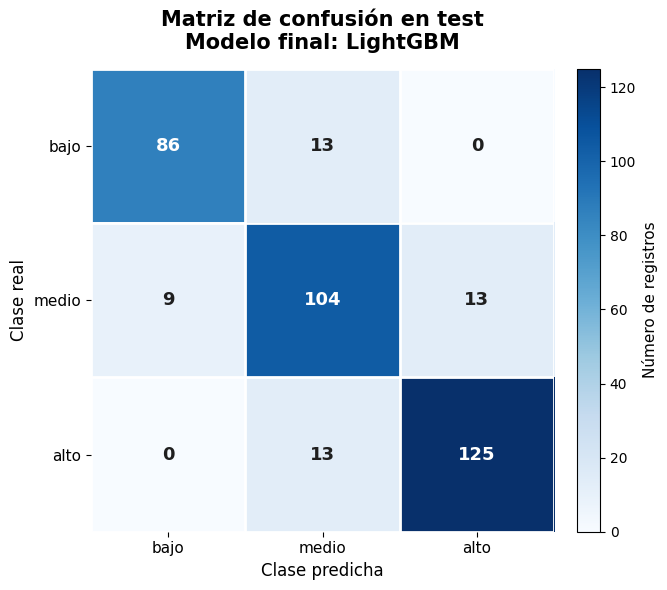

In [0]:

labels_orden = [0, 1, 2]
clases_orden = [ID_TO_LABEL[label] for label in labels_orden]

matriz_confusion_np = np.array([
    [
        MATRIZ_TEST_FINAL[str(label_real)][str(label_pred)]
        for label_pred in labels_orden
    ]
    for label_real in labels_orden
])

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    matriz_confusion_np,
    cmap="Blues",
)

ax.set_title(
    "Matriz de confusión en test\nModelo final: LightGBM",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Clase predicha", fontsize=12)
ax.set_ylabel("Clase real", fontsize=12)

ax.set_xticks(np.arange(len(clases_orden)))
ax.set_yticks(np.arange(len(clases_orden)))

ax.set_xticklabels(clases_orden, fontsize=11)
ax.set_yticklabels(clases_orden, fontsize=11)

max_value = matriz_confusion_np.max()

for i in range(matriz_confusion_np.shape[0]):
    for j in range(matriz_confusion_np.shape[1]):
        value = matriz_confusion_np[i, j]

        text_color = "white" if value > max_value * 0.55 else "#1f1f1f"

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Número de registros", fontsize=11)

ax.set_xticks(np.arange(-0.5, len(clases_orden), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(clases_orden), 1), minor=True)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=2,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

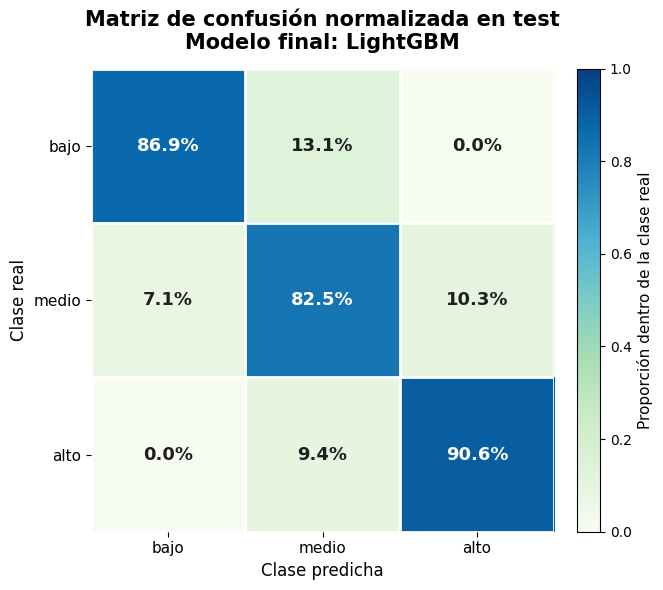

In [0]:
# ============================================================
# 15.6 Matriz de confusión final normalizada por clase real
# ============================================================

matriz_confusion_norm = matriz_confusion_np.astype(float)

row_sums = matriz_confusion_norm.sum(axis=1, keepdims=True)

matriz_confusion_norm = np.divide(
    matriz_confusion_norm,
    row_sums,
    out=np.zeros_like(matriz_confusion_norm),
    where=row_sums != 0,
)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    matriz_confusion_norm,
    cmap="GnBu",
    vmin=0,
    vmax=1,
)

ax.set_title(
    "Matriz de confusión normalizada en test\nModelo final: LightGBM",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Clase predicha", fontsize=12)
ax.set_ylabel("Clase real", fontsize=12)

ax.set_xticks(np.arange(len(clases_orden)))
ax.set_yticks(np.arange(len(clases_orden)))

ax.set_xticklabels(clases_orden, fontsize=11)
ax.set_yticklabels(clases_orden, fontsize=11)

for i in range(matriz_confusion_norm.shape[0]):
    for j in range(matriz_confusion_norm.shape[1]):
        value = matriz_confusion_norm[i, j]

        text_color = "white" if value > 0.55 else "#1f1f1f"

        ax.text(
            j,
            i,
            f"{value:.1%}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proporción dentro de la clase real", fontsize=11)

ax.set_xticks(np.arange(-0.5, len(clases_orden), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(clases_orden), 1), minor=True)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=2,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

La matriz de confusión normalizada muestra que el modelo final clasifica correctamente la mayoría de los registros en las tres clases del target. Las clases `bajo` y `alto` presentan los mejores desempeños, con aciertos cercanos al 88%. La clase `medio` es la más difícil de clasificar, con un acierto de 81.7%, lo cual es esperable porque representa una zona intermedia entre niveles bajos y altos de operación.

Los errores se concentran principalmente entre clases vecinas: `bajo → medio`, `medio → bajo`, `medio → alto` y `alto → medio`. No se observan errores extremos entre `bajo` y `alto`, lo cual indica que el modelo conserva una buena separación entre los niveles operacionales más distantes.

### 15.6 Verificación final de consistencia



Antes de continuar con la interpretación y el guardado de artefactos, se verifica que las variables principales del modelo final estén correctamente definidas.

Esta verificación evita inconsistencias si el notebook fue ejecutado parcialmente o si alguna variable fue sobrescrita.

In [0]:
assert FINAL_MODEL_ID == "M03", "El modelo final esperado es M03."
assert FINAL_MODEL_NAME == "LightGBM", "El modelo final esperado es LightGBM."
assert FINAL_DATASET_CONFIG == "corr_060_070", "La configuración final esperada es corr_060_070."
assert FINAL_SOURCE_EXPERIMENT_ID == "M03_corr_060_070_optuna01", (
    "El experimento fuente esperado es M03_corr_060_070_optuna01."
)

assert MODELO_FINAL is not None, "MODELO_FINAL no está definido."
assert METRICAS_TEST_FINAL is not None, "METRICAS_TEST_FINAL no está definido."
assert MATRIZ_TEST_FINAL is not None, "MATRIZ_TEST_FINAL no está definido."
assert feature_cols_final is not None, "feature_cols_final no está definido."

assert "accuracy" in METRICAS_TEST_FINAL, "No existe accuracy en métricas finales."
assert "balanced_accuracy" in METRICAS_TEST_FINAL, "No existe balanced_accuracy en métricas finales."
assert "macro_f1" in METRICAS_TEST_FINAL, "No existe macro_f1 en métricas finales."

print("[OK] Consistencia final verificada.")
print("Modelo final       :", FINAL_MODEL_NAME)
print("Experimento fuente :", FINAL_SOURCE_EXPERIMENT_ID)
print("Dataset final      :", FINAL_DATASET_CONFIG)
print("Macro F1 test      :", round(METRICAS_TEST_FINAL["macro_f1"], 4))

[OK] Consistencia final verificada.
Modelo final       : LightGBM
Experimento fuente : M03_corr_060_070_optuna01
Dataset final      : corr_060_070
Macro F1 test      : 0.8683


## 16. Interpretabilidad y análisis de errores


En esta sección se analiza el modelo final seleccionado desde dos perspectivas:

1. Importancia de variables, para identificar qué features tuvieron mayor peso relativo en la predicción.
2. Análisis de errores, para revisar en qué clases se concentra la confusión del modelo.

El modelo final corresponde a `M03_corr_060_070_optuna01`, basado en LightGBM local con la configuración `corr_060_070`. Este modelo fue seleccionado porque obtuvo el mejor desempeño en validation y el mejor promedio de `macro_f1` en validación cruzada interna.

### 16.1 Auditoría de leakage directo en features finales

Antes de interpretar la importancia de variables del modelo final, se verifica que ninguna columna asociada directamente al target futuro haya quedado incluida dentro de las variables predictoras.

Esta revisión es importante porque variables como `target_operaciones_total_mes_siguiente`, `target_q33_operaciones`, `target_q66_operaciones` o `target_nivel_operacion_mes_siguiente` no deben ser usadas como features del modelo.

In [0]:
cols_sospechosas_leakage = [
    "target_operaciones_total_mes_siguiente",
    "target_nivel_operacion_mes_siguiente",
    "target_q33_operaciones",
    "target_q66_operaciones",
    "label",
    "prediction",
    "probability",
    "rawPrediction",
]

features_con_leakage_directo = [
    col_name
    for col_name in feature_cols_final
    if col_name in cols_sospechosas_leakage
]

print("Features con posible leakage directo:")
print(features_con_leakage_directo)

if len(features_con_leakage_directo) == 0:
    print("[OK] No hay leakage directo por columnas target/label en feature_cols_final.")
else:
    print("[ALERTA] Hay columnas asociadas al target dentro de las features finales.")

Features con posible leakage directo:
[]
[OK] No hay leakage directo por columnas target/label en feature_cols_final.


#### 16.1.1 Resultado de la auditoría de leakage directo

La auditoría no identificó columnas asociadas directamente al target dentro de `feature_cols_final`.

Por tanto, no se evidencia fuga directa de información por inclusión accidental de columnas objetivo, etiquetas, predicciones o probabilidades dentro de las variables predictoras del modelo final.

La alta importancia de `operaciones_total` no se interpreta como leakage directo, sino como una señal temporal autoregresiva: el nivel operativo del mes actual aporta información relevante para anticipar el nivel operativo del mes siguiente.

### 16.2. Importancia de variables del modelo final


In [0]:

if not hasattr(MODELO_FINAL, "feature_importances_"):
    raise AttributeError(
        "El modelo final no tiene atributo feature_importances_. "
        "Esta sección aplica directamente para modelos basados en árboles."
    )

df_feature_importance_final = pd.DataFrame({
    "feature": feature_cols_final,
    "importance": MODELO_FINAL.feature_importances_,
})

df_feature_importance_final = (
    df_feature_importance_final
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

df_feature_importance_final["rank"] = (
    np.arange(len(df_feature_importance_final)) + 1
)

display(
    spark.createDataFrame(df_feature_importance_final.head(30))
)

feature,importance,rank
operaciones_total,1587,1
operaciones_vs_roll_mean_12,897,2
operaciones_vs_roll_mean_3,859,3
operaciones_por_destino,819,4
operaciones_delta_1,816,5
carga_kg_por_operacion_lag_3,744,6
pasajeros_total_roll_mean_12,603,7
dewpoint_depression_c,530,8
latitude_deg,529,9
meteo_adverso_score_roll_mean_12,526,10


### 16.3 Gráfica de importancia de variables

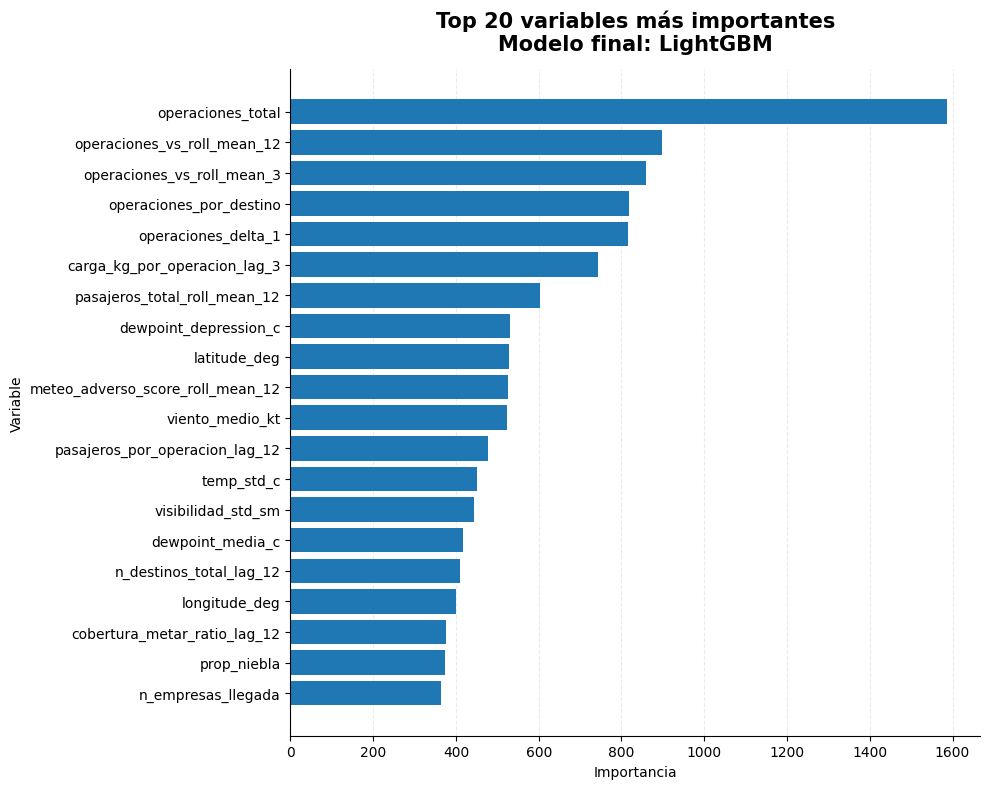

In [0]:

top_n_features = 20

df_top_features = (
    df_feature_importance_final
    .head(top_n_features)
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    df_top_features["feature"],
    df_top_features["importance"],
)

ax.set_title(
    f"Top {top_n_features} variables más importantes\nModelo final: LightGBM",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Importancia")
ax.set_ylabel("Variable")

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### 16.4. Análisis de confianza del modelo final



En esta subsección se analiza la confianza del modelo final usando las probabilidades estimadas por `predict_proba`.

La idea es revisar si los errores ocurren principalmente cuando el modelo tiene menor confianza, lo cual ayuda a interpretar la estabilidad de las predicciones.

In [0]:

if not hasattr(MODELO_FINAL, "predict_proba"):
    raise AttributeError(
        "El modelo final no tiene predict_proba. "
        "No es posible calcular confianza probabilística."
    )

y_test_proba = MODELO_FINAL.predict_proba(X_test_final)

df_confianza_test = pd.DataFrame({
    "label_real": list(y_test_final),
    "label_pred": list(y_test_pred),
    "prob_max": y_test_proba.max(axis=1),
})

df_confianza_test["clase_real"] = (
    df_confianza_test["label_real"]
    .astype(int)
    .map(ID_TO_LABEL)
)

df_confianza_test["clase_pred"] = (
    df_confianza_test["label_pred"]
    .astype(int)
    .map(ID_TO_LABEL)
)

df_confianza_test["acierto"] = (
    df_confianza_test["label_real"].astype(int)
    == df_confianza_test["label_pred"].astype(int)
)

display(
    spark.createDataFrame(df_confianza_test)
)

label_real,label_pred,prob_max,clase_real,clase_pred,acierto
1,1,0.9435682210489726,medio,medio,true
1,1,0.9619811515376389,medio,medio,true
1,1,0.9496577282346488,medio,medio,true
1,1,0.9743536327271274,medio,medio,true
1,1,0.9854806647595604,medio,medio,true
1,1,0.9855514145113685,medio,medio,true
1,1,0.8120046696300335,medio,medio,true
1,1,0.8597228783498914,medio,medio,true
1,1,0.9807779219180953,medio,medio,true
1,1,0.9895815622727975,medio,medio,true


#### 16.4.1 Resumen de confianza por acierto/error


In [0]:

df_confianza_resumen = (
    df_confianza_test
    .groupby("acierto", as_index=False)
    .agg(
        n=("prob_max", "count"),
        confianza_media=("prob_max", "mean"),
        confianza_minima=("prob_max", "min"),
        confianza_maxima=("prob_max", "max"),
    )
)

display(
    spark.createDataFrame(df_confianza_resumen)
)

acierto,n,confianza_media,confianza_minima,confianza_maxima
false,48,0.7451364397416879,0.5053850483376209,0.9754999194123372
true,315,0.9401418412427633,0.5061576249333086,0.9986113600861293


#### 16.4.2 Gráfica de confianza del modelo final


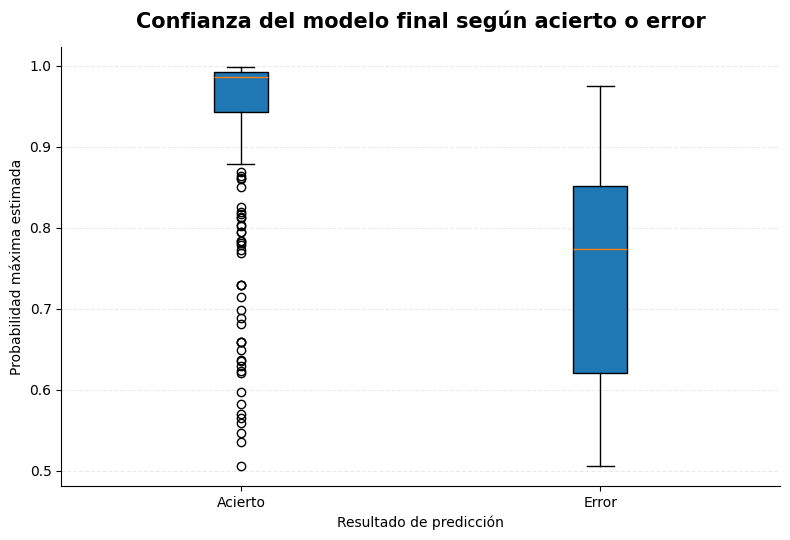

In [0]:

df_confianza_plot = df_confianza_test.copy()

df_confianza_plot["resultado"] = np.where(
    df_confianza_plot["acierto"],
    "Acierto",
    "Error",
)

fig, ax = plt.subplots(figsize=(8, 5.5))

datos_plot = [
    df_confianza_plot.loc[df_confianza_plot["resultado"] == "Acierto", "prob_max"],
    df_confianza_plot.loc[df_confianza_plot["resultado"] == "Error", "prob_max"],
]

ax.boxplot(
    datos_plot,
    labels=["Acierto", "Error"],
    patch_artist=True,
)

ax.set_title(
    "Confianza del modelo final según acierto o error",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_ylabel("Probabilidad máxima estimada")
ax.set_xlabel("Resultado de predicción")

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### 16.5. Construir dataset de errores en test

In [0]:

df_errores_test_final = pd.DataFrame({
    "label_real": list(y_test_final),
    "label_pred": list(y_test_pred),
})

df_errores_test_final["clase_real"] = (
    df_errores_test_final["label_real"]
    .astype(int)
    .map(ID_TO_LABEL)
)

df_errores_test_final["clase_pred"] = (
    df_errores_test_final["label_pred"]
    .astype(int)
    .map(ID_TO_LABEL)
)

df_errores_test_final["acierto"] = (
    df_errores_test_final["label_real"].astype(int)
    == df_errores_test_final["label_pred"].astype(int)
)

df_errores_test_final["tipo_error"] = np.where(
    df_errores_test_final["acierto"],
    "acierto",
    df_errores_test_final["clase_real"] + " → " + df_errores_test_final["clase_pred"],
)

display(
    spark.createDataFrame(df_errores_test_final)
)

label_real,label_pred,clase_real,clase_pred,acierto,tipo_error
1,1,medio,medio,true,acierto
1,1,medio,medio,true,acierto
1,1,medio,medio,true,acierto
1,1,medio,medio,true,acierto
1,1,medio,medio,true,acierto
1,1,medio,medio,true,acierto
1,1,medio,medio,true,acierto
1,1,medio,medio,true,acierto
1,1,medio,medio,true,acierto
1,1,medio,medio,true,acierto


### 16.6. Resumen de errores por tipo


In [0]:

df_resumen_errores_test = (
    df_errores_test_final
    .groupby("tipo_error", as_index=False)
    .size()
    .rename(columns={"size": "n"})
    .sort_values("n", ascending=False)
)

df_resumen_errores_test["pct"] = (
    df_resumen_errores_test["n"]
    / df_resumen_errores_test["n"].sum()
    * 100
)

display(
    spark.createDataFrame(df_resumen_errores_test)
)

tipo_error,n,pct
acierto,315,86.77685950413223
alto → medio,13,3.581267217630854
bajo → medio,13,3.581267217630854
medio → alto,13,3.581267217630854
medio → bajo,9,2.479338842975207


### 16.7. Gráfica de tipos de error


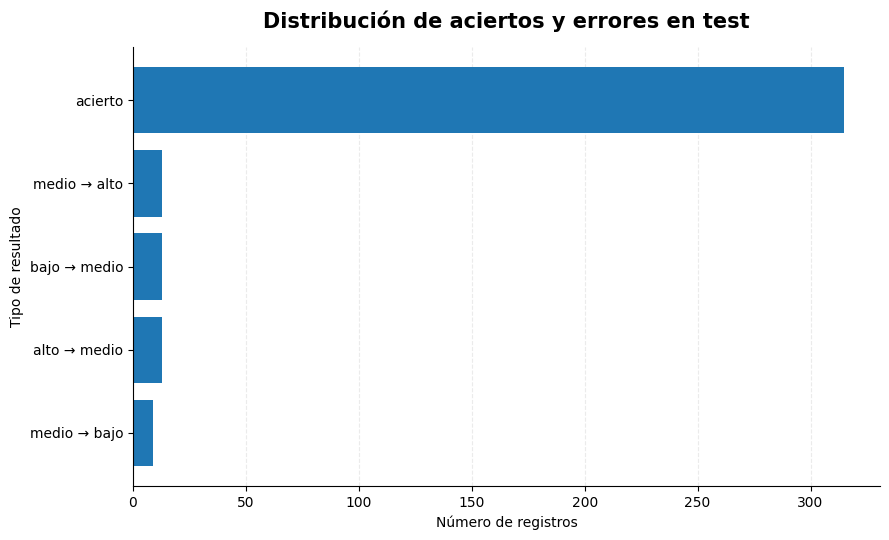

In [0]:

df_plot_errores = (
    df_resumen_errores_test
    .sort_values("n", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    df_plot_errores["tipo_error"],
    df_plot_errores["n"],
)

ax.set_title(
    "Distribución de aciertos y errores en test",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Número de registros")
ax.set_ylabel("Tipo de resultado")

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### 16.8. Interpretación


La matriz de confusión normalizada muestra que el modelo final clasifica correctamente la mayoría de los registros en las tres clases del target. Las clases `bajo` y `alto` presentan los mejores desempeños, mientras que la clase `medio` es la más difícil de clasificar.

Los errores se concentran principalmente entre clases vecinas, lo cual es coherente con la naturaleza ordinal del target. No se observa una confusión fuerte entre `bajo` y `alto`, lo que indica que el modelo conserva una separación adecuada entre los niveles operacionales más distantes.

No se realizó ajuste adicional de umbrales de decisión, porque el problema es multiclase y el modelo final ya presenta una matriz de confusión estable. La predicción se asigna a la clase con mayor probabilidad estimada.

## 17. Guardado de resultados y artefactos


En esta sección se guardan los principales artefactos generados durante el entrenamiento, validación, selección y evaluación final del modelo.

Se guardan:

- Métricas de validation.
- Métricas de validación cruzada interna.
- Métricas finales en test.
- Matriz de confusión final.
- Importancia de variables.
- Modelo final entrenado.
- Metadata de selección del modelo final.

### 17.1 Configuración de rutas de salida


In [0]:

RESULTS_DIR = GOLD_MONTHLY_DIR / "results" / "classical_models"

METRICS_DIR = RESULTS_DIR / "metrics"
MODELS_DIR = RESULTS_DIR / "model_artifacts"
PLOTS_DIR = RESULTS_DIR / "plots"
SUMMARIES_DIR = RESULTS_DIR / "summaries"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"

for path_dir in [
    RESULTS_DIR,
    METRICS_DIR,
    MODELS_DIR,
    PLOTS_DIR,
    SUMMARIES_DIR,
    PREDICTIONS_DIR,
]:
    path_dir.mkdir(parents=True, exist_ok=True)

print("Directorio de resultados:")
print(RESULTS_DIR)

Directorio de resultados:
/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models


### 17.2 Guardar métricas principales


In [0]:

df_resultados_validation_pd = df_resultados_validation.toPandas()
df_cv_summary_pd = df_cv_summary.toPandas()
df_cv_folds_pd = df_cv_folds.toPandas()

df_metricas_test_final_pd = pd.DataFrame([METRICAS_TEST_FINAL])
df_matriz_test_final_pd = df_matriz_test_final.toPandas()

df_resultados_validation_pd.to_csv(
    METRICS_DIR / "metrics_validation_all_models.csv",
    index=False,
)

df_cv_summary_pd.to_csv(
    METRICS_DIR / "metrics_cv_summary.csv",
    index=False,
)

df_cv_folds_pd.to_csv(
    METRICS_DIR / "metrics_cv_folds.csv",
    index=False,
)

df_metricas_test_final_pd.to_csv(
    METRICS_DIR / "metrics_test_final_model.csv",
    index=False,
)

df_matriz_test_final_pd.to_csv(
    METRICS_DIR / "confusion_matrix_test_final.csv",
    index=False,
)

print("[OK] Métricas guardadas en CSV.")

[OK] Métricas guardadas en CSV.


### 17.3 Guardar importancia de variables y errores


In [0]:

df_feature_importance_final.to_csv(
    SUMMARIES_DIR / "feature_importance_final_model.csv",
    index=False,
)

df_errores_test_final.to_csv(
    SUMMARIES_DIR / "test_error_analysis.csv",
    index=False,
)

df_resumen_errores_test.to_csv(
    SUMMARIES_DIR / "test_error_summary.csv",
    index=False,
)

print("[OK] Importancia de variables y análisis de errores guardados.")

[OK] Importancia de variables y análisis de errores guardados.


### 17.4 Guardar modelo final


In [0]:

model_path = MODELS_DIR / "final_lightgbm_model.joblib"

joblib.dump(
    MODELO_FINAL,
    model_path,
)

print("[OK] Modelo final guardado en:")
print(model_path)

[OK] Modelo final guardado en:
/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/model_artifacts/final_lightgbm_model.joblib


### 17.5 Guardar metadata del modelo final


In [0]:

final_model_metadata = {
    "final_model_selection": FINAL_MODEL_SELECTION,
    "final_test_experiment_id": FINAL_TEST_EXPERIMENT_ID,
    "final_dataset_config": FINAL_DATASET_CONFIG,
    "final_model_id": FINAL_MODEL_ID,
    "final_model_name": FINAL_MODEL_NAME,
    "final_backend": FINAL_BACKEND,
    "target_col": TARGET_COL,
    "target_num_col": TARGET_NUM_COL,
    "label_mapping": ID_TO_LABEL,
    "n_features": len(feature_cols_final),
    "feature_cols": feature_cols_final,
    "metrics_test_final": METRICAS_TEST_FINAL,
    "confusion_matrix_test_final": MATRIZ_TEST_FINAL,
    "created_at": datetime.now().isoformat(),
}

metadata_path = SUMMARIES_DIR / "final_model_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(
        final_model_metadata,
        f,
        ensure_ascii=False,
        indent=4,
    )

print("[OK] Metadata final guardada en:")
print(metadata_path)

[OK] Metadata final guardada en:
/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/summaries/final_model_metadata.json


### 17.6 Verificación de archivos generados


In [0]:

print("RESULTS_DIR:", RESULTS_DIR)

print("\nMétricas:")
display(dbutils.fs.ls(f"dbfs:{METRICS_DIR}"))

print("\nModelos:")
display(dbutils.fs.ls(f"dbfs:{MODELS_DIR}"))

print("\nSummaries:")
display(dbutils.fs.ls(f"dbfs:{SUMMARIES_DIR}"))

RESULTS_DIR: /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models

Métricas:


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/metrics/confusion_matrix_test_final.csv,confusion_matrix_test_final.csv,204,1780033543000
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/metrics/metrics_cv_folds.csv,metrics_cv_folds.csv,3957,1780033542000
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/metrics/metrics_cv_summary.csv,metrics_cv_summary.csv,1522,1780033542000
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/metrics/metrics_test_final_model.csv,metrics_test_final_model.csv,537,1780033543000
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/metrics/metrics_validation_all_models.csv,metrics_validation_all_models.csv,8540,1780033542000



Modelos:


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/model_artifacts/final_lightgbm_model.joblib,final_lightgbm_model.joblib,1704924,1780033544000



Summaries:


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/summaries/feature_importance_final_model.csv,feature_importance_final_model.csv,1051,1780033543000
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/summaries/final_model_metadata.json,final_model_metadata.json,3764,1780033544000
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/summaries/test_error_analysis.csv,test_error_analysis.csv,10504,1780033543000
dbfs:/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/summaries/test_error_summary.csv,test_error_summary.csv,190,1780033543000


### 17.6 Guardar gráficas como PNG



En esta subsección se guardan las gráficas principales del modelo final como archivos `.png`.

Las gráficas guardadas son:

- Matriz de confusión absoluta.
- Matriz de confusión normalizada.
- Importancia de variables.
- Distribución de aciertos y errores.

In [0]:
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

labels_orden = [0, 1, 2]
clases_orden = [ID_TO_LABEL[label] for label in labels_orden]

matriz_confusion_np = np.array([
    [
        MATRIZ_TEST_FINAL[str(label_real)][str(label_pred)]
        for label_pred in labels_orden
    ]
    for label_real in labels_orden
])

#### 17.6.1 Guardar matriz de confusión absoluta


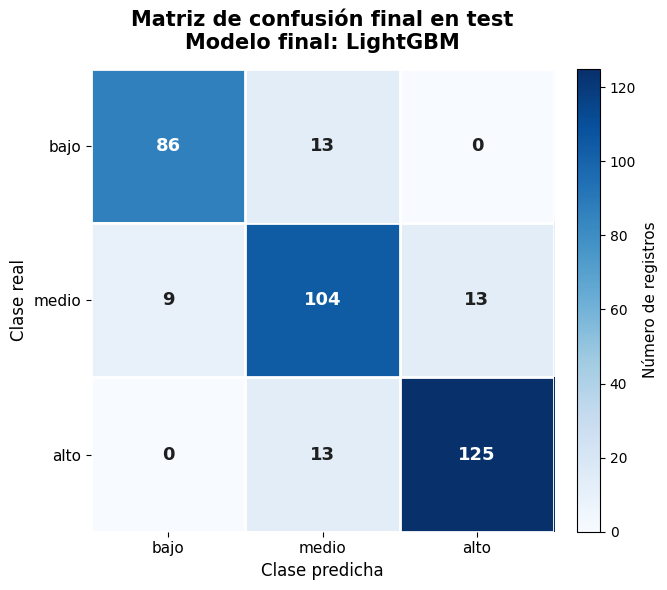

[OK] Gráfica guardada en:
/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/plots/confusion_matrix_test_absolute.png


In [0]:

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    matriz_confusion_np,
    cmap="Blues",
)

ax.set_title(
    "Matriz de confusión final en test\nModelo final: LightGBM",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Clase predicha", fontsize=12)
ax.set_ylabel("Clase real", fontsize=12)

ax.set_xticks(np.arange(len(clases_orden)))
ax.set_yticks(np.arange(len(clases_orden)))

ax.set_xticklabels(clases_orden, fontsize=11)
ax.set_yticklabels(clases_orden, fontsize=11)

max_value = matriz_confusion_np.max()

for i in range(matriz_confusion_np.shape[0]):
    for j in range(matriz_confusion_np.shape[1]):
        value = matriz_confusion_np[i, j]
        text_color = "white" if value > max_value * 0.55 else "#1f1f1f"

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Número de registros", fontsize=11)

ax.set_xticks(np.arange(-0.5, len(clases_orden), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(clases_orden), 1), minor=True)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=2,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

confusion_abs_path = PLOTS_DIR / "confusion_matrix_test_absolute.png"

fig.savefig(
    confusion_abs_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("[OK] Gráfica guardada en:")
print(confusion_abs_path)

#### 17.6.2 Guardar matriz de confusión normalizada


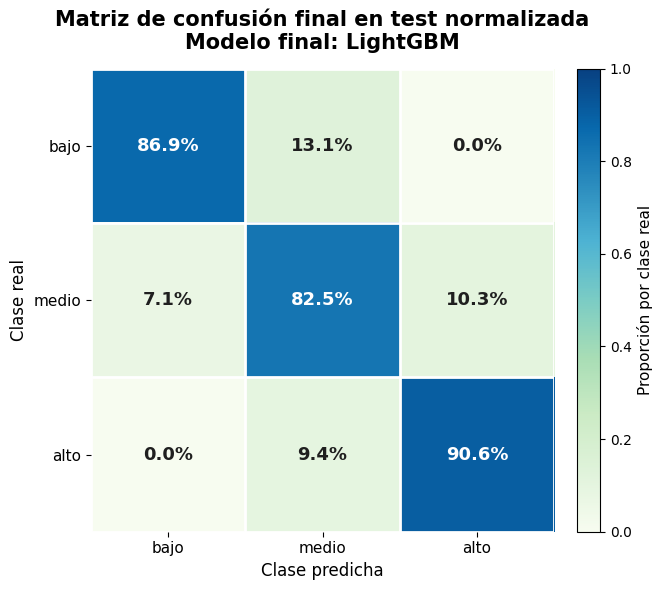

[OK] Gráfica guardada en:
/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/plots/confusion_matrix_test_normalized.png


In [0]:

matriz_confusion_norm = matriz_confusion_np.astype(float)

row_sums = matriz_confusion_norm.sum(axis=1, keepdims=True)

matriz_confusion_norm = np.divide(
    matriz_confusion_norm,
    row_sums,
    out=np.zeros_like(matriz_confusion_norm),
    where=row_sums != 0,
)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    matriz_confusion_norm,
    cmap="GnBu",
    vmin=0,
    vmax=1,
)

ax.set_title(
    "Matriz de confusión final en test normalizada\nModelo final: LightGBM",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Clase predicha", fontsize=12)
ax.set_ylabel("Clase real", fontsize=12)

ax.set_xticks(np.arange(len(clases_orden)))
ax.set_yticks(np.arange(len(clases_orden)))

ax.set_xticklabels(clases_orden, fontsize=11)
ax.set_yticklabels(clases_orden, fontsize=11)

for i in range(matriz_confusion_norm.shape[0]):
    for j in range(matriz_confusion_norm.shape[1]):
        value = matriz_confusion_norm[i, j]
        text_color = "white" if value > 0.55 else "#1f1f1f"

        ax.text(
            j,
            i,
            f"{value:.1%}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proporción por clase real", fontsize=11)

ax.set_xticks(np.arange(-0.5, len(clases_orden), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(clases_orden), 1), minor=True)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=2,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

confusion_norm_path = PLOTS_DIR / "confusion_matrix_test_normalized.png"

fig.savefig(
    confusion_norm_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("[OK] Gráfica guardada en:")
print(confusion_norm_path)

#### 17.6.3 Guardar gráfica de importancia de variables


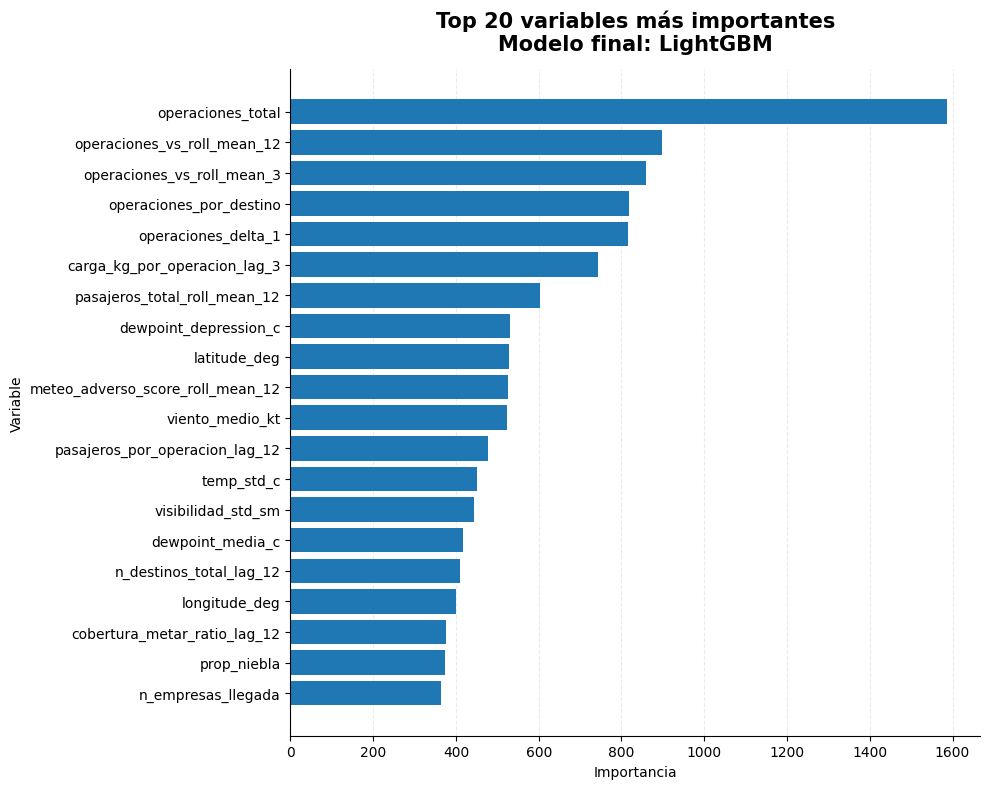

[OK] Gráfica guardada en:
/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/plots/feature_importance_top20_final_model.png


In [0]:

top_n_features = 20

df_top_features = (
    df_feature_importance_final
    .head(top_n_features)
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    df_top_features["feature"],
    df_top_features["importance"],
)

ax.set_title(
    f"Top {top_n_features} variables más importantes\nModelo final: LightGBM",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Importancia")
ax.set_ylabel("Variable")

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

feature_importance_path = PLOTS_DIR / "feature_importance_top20_final_model.png"

fig.savefig(
    feature_importance_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("[OK] Gráfica guardada en:")
print(feature_importance_path)

#### 17.6.4 Guardar gráfica de distribución de errores


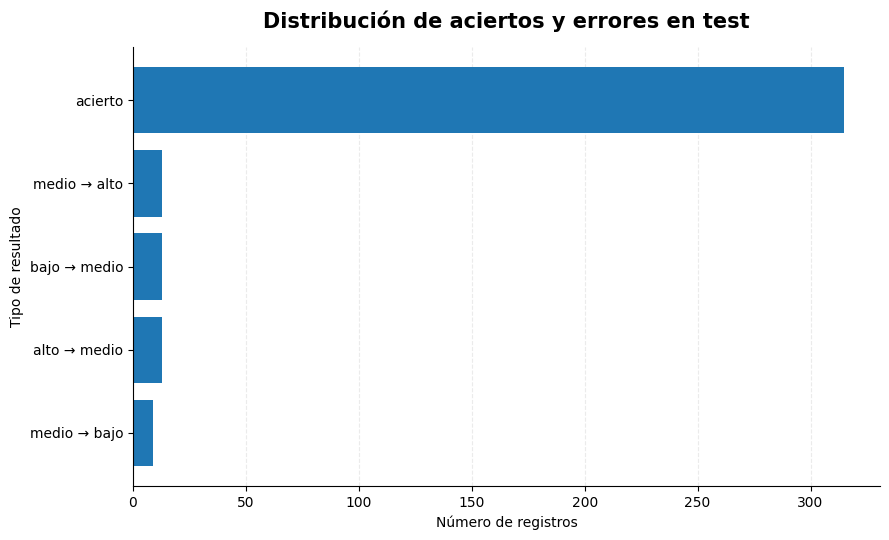

[OK] Gráfica guardada en:
/Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models/plots/error_distribution_test_final.png


In [0]:

df_plot_errores = (
    df_resumen_errores_test
    .sort_values("n", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    df_plot_errores["tipo_error"],
    df_plot_errores["n"],
)

ax.set_title(
    "Distribución de aciertos y errores en test",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Número de registros")
ax.set_ylabel("Tipo de resultado")

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

error_distribution_path = PLOTS_DIR / "error_distribution_test_final.png"

fig.savefig(
    error_distribution_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("[OK] Gráfica guardada en:")
print(error_distribution_path)

## 18. Conclusiones del notebook


En este notebook se entrenaron, compararon y evaluaron modelos supervisados para clasificar el nivel mensual de operación aeroportuaria en tres clases: `bajo`, `medio` y `alto`.

Se evaluaron diferentes familias de modelos:

- Logistic Regression.
- Random Forest.
- XGBoost.
- LightGBM.
- Extra Trees.
- KNN.

La comparación inicial en validation permitió identificar que los modelos basados en árboles y boosting superaron claramente al baseline lineal. Posteriormente, se aplicó optimización de hiperparámetros con Optuna sobre los modelos más competitivos.

El modelo seleccionado como final fue:

- Modelo: `LightGBM`
- Experimento: `M03_corr_060_070_optuna01`
- Configuración de dataset: `corr_060_070`
- Backend: `lightgbm_local`

Este modelo fue seleccionado porque obtuvo el mejor desempeño en validation y el mejor promedio de `macro_f1` en validación cruzada interna. En la evaluación final sobre test, el modelo mantuvo un desempeño balanceado entre las clases, con errores concentrados principalmente entre clases vecinas.

La matriz de confusión final muestra que el modelo logra separar adecuadamente los niveles operacionales extremos (`bajo` y `alto`) y conserva un desempeño competitivo sobre la clase intermedia (`medio`), que naturalmente es la clase más difícil por representar una zona de transición.

No se realizó ajuste adicional de umbrales de decisión. La clase final se asignó usando la mayor probabilidad estimada por el modelo multiclase.

Como resultado, el notebook deja generados los principales artefactos para reproducibilidad:

- Métricas de validation.
- Métricas de validación cruzada.
- Métricas finales en test.
- Matriz de confusión final.
- Importancia de variables.
- Modelo final serializado.
- Metadata final del experimento.

### 18.1 Resumen final automático


In [0]:

print("============================================================")
print("RESUMEN FINAL DEL NOTEBOOK")
print("============================================================")

print("Modelo final:")
print(" - Experiment ID     :", FINAL_TEST_EXPERIMENT_ID)
print(" - Modelo            :", FINAL_MODEL_NAME)
print(" - Configuración     :", FINAL_DATASET_CONFIG)
print(" - Backend           :", FINAL_BACKEND)

print("\nMétricas finales en test:")
print(" - Accuracy          :", round(METRICAS_TEST_FINAL["accuracy"], 4))
print(" - Balanced accuracy :", round(METRICAS_TEST_FINAL["balanced_accuracy"], 4))
print(" - Macro F1          :", round(METRICAS_TEST_FINAL["macro_f1"], 4))
print(" - F1 bajo           :", round(METRICAS_TEST_FINAL["f1_bajo"], 4))
print(" - F1 medio          :", round(METRICAS_TEST_FINAL["f1_medio"], 4))
print(" - F1 alto           :", round(METRICAS_TEST_FINAL["f1_alto"], 4))

print("\nArtefactos guardados en:")
print(" -", RESULTS_DIR)

print("============================================================")

RESUMEN FINAL DEL NOTEBOOK
Modelo final:
 - Experiment ID     : M03_corr_060_070_final_test
 - Modelo            : LightGBM
 - Configuración     : corr_060_070
 - Backend           : lightgbm_local

Métricas finales en test:
 - Accuracy          : 0.8678
 - Balanced accuracy : 0.8666
 - Macro F1          : 0.8683
 - F1 bajo           : 0.8866
 - F1 medio          : 0.8125
 - F1 alto           : 0.9058

Artefactos guardados en:
 - /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models


### 18.2 Ficha técnica del modelo final


La siguiente ficha resume los principales elementos técnicos del modelo final seleccionado.

In [0]:
model_card_rows = [
    {
        "elemento": "Modelo final",
        "valor": FINAL_MODEL_NAME,
    },
    {
        "elemento": "ID del modelo",
        "valor": FINAL_MODEL_ID,
    },
    {
        "elemento": "Experimento seleccionado",
        "valor": FINAL_SOURCE_EXPERIMENT_ID,
    },
    {
        "elemento": "Experimento final en test",
        "valor": FINAL_TEST_EXPERIMENT_ID,
    },
    {
        "elemento": "Dataset usado",
        "valor": FINAL_DATASET_CONFIG,
    },
    {
        "elemento": "Backend",
        "valor": FINAL_BACKEND,
    },
    {
        "elemento": "Tipo de problema",
        "valor": "Clasificación multiclase",
    },
    {
        "elemento": "Clases",
        "valor": ", ".join(TARGET_ORDER),
    },
    {
        "elemento": "Métrica principal",
        "valor": "Macro F1-score",
    },
    {
        "elemento": "Estrategia de selección",
        "valor": "Validation + validación cruzada interna",
    },
    {
        "elemento": "Evaluación final",
        "valor": "Test",
    },
    {
        "elemento": "Ajuste de umbral",
        "valor": "No aplicado",
    },
    {
        "elemento": "Número de features",
        "valor": str(len(feature_cols_final)),
    },
    {
        "elemento": "Accuracy test",
        "valor": f"{METRICAS_TEST_FINAL['accuracy']:.4f}",
    },
    {
        "elemento": "Balanced accuracy test",
        "valor": f"{METRICAS_TEST_FINAL['balanced_accuracy']:.4f}",
    },
    {
        "elemento": "Macro F1 test",
        "valor": f"{METRICAS_TEST_FINAL['macro_f1']:.4f}",
    },
    {
        "elemento": "F1 bajo test",
        "valor": f"{METRICAS_TEST_FINAL['f1_bajo']:.4f}",
    },
    {
        "elemento": "F1 medio test",
        "valor": f"{METRICAS_TEST_FINAL['f1_medio']:.4f}",
    },
    {
        "elemento": "F1 alto test",
        "valor": f"{METRICAS_TEST_FINAL['f1_alto']:.4f}",
    },
]

df_model_card = spark.createDataFrame(model_card_rows)

display(df_model_card)

elemento,valor
Modelo final,LightGBM
ID del modelo,M03
Experimento seleccionado,M03_corr_060_070_optuna01
Experimento final en test,M03_corr_060_070_final_test
Dataset usado,corr_060_070
Backend,lightgbm_local
Tipo de problema,Clasificación multiclase
Clases,"bajo, medio, alto"
Métrica principal,Macro F1-score
Estrategia de selección,Validation + validación cruzada interna


### 18.3 Resumen final automático

In [0]:
print("============================================================")
print("RESUMEN FINAL DEL NOTEBOOK")
print("============================================================")

print("Modelo final:")
print(" - Experiment ID     :", FINAL_TEST_EXPERIMENT_ID)
print(" - Modelo            :", FINAL_MODEL_NAME)
print(" - Configuración     :", FINAL_DATASET_CONFIG)
print(" - Backend           :", FINAL_BACKEND)

print("\nMétricas finales en test:")
print(" - Accuracy          :", round(METRICAS_TEST_FINAL["accuracy"], 4))
print(" - Balanced accuracy :", round(METRICAS_TEST_FINAL["balanced_accuracy"], 4))
print(" - Macro F1          :", round(METRICAS_TEST_FINAL["macro_f1"], 4))
print(" - F1 bajo           :", round(METRICAS_TEST_FINAL["f1_bajo"], 4))
print(" - F1 medio          :", round(METRICAS_TEST_FINAL["f1_medio"], 4))
print(" - F1 alto           :", round(METRICAS_TEST_FINAL["f1_alto"], 4))

print("\nArtefactos guardados en:")
print(" -", RESULTS_DIR)

print("============================================================")

RESUMEN FINAL DEL NOTEBOOK
Modelo final:
 - Experiment ID     : M03_corr_060_070_final_test
 - Modelo            : LightGBM
 - Configuración     : corr_060_070
 - Backend           : lightgbm_local

Métricas finales en test:
 - Accuracy          : 0.8678
 - Balanced accuracy : 0.8666
 - Macro F1          : 0.8683
 - F1 bajo           : 0.8866
 - F1 medio          : 0.8125
 - F1 alto           : 0.9058

Artefactos guardados en:
 - /Volumes/workspace/default/proyecto_aeropuertos/gold/monthly_airport_dataset/results/classical_models
